# 전처리 통합본 — 2026-09-30 기준 · HI-Large

손은총 · 자금세탁소 · 2026-09-30 · 상태 **정리본**(결정은 팀 다섯 명이 함께 한다)

- **무엇**: 지금 모델(TGNN 36피처 · LightGBM 55열)에 실제로 들어가는 가공 사슬을 한 파일에 모았다.
  원본 CSV → 라벨 → DuckDB → 결합 파일 → 36피처 → 분할 → 라벨 병합 → CSSMC → TGNN 캐시 → LightGBM 입력.
- **대체**: 09-17 판 `전처리_통합_HI-Large_20260917.ipynb` 를 대체한다.
  - 09-17 판의 옛 파이프라인에서 지금 남은 역할은 **라벨 값과 모집단**(`index_full.npz`) 하나뿐이다.
  - 피처 · 분할 · 중복 기준 · 언더샘플은 모두 바뀌었다(부록 C).
- **데이터**: HI-Large 만 다룬다. HI-Small 자료는 넣지 않았다(사용자 지시).
- **생성기**: `_builders/build_nb_prep.py`. 이 노트북은 생성기가 만들고 안전 실행기(단독 · nice · 스레드 1)로 처음부터 끝까지 실행한 판이다.
- **과제**: 거래(엣지) 하나를 9클래스로 나눈다 — 패턴 8종(0~7) + 정상(8). 패턴 밖 세탁은 정상 클래스(8)에 합친다(09-29 결정, ⑦).

## 읽는 법
| 표시 | 뜻 |
|---|---|
| `# ▼ 원본 경로:줄` | 실제로 썼던 코드를 그 파일에서 글자 그대로 옮긴 셀. 바꾼 곳이 있으면 같은 줄에 적었다 |
| `show_src(경로, 시작, 끝)` | 실행하지 않고 원본 파일의 줄을 번호와 함께 보여 준다 |
| `확인용` | 파이프라인 코드가 아니라, 저장된 파일로 값을 대조하려고 이 노트북에서 새로 쓴 짧은 코드 |
| `RUN_…` 스위치 | 무거운 단계. **기본은 모두 꺼짐**. 켜면 이 폴더의 `out/`(작은 기록)과 `/tmp/prep_integrated_20260930/`(큰 파일)에만 쓴다 |
| 표 · 그림 수치 | 저장된 결과 파일을 실행 중에 읽어 출력한다. 읽은 파일 경로를 `읽음:` 줄로 같이 찍는다 |

## 단계 한눈에
| 단계 | 하는 일 | 핵심 코드 | 기본 실행(가벼움) | 무거운 스위치 · 걸린 시간(기록) |
|---|---|---|---|---|
| ① 원본 | 11열 CSV 공식본 | `daily_pipeline.py` 20-24 · 128-130 | 머리글 검사 · 앞 몇 줄 · 크기 | — |
| ② 라벨 · 모집단 | Patterns.txt 파싱 · 원본 행 번호 y9 | `daily_pipeline.py` 208-235 · `tree9_lib.py` 183-197 | Patterns.txt 실제 파싱 · 헤더만 읽기 | `RUN_LABELS_RAW` 6초 이하(STATUS_log) · 실행 셀은 ③ DuckDB 뒤 |
| ③ DuckDB | drop_exact 150 · 통화 기준 · 노드 창 D−29~D | `daily_pipeline.py` 121-403 | 설정 대조 · 결과 기록 | `RUN_DUCKDB` 37~41분 · anon 15~17.4 GiB |
| ④ 결합 파일 | 하루 1파일 = 노드 22+22 + 엣지 18 + 라벨 | `tree9_lib.py` 201-238 | 85개 파일 메타데이터 대조 | `RUN_JOIN` 3.16시간(저장본 있음) |
| ⑤ 36피처 | 노드 19 + 엣지 17(amt_z) · 결제 수단 제외 | `build_nb_A.py` 65-74 · 106-157 | 열 고르기 실행 · amt_z 식 재현(앞 2,000행) | `RUN_AMTZ` 약 1분(저장본 있음) |
| ⑥ 분할 | 개발 51/17/17 · 최종 51/17/22 | `tree9_lib.py` 54 | 날짜 수 확인 · 타임라인 | — |
| ⑦ 라벨 병합 | 패턴 밖 세탁 → 클래스 8 | `build_nb_fix.py` 424-448 | 규칙표 실행 | — |
| ⑧ CSSMC r300 | 정상 언더샘플(결정적, KL 최소) | `us_step5_select.py` 55-70 | 지문 · 날짜별 행 대조 | 없음(다시 만들 수 없는 유일본) |
| ⑨ TGNN 캐시 | 받은 문맥 10건 · 나가는 문맥 10건 · `_m` 팔은 학습 · 채점 배치를 시드로 섞음 | `build_nb_A.py` 164-245 · `build_nb_fix.py` 283-332 · 473-485 | `_load_day_ctx` 만들기 · 기록 그림 | `RUN_CACHE36` 3.89시간 · `RUN_OUT_CACHE` 47분 |
| ⑩ LightGBM 55열 | 결합 파일 54열 + amt_z | `build_nb_C.py` 75-100 · `build_nb_CM.py` 111-195 | 열 대조 · 패턴 밖 40행을 넣은 5,000행 표본에 read55 · read55m 실행 | `RUN_LGB55` 약 7분 |

시간 출처: `_work/tree9_20260921/meta/step2_timing.json` · `tgnn36_20260928/common/duckdb_timing.json` · `common/cache36_summary.json` · `_fix/common/out_cache_log.csv` · `STATUS_log.txt`(09-29 01:47~01:54, LightGBM 입력).

## 안전(이 노트북을 돌릴 때)
- 기본 설정은 가볍다. 큰 파일은 헤더 · 메타데이터 · 몇 줄만 읽는다. 원본 CSV 전수 · DuckDB · `/tmp` 캐시는 열지 않는다.
- 무거운 스위치는 **반드시 단독으로** 켠다(다른 무거운 작업 · 연쇄가 없을 때, `/workspace/mem_guard.py` 를 띄운 뒤). DuckDB 단계만으로 anon 15~17.4 GiB 를 쓴다.
  - 스위치를 하나라도 켜면 0-4 셀이 먼저 확인한다: anon 6 GiB 미만 · 다른 무거운 작업(복구 연쇄 · 수정판 · FraudGT · LightGBM 노트북 등) 없음. 아니면 멈춘다.
- `cssmc_r300.npy` 는 다시 만들 수 없는 유일본이다(⑧). 이 노트북은 읽기만 한다.

## 0-1. 스위치 · 경로

In [1]:
import os
for _k in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ.setdefault(_k, '1')                                   # numpy 를 부르기 전에(병행 작업 보호)
import sys, json, time, gc, hashlib, csv, re, zipfile, inspect, shutil, types, resource, pickle
sys.dont_write_bytecode = True                                        # 원본 코드 폴더에 __pycache__ 를 새로 만들지 않는다
from pathlib import Path
from dataclasses import asdict
import numpy as np, pandas as pd, pyarrow as pa, pyarrow.parquet as pq
T0 = time.time()

# 무거운 단계 스위치 — 기본 전부 꺼짐. 환경 변수로 켠다(예: PREP_RUN_DUCKDB=1). 켜는 순서 = 아래 순서
def _sw(name): return os.environ.get('PREP_' + name, '0') == '1'
RUN_LABELS_RAW = _sw('RUN_LABELS_RAW')   # ② index_full.npz(1.6 GB) + new_proc2raw.npy → 원본 행 번호 라벨(/tmp 새 폴더) · 실행 셀은 ③ DuckDB 뒤
RUN_DUCKDB     = _sw('RUN_DUCKDB')       # ③ 약 37~41분, anon 15~17.4 GiB — 반드시 단독
RUN_JOIN       = _sw('RUN_JOIN')         # ④ 약 3.2시간(/workspace 저장본이 있어 보통 끔)
RUN_AMTZ       = _sw('RUN_AMTZ')         # ⑤ 약 1분(/workspace 저장본이 있어 보통 끔)
RUN_CACHE36    = _sw('RUN_CACHE36')      # ⑨ 받은 문맥 캐시 · 85일 약 3.9시간 · /tmp 101 GiB
RUN_OUT_CACHE  = _sw('RUN_OUT_CACHE')    # ⑨ 나가는 문맥 캐시 · 85일 약 47분 · 약 65 GB
RUN_LGB55      = _sw('RUN_LGB55')        # ⑩ LightGBM 입력(val·test 원시 + 병합 학습 자료) · 약 7분
# 캐시를 만들 분할(09-30 복구는 val,test 만). 공백 · 순서와 상관없이 받고, 항상 train → val → test(날짜 순)로 둔다
_cs = [s.strip() for s in os.environ.get('PREP_CACHE_SPLITS', 'train,val,test').split(',') if s.strip()]
assert _cs and set(_cs) <= {'train', 'val', 'test'} and len(set(_cs)) == len(_cs), f'PREP_CACHE_SPLITS 는 train · val · test 중에서 고른다: {_cs}'
CACHE_SPLITS = tuple(s for s in ('train', 'val', 'test') if s in _cs)
SPLIT_TAG = '' if CACHE_SPLITS == ('train', 'val', 'test') else '_' + ''.join(CACHE_SPLITS)                 # 부분 실행이면 기록 파일 이름에 붙인다
DONE_MARK = '_ALL_DONE' if not SPLIT_TAG else '_' + ''.join(s.upper() for s in CACHE_SPLITS) + '_DONE'  # 09-30 복구 사본과 같은 규칙(val,test → _VALTEST_DONE)
HEAVY = [k for k, v in dict(RUN_LABELS_RAW=RUN_LABELS_RAW, RUN_DUCKDB=RUN_DUCKDB, RUN_JOIN=RUN_JOIN, RUN_AMTZ=RUN_AMTZ,
                            RUN_CACHE36=RUN_CACHE36, RUN_OUT_CACHE=RUN_OUT_CACHE, RUN_LGB55=RUN_LGB55).items() if v]

# 읽기 전용 입력
FP = Path('/workspace/Final_preprocess'); EDA_DIR = FP / 'HI-Large_EDA'; TG = EDA_DIR / 'tgnn36_20260928'
RAW = Path('/workspace/IBM_AML_dataset')
META = EDA_DIR / '_work/tree9_20260921/meta'            # 09-21 DB 의 작은 산출물(저장본)
SAVED_JD = EDA_DIR / '_work/tree9_20260921/joined'      # 09-21 결합 파일 저장본(85개, 6.0 GiB)
US = EDA_DIR / 'us_cmp_20260922'                        # 언더샘플 비교(CSSMC)
FIXD = FP / 'fix_20260927'                               # 09-27 정정안 측정(적용 안 함)
EDA_NOW = FP / 'EDA_현황_20260929'
TAEHOON = FP / '태훈님_전처리/feature_code_40_20260921'
# 쓰는 곳 — 기본 실행: 그림(_figs) + ⑩ 표본 확인 때 잠깐 쓰고 지우는 _tmp_read55/(이 폴더 안). 무거운 스위치: out/ 과 새 /tmp 폴더만
NBDIR = FP / '통합본_20260930/전처리'; FIG = NBDIR / '_figs'; OUTD = NBDIR / 'out'
PREP_TMP = Path('/tmp/prep_integrated_20260930')       # 다른 연쇄의 /tmp/tree9_work · /tmp/gnn36_* · /tmp/lgb55 와 겹치지 않는 새 폴더
FIG.mkdir(parents=True, exist_ok=True)
for _p in ('/tmp/tree9_work', '/tmp/gnn36_full', '/tmp/gnn36_out', '/tmp/lgb55'):
    assert not str(PREP_TMP).startswith(_p)
print('무거운 스위치:', HEAVY or '없음(기본 — 가벼운 확인만)', '· 캐시 분할', CACHE_SPLITS, '· 완료 표시', DONE_MARK)

무거운 스위치: 없음(기본 — 가벼운 확인만) · 캐시 분할 ('train', 'val', 'test') · 완료 표시 _ALL_DONE


## 0-2. 공용 도구 — 글꼴 · 표 · 원본 줄 보기

In [2]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt, matplotlib.font_manager as fm, matplotlib.dates as mdates, matplotlib.ticker as mticker
from IPython.display import Image, display, Markdown
# 글꼴 · 스타일: EDA_현황_20260929/_builders/common.py:25-31 과 같은 방식(글꼴 파일은 같은 나눔고딕, /workspace/.fonts)
FONT = Path('/workspace/.fonts/NanumGothic-Regular.ttf')
fm.fontManager.addfont(str(FONT))
plt.rcParams.update({'font.family': fm.FontProperties(fname=str(FONT)).get_name(), 'axes.unicode_minus': False,
                     'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': '#b8bcc2', 'axes.labelcolor': '#333', 'xtick.color': '#555', 'ytick.color': '#555',
                     'axes.grid': True, 'axes.axisbelow': True, 'grid.color': '#e6e8eb', 'grid.linewidth': 0.8, 'lines.linewidth': 2})
INK, MUTED, GRAY, LIGHT = '#1f1f1f', '#666', '#9aa0a6', '#d5d8dc'
SC = {'train': '#2a78d6', 'val': '#eb6834', 'test': '#1baf7a'}            # 분할 색(EDA 현황 E 빌더와 같음)
MC = {'cssmc': '#4a3aa7', 'clara': '#eda100', 'km': '#e34948'}            # 언더샘플 방식 색(검증기 통과, 노랑은 대비가 낮아 범례·직접 표시를 같이 씀)
TC = {'node': '#4a3aa7', 'edge': '#e87ba4'}                                # 노드/엣지 피처 색(검증기 통과)

def savefig(fig, name):
    p = FIG / name; fig.savefig(p, dpi=110, bbox_inches='tight'); plt.close(fig); display(Image(filename=str(p)))

def anon_gib():
    for l in open('/sys/fs/cgroup/memory.stat'):
        if l.startswith('anon '): return int(l.split()[1]) / 2**30
    return float('nan')

def rss_mb(): return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024

def show_src(path, a, b, note=''):
    """원본 파일의 a~b 줄을 번호와 함께 보여 준다(실행하지 않음)."""
    ls = Path(path).read_text(encoding='utf-8').splitlines()
    print(f'── {path}:{a}-{b}' + (f' · {note}' if note else ''))
    for i in range(a, b + 1): print(f'{i:5d}  {ls[i - 1]}')
    print()

def show_nb_src(path, cell, a, b, note=''):
    ls = ''.join(json.loads(Path(path).read_text(encoding='utf-8'))['cells'][cell]['source']).splitlines()
    print(f'── {path} 셀 {cell}:{a}-{b}' + (f' · {note}' if note else ''))
    for i in range(a, b + 1): print(f'{i:5d}  {ls[i - 1]}')
    print()

def rd(path, **kw):
    p = Path(path); print('읽음:', p); return pd.read_csv(p, encoding='utf-8-sig', **kw)

def rj(path):
    p = Path(path); print('읽음:', p); return json.loads(p.read_text(encoding='utf-8'))

def show(df, title=None):
    """표를 천 단위 쉼표로 보여 준다(정수 열만)."""
    if title: display(Markdown(f'**{title}**'))
    d = df.copy()
    for c in d.columns:
        s = d[c]
        if pd.api.types.is_integer_dtype(s):
            d[c] = s.map(lambda v: f'{v:,}')
        elif pd.api.types.is_float_dtype(s) and s.notna().any() and bool((s.dropna() % 1 == 0).all()) and s.abs().max() >= 1000:
            d[c] = s.map(lambda v: '' if pd.isna(v) else f'{int(v):,}')
    display(d)

pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40); pd.set_option('display.max_colwidth', 90)
print(f'시작 anon {anon_gib():.2f} GiB')

시작 anon 8.79 GiB


## 0-3. 코드 불러오기 — 태훈님 `daily_pipeline.py` 원본 · `tree9_lib.py`(경로 두 곳만 바꾼 사본)

- `daily_pipeline.py` 는 `/workspace` 원본을 그대로 import 한다. import 만으로는 데이터 처리가 일어나지 않는다(파일 3-4줄).
- sha256 이 09-21 DB 의 `dataset.json` · `pairagg.json` · `features.json` 에 적힌 `code_sha256` 과 같은지 확인한다.
  같아야 DB 단계의 `require_stage` 검사를 통과한다.
- `tree9_lib.py` 는 모듈 윗단에서 `/tmp/tree9_work/code` 의 복사본을 import 한다. `/tmp` 가 비면 실패한다.
  그래서 파일은 고치지 않고, 읽은 글자에서 **경로 두 줄만** 바꿔 메모리에서 실행한다(09-30 `make_patched.py` 와 같은 방식).
  - `WORK = /tmp/tree9_work` → `/tmp/prep_integrated_20260930`(무거운 스위치를 켰을 때만 쓰는 새 폴더)
  - `CODE = WORK / 'code'` → 태훈님 코드 원본 폴더(`/tmp` 복사본과 diff 없음, sha 같음)

In [3]:
for _p in ('/workspace/.pylibs/duckdb', '/workspace/.pylibs/lgbm'):
    if _p not in sys.path: sys.path.insert(0, _p)
DP_FILE = TAEHOON / 'CODE/daily_pipeline.py'
DP_SHA = hashlib.sha256(DP_FILE.read_bytes()).hexdigest()
ds_meta = rj(META / 'dataset.json')
_stage_sha = {s: rj(META / f'{s}.json')['code_sha256'] for s in ('dataset', 'pairagg', 'features')}
assert all(v == DP_SHA for v in _stage_sha.values()), '태훈님 코드가 09-21 DB 를 만든 판과 다르다'

T9 = EDA_DIR / 'tree9_lib.py'
REPL = [("WORK = Path('/tmp/tree9_work')", f"WORK = Path('{PREP_TMP}')"),
        ("CODE = WORK / 'code'", f"CODE = Path('{TAEHOON}')")]
_s = T9.read_text(encoding='utf-8')
for _a, _b in REPL:
    assert _s.count(_a) == 1, _a
    _s = _s.replace(_a, _b)
L = types.ModuleType('tree9_lib_prep'); L.__file__ = str(T9); sys.modules['tree9_lib_prep'] = L
exec(compile(_s, f'{T9} (경로 2곳만 바꾼 사본)', 'exec'), L.__dict__)
dp = L.dp
assert Path(dp.__file__).resolve() == DP_FILE.resolve()
print('daily_pipeline.py sha256', DP_SHA[:12], '… = 09-21 DB 3단계 기록(dataset · pairagg · features)')
print('tree9_lib 사본: WORK =', L.WORK, '· CODE =', L.CODE)
print('분할(SPLIT_DAYS):', L.SPLIT_DAYS, '· 가중치 세탁', L.POS_WEIGHT, '/ 정상 1')
print('클래스 순서(내부):', L.CLASS_NAMES)

읽음: /workspace/Final_preprocess/HI-Large_EDA/_work/tree9_20260921/meta/dataset.json
읽음: /workspace/Final_preprocess/HI-Large_EDA/_work/tree9_20260921/meta/dataset.json
읽음: /workspace/Final_preprocess/HI-Large_EDA/_work/tree9_20260921/meta/pairagg.json
읽음: /workspace/Final_preprocess/HI-Large_EDA/_work/tree9_20260921/meta/features.json


daily_pipeline.py sha256 5995e9dd95d1 … = 09-21 DB 3단계 기록(dataset · pairagg · features)
tree9_lib 사본: WORK = /tmp/prep_integrated_20260930 · CODE = /workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921
분할(SPLIT_DAYS): {'train': ('2022-08-08', '2022-09-27'), 'val': ('2022-09-28', '2022-10-14'), 'test': ('2022-10-15', '2022-10-31')} · 가중치 세탁 300.0 / 정상 1
클래스 순서(내부): ['FAN-OUT', 'FAN-IN', 'CYCLE', 'SCATTER-GATHER', 'GATHER-SCATTER', 'BIPARTITE', 'STACK', 'RANDOM', '정상+패턴밖']


## 0-4. 옮긴 코드가 쓰는 이름 — 기존 결과를 덮지 않도록 새 폴더를 가리키게 둔다

원래 코드의 `W`(tgnn36 폴더) · `COMMON` · `RES` · `/tmp/…` 는 **기존 결과 파일**을 가리킨다. 그대로 켜면 쓰기 금지 파일(STATUS_log · 캐시 기록 · 결과 CSV)을 덮는다.
그래서 이 노트북에서는 같은 이름을 아래처럼 바꿔 둔다. 옮긴 코드 본문은 그대로다.

| 이름 | 원래 | 이 노트북 |
|---|---|---|
| `W` · `OUT` | `tgnn36_20260928` · `_fix/<팔>` | 이 폴더 `out/`(STATUS.txt · STATUS_log.txt 가 여기에 생김) |
| `COMMON` · `COMMON_FIX` · `RES` | `tgnn36_20260928/common` · `_fix/common` · `results` | `out/common` · `out/results` |
| `DB` · `FC` · `FC_OUT` · `BIG` | `/tmp/tree9_work/db_full` · `/tmp/gnn36_full` · `/tmp/gnn36_out` · `/tmp/lgb55/full` | `/tmp/prep_integrated_20260930/…` |
| `JD`(결합 파일) | `/tmp/tree9_work/joined` | `/workspace` 저장본을 **읽기만**(`RUN_JOIN` 을 켜면 새 /tmp 폴더) |

- 무거운 스위치의 **공통 시작 검사**도 여기서 한다: `heavy_jobs()`(수정판 `build_nb_fix.py` 156-167 을 옮기고 키워드만 늘림)로
  다른 무거운 작업이 없는지, anon 이 6 GiB 미만인지 본다. 원래는 DuckDB · 나가는 문맥 셀만 이 검사를 했다.

In [4]:
W = OUT = OUTD                                             # status() · status_fix() 가 여기에 STATUS.txt · STATUS_log.txt 를 쓴다
COMMON = COMMON_FIX = OUTD / 'common'; RES = OUTD / 'results'
DB = PREP_TMP / 'db_full'; FC = PREP_TMP / 'gnn36_full'; FC_OUT = PREP_TMP / 'gnn36_out'; BIG = PREP_TMP / 'lgb55'
JD = PREP_TMP / 'joined' if RUN_JOIN else SAVED_JD           # 결합 파일: 기본은 /workspace 저장본(읽기만)
AZ_SAVED = TG / 'common/amt_z_pay_ccy_f32.npy'              # 노트북 A 가 09-28 에 만든 amt_z(읽기만)
AZ_NEW = PREP_TMP / 'amt_z_pay_ccy_f32.npy'                 # RUN_AMTZ 를 켰을 때만 새로 만든다
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py:156-167 · 바꾼 곳: ('run_chain_BC.sh', 'C_LightGBM9클래스', 'A_준비_DuckDB') → ('run_chain_BC.sh', 'C_LightGBM9클래스', 'A_준비_DuckDB', 'CM_LightGBM9클래스', 'A_복구_valtest', 'OUT_복구_valtest', 'run_recover_revmp_m.sh', 'run_after_revmp_m.sh', 'TGNN9클래스_수정판', 'TGNN9클래스_FraudGT판', 'run_fix_arms', 'run_fgt_arms.sh', 'run_lgb_merged_after_tgnn.sh', 'run_step0.sh')
def heavy_jobs():
    """지금 도는 무거운 작업(LightGBM 연쇄 · 다른 nbconvert 학습)."""
    import subprocess
    ps = subprocess.run(['ps', '-eo', 'pid,stat,args'], capture_output=True, text=True).stdout.splitlines()[1:]
    me, out = str(os.getpid()), []
    for l in ps:
        parts = l.split(None, 2)
        if len(parts) < 3 or parts[0] == me or 'Z' in parts[1]:
            continue                                                  # 좀비(<defunct>)는 자원을 쓰지 않으므로 무시(09-29 C 중단 뒤 남은 좀비)
        if any(k in parts[2] for k in ('run_chain_BC.sh', 'C_LightGBM9클래스', 'A_준비_DuckDB', 'CM_LightGBM9클래스', 'A_복구_valtest', 'OUT_복구_valtest', 'run_recover_revmp_m.sh', 'run_after_revmp_m.sh', 'TGNN9클래스_수정판', 'TGNN9클래스_FraudGT판', 'run_fix_arms', 'run_fgt_arms.sh', 'run_lgb_merged_after_tgnn.sh', 'run_step0.sh')):
            out.append(l.strip()[:120])
    return out
# ▲ 원본 끝(build_nb_fix.py:156-167)
if HEAVY:                                                   # 이 노트북 추가: 어느 스위치든 시작 전에 한 번(노트북 A §1 · 수정판 [B] 의 시작 검사를 모든 스위치로 넓힘)
    assert anon_gib() < 6, f'메모리 사용이 이미 크다(anon {anon_gib():.1f} GiB) — 무거운 스위치는 단독으로만 켠다'
    assert not heavy_jobs(), f'다른 무거운 작업이 돌고 있다 — 단독으로만 실행: {heavy_jobs()}'
    for _d in (OUTD, COMMON, RES, PREP_TMP): _d.mkdir(parents=True, exist_ok=True)
    print('무거운 단계', HEAVY, '· anon', round(anon_gib(), 2), 'GiB · /tmp 여유', round(L.free_gib('/tmp')), 'GiB')
else:
    _hj = heavy_jobs()
    print('무거운 스위치 없음 — 시작 검사 건너뜀 · 지금 도는 무거운 작업(참고, 스위치를 켰다면 여기서 멈춘다):', len(_hj), '개')
    for _l in _hj[:4]: print('   ', _l.split(None, 2)[-1][:110])
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py:44-51 · 바꾼 곳: ALL_DAYS = DAYS['train'] + DAYS['val'] + DAYS['test'] → ALL_DAYS = [d for s in CACHE_SPLITS for d in DAYS[s]]   # 09-30 복구처럼 분할을 고를 수 있게
CSSMC = L.EDA / 'us_cmp_20260922/indices/cssmc_r300.npy'
CSSMC_SHA1 = 'c237ac915b91069064eb1c29183ad2850dd31823'  # 09-28 기록 — 다시 만들 수 없는 유일본(k-means 가 비트 단위로 재현되지 않음)
SCHEMA = Path('/workspace/Final_preprocess/aml_feature_schema.csv')   # 36개 판(09-28 02:45)
CAL = ('2022-08-01', '2022-08-08')                        # 보정 기간 [08-01, 08-08) = 08-01~08-07. 명세 · daily_pipeline.py:280-281 과 같은 조건
DAYS = {s: L.days_of(s) for s in ('train', 'val', 'test')}   # 51/17/17 — tree9_lib.SPLIT_DAYS(09-21 2인 잠정 합의)
ALL_DAYS = [d for s in CACHE_SPLITS for d in DAYS[s]]   # 09-30 복구처럼 분할을 고를 수 있게
EXCLUDED = {'train': 43_095, 'val': 16_691, 'test': 17_063}   # 패턴 밖 세탁 행(09-21 기록, tree_gnn_9class.py:161)
KEPT_EXPECT = {'val': 33_633_093, 'test': 30_390_801}         # 09-24 GNN val·test 행 수(T10_GNN9클래스_지표.csv)
# ▲ 원본 끝(build_nb_A.py:44-51)
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py:53-63 · 글자 그대로
def status(t):
    line = f'[{time.strftime("%F %T")} UTC] {t}'
    (W / 'STATUS.txt').write_text(line + '\n')
    with open(W / 'STATUS_log.txt', 'a') as f: f.write(line + '\n')
    print(line, flush=True)

def sha1(p):
    h = hashlib.sha1()
    with open(p, 'rb') as f:
        for b in iter(lambda: f.read(1 << 24), b''): h.update(b)
    return h.hexdigest()
# ▲ 원본 끝(build_nb_A.py:53-63)
print('캐시 날짜', len(ALL_DAYS), '일 ·', ALL_DAYS[0], '~', ALL_DAYS[-1])

무거운 스위치 없음 — 시작 검사 건너뜀 · 지금 도는 무거운 작업(참고, 스위치를 켰다면 여기서 멈춘다): 3 개
    bash /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_fix/recover_20260930/run_recover_revmp_m.sh
    bash /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_fix/recover_20260930/run_recover_revmp_m.sh
    /usr/bin/python /usr/local/bin/jupyter-nbconvert --to notebook --execute --ExecutePreprocessor.timeout=-1 /wo
캐시 날짜 85 일 · 2022-08-08 ~ 2022-10-31


## 한눈에 — 단계별 행 수 깔때기

모든 수치는 저장 파일에서 읽는다. 세탁 수는 `Is Laundering = 1` 인 행이다(패턴 · 패턴 밖 합). 파일끼리 맞는지 assert 로 대조한다.

- **채점 행은 val + test 만**이다(85일 합이 아니다). 병합(09-29~)이면 64,057,648행, 패턴 밖을 뺀 제거판이면 64,023,894행.
- **학습 행** 16,850,032 는 병합판(TGNN revmp_m · 아직 학습하지 않은 CM)이다. 학습이 끝난 LightGBM C 는 제거판 16,806,937행으로 배웠다.

읽음: /workspace/processed_9class/_nb_scratch/interim/HI-Large/manifest.json
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/L0_labels.json
읽음: /workspace/Final_preprocess/fix_20260927/results/A0_일별_행수_세탁_165일.csv
읽음: /workspace/Final_preprocess/HI-Large_EDA/_work/tree9_20260921/meta/joined_stats.json
읽음: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/common/cache36_summary.json
읽음: /workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/common/step7_meta.json
읽음: /workspace/Final_preprocess/fix_20260927/results/R2_행수라벨_전후.csv
읽음: /workspace/Final_preprocess/HI-Large_EDA/reprocess/align/new_align.json


**단계별 행 수(세탁 = Is Laundering 1)**

,단계,행,세탁,출처
0,① 원본 CSV(공식본),"179,702,229","225,546",interim manifest.json · L0_labels.json
1,"③ DuckDB tx(drop_exact, 완전 중복 −150)","179,702,079","225,546",meta/dataset.json · A0 합
2,주 기간 08-01~11-05(DB),"179,661,360","201,273",A0
3,사용 85일 08-08~10-31(DB),"155,493,482","181,469",A0
4,④ 내 모집단 85일(결합 파일 행),"155,484,162","181,469",meta/joined_stats.json
5,그중 train 51일,"91,426,514","98,932",meta/joined_stats.json
6,그중 val + test 34일 = 채점 행(병합),"64,057,648","82,537","joined_stats · 제거판 채점 행은 64,023,894(cache36 kept)"
7,⑧ 학습 행(병합: TGNN revmp_m · CM),"16,850,032","98,932","step7_meta + R2 · 학습된 LightGBM C 는 제거판 16,806,937"


참고 — 옛 09-17 사슬: 179,702,229 → 센트 키 중복 −10,829 → 꼬리 −40,719 → 179,650,681행(new_align.json)
채점 행 = val + test 만: 병합(09-29~) 64,057,648 · 제거판(09-22~28, 패턴 밖 뺌) 64,023,894
85일 합(train 포함 — 채점 행 아님): 병합 155,484,162 · 제거판 155,407,313
학습 행: 병합판 16,850,032(TGNN revmp_m · 아직 학습 안 한 CM) · 제거판 16,806,937(학습이 끝난 LightGBM C) — STATUS_log: [2026-09-29 01:54:18 UTC] LGB55 학습 자료 끝 16,806,937행 · Xref 앞 54열 09-22 와 같음 · 20


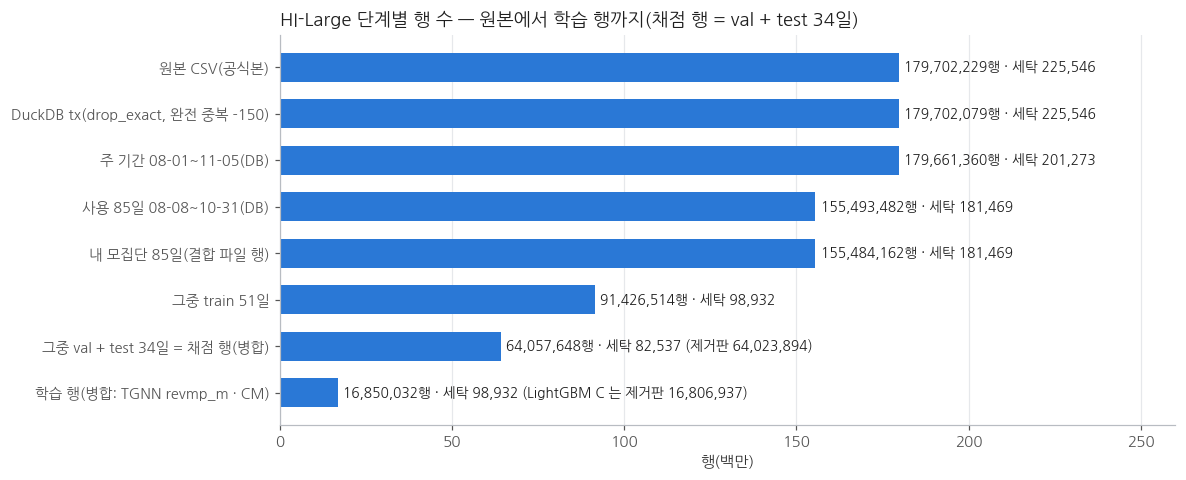

In [5]:
man = rj('/workspace/processed_9class/_nb_scratch/interim/HI-Large/manifest.json')
L0 = rj(EDA_DIR / 'results/L0_labels.json')
A0 = rd(FIXD / 'results/A0_일별_행수_세탁_165일.csv'); A0['d'] = pd.to_datetime(A0['day'])
JS = rj(META / 'joined_stats.json')
C36 = rj(TG / 'common/cache36_summary.json')
S7 = rj(US / 'common/step7_meta.json')
R2 = rd(FIXD / 'results/R2_행수라벨_전후.csv')
NA = rj(EDA_DIR / 'reprocess/align/new_align.json')
r2 = R2[R2['시점'] == '고치기 전'].set_index('구간')

in_main = (A0.d >= '2022-08-01') & (A0.d <= '2022-11-05'); in85 = (A0.d >= '2022-08-08') & (A0.d <= '2022-10-31')
train_days = set(L.days_of('train'))
pop85 = sum(v['rows'] for v in JS.values()); pos85 = sum(v['pos'] for v in JS.values())
pop_tr = sum(v['rows'] for d, v in JS.items() if d in train_days); pos_tr = sum(v['pos'] for d, v in JS.items() if d in train_days)
pop_ev = sum(v['rows'] for d, v in JS.items() if d not in train_days); pos_ev = sum(v['pos'] for d, v in JS.items() if d not in train_days)
n_tr_rows = S7['subsets']['cssmc_r300'] + int(r2.loc['train', '패턴밖_세탁_뺌'])       # 병합판 학습 행(TGNN revmp_m · CM)
_bs = {r['split']: r for r in C36['by_split']}
ev_merged = _bs['val']['joined_rows'] + _bs['test']['joined_rows']; ev_removed = _bs['val']['kept'] + _bs['test']['kept']
FUN = pd.DataFrame([
    ('① 원본 CSV(공식본)', man['n_rows'], L0['laundering_rows'], 'interim manifest.json · L0_labels.json'),
    ('③ DuckDB tx(drop_exact, 완전 중복 −150)', ds_meta['rows'], int(A0['pos'].sum()), 'meta/dataset.json · A0 합'),
    ('주 기간 08-01~11-05(DB)', int(A0.loc[in_main, 'rows'].sum()), int(A0.loc[in_main, 'pos'].sum()), 'A0'),
    ('사용 85일 08-08~10-31(DB)', int(A0.loc[in85, 'rows'].sum()), int(A0.loc[in85, 'pos'].sum()), 'A0'),
    ('④ 내 모집단 85일(결합 파일 행)', pop85, pos85, 'meta/joined_stats.json'),
    ('그중 train 51일', pop_tr, pos_tr, 'meta/joined_stats.json'),
    ('그중 val + test 34일 = 채점 행(병합)', pop_ev, pos_ev, f'joined_stats · 제거판 채점 행은 {ev_removed:,}(cache36 kept)'),
    ('⑧ 학습 행(병합: TGNN revmp_m · CM)', n_tr_rows, pos_tr, f"step7_meta + R2 · 학습된 LightGBM C 는 제거판 {C36['train_rows_cssmc_r300']:,}"),
], columns=['단계', '행', '세탁', '출처'])
# 파일끼리 대조
assert man['n_rows'] - ds_meta['rows'] == ds_meta['duplicate_extra_rows'] == 150
assert int(A0['rows'].sum()) == ds_meta['rows'] and int(A0['pos'].sum()) == L0['laundering_rows']
assert pop85 == int(r2.loc['합계', '모집단_행']) == sum(r['joined_rows'] for r in C36['by_split'])
assert pop_ev == ev_merged == 64_057_648 and ev_removed == 64_023_894
assert n_tr_rows == 16_850_032 and S7['subsets']['cssmc_r300'] == C36['train_rows_cssmc_r300'] == 16_806_937
show(FUN, '단계별 행 수(세탁 = Is Laundering 1)')
print('참고 — 옛 09-17 사슬:', f"{NA['n_raw']:,} → 센트 키 중복 −{NA['clean']['exact_duplicates']:,} → 꼬리 −{NA['trim']['rows_cut']:,} → {NA['n_proc']:,}행(new_align.json)")
print(f"채점 행 = val + test 만: 병합(09-29~) {ev_merged:,} · 제거판(09-22~28, 패턴 밖 뺌) {ev_removed:,}")
print(f"85일 합(train 포함 — 채점 행 아님): 병합 {pop85:,} · 제거판 {sum(r['kept'] for r in C36['by_split']):,}")
_lgbC = [l.rstrip() for l in open(TG / 'STATUS_log.txt', encoding='utf-8') if 'LGB55 학습 자료 끝' in l and 'SMOKE' not in l]
assert _lgbC and f"{C36['train_rows_cssmc_r300']:,}행" in _lgbC[-1], 'LightGBM C 학습 행이 기록과 다르다'
print(f"학습 행: 병합판 {n_tr_rows:,}(TGNN revmp_m · 아직 학습 안 한 CM) · 제거판 {C36['train_rows_cssmc_r300']:,}(학습이 끝난 LightGBM C) — STATUS_log: {_lgbC[-1][:80]}")

fig, ax = plt.subplots(figsize=(10.5, 4.6))
y = np.arange(len(FUN))[::-1]
ax.barh(y, FUN['행'] / 1e6, color='#2a78d6', height=0.62)
_note = {len(FUN) - 2: f' (제거판 {ev_removed:,})', len(FUN) - 1: f" (LightGBM C 는 제거판 {C36['train_rows_cssmc_r300']:,})"}
for i_, (yi, (n, p, lab)) in enumerate(zip(y, FUN[['행', '세탁', '단계']].to_numpy())):
    ax.text(n / 1e6 + 1.5, yi, f'{n:,}행 · 세탁 {p:,}' + _note.get(i_, ''), va='center', fontsize=9, color=INK)
ax.set_yticks(y); ax.set_yticklabels([re.sub('[①-⑩] ?', '', s).replace('−', '-') for s in FUN['단계']], fontsize=9.5); ax.set_xlim(0, 260)
ax.set_xlabel('행(백만)'); ax.grid(axis='y', visible=False)
ax.set_title('HI-Large 단계별 행 수 — 원본에서 학습 행까지(채점 행 = val + test 34일)', fontsize=12, loc='left', color=INK)
savefig(fig, 'F01_단계별_행수_깔때기.png')

---
## ① 원본 — 11열 CSV 공식본

| 파일 | 내용 | 비고 |
|---|---|---|
| `HI-Large_Trans.csv` | 거래 1줄 = 11열 | 09-17 03:02 Kaggle 공식본으로 교체(md5 검증, `HI-Large_EDA/download_hi_large.sh` · `finalize_hi_large_swap.sh`) |
| `HI-Large_accounts.csv` | 계좌 → 은행 이름 · 실체(entity) | KYC 조인에 쓴다(③) |
| `HI-Large_Patterns.txt` | 세탁 시도(attempt)별 거래 목록 · 패턴 이름 | 라벨 유형의 출처(②) |

- 11열: Timestamp(`YYYY/MM/DD HH:MM`, **분 단위**) · From Bank · Account · To Bank · Account · Amount Received · Receiving Currency · Amount Paid · Payment Currency · Payment Format · Is Laundering.
- **옛 짧은 파일**은 맨 앞 10,702행이 빠져 있었다(`reprocess/align/raw_compare.json` 의 S). 09-17 부터는 공식본만 쓴다.
- 원본 행 번호(0부터)가 파이프라인 전체의 거래 번호 `edge_id` 다(③ `daily_pipeline.py` 142줄).
- 아래는 **첫 줄 · 앞 몇 줄만** 읽는다. 전수 스캔은 하지 않는다.

In [6]:
files = {'transactions': RAW / 'HI-Large_Trans.csv', 'accounts': RAW / 'HI-Large_accounts.csv', 'patterns': RAW / 'HI-Large_Patterns.txt'}
HEADERS, ACCOUNT_HEADERS, RAW_COLUMNS = dp.HEADERS, dp.ACCOUNT_HEADERS, dp.RAW_COLUMNS
# ▼ 원본 /workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py:128-130 · 들여쓰기만 줄임 · 글자 그대로
for key,expected in [('transactions',HEADERS),('accounts',ACCOUNT_HEADERS)]:
    with files[key].open(newline='') as f:actual=next(csv.reader(f))
    if actual!=expected:raise ValueError(f'{key}: unexpected column order/header: {actual}')
# ▲ 원본 끝(daily_pipeline.py:128-130)
print('머리글 순서 검사 통과(거래 · 계좌)')
for k, p in files.items():
    with open(p, newline='') as f:
        head = [next(f).rstrip('\r\n') for _ in range(4 if k != 'patterns' else 6)]
    print(f'\n[{k}] {p.name} · {p.stat().st_size:,} B')
    for h in head: print('   ', h[:150])
rc = rj(EDA_DIR / 'reprocess/align/raw_compare.json')
print(f"\n옛 짧은 파일 {rc['old_rows']:,}행 · 공식본 {rc['new_rows']:,}행 · 앞에서 빠진 행 S = {rc['S']:,} · 밀어 맞춘 뒤 열 전부 같음: {all(rc['columns_equal_after_shift'].values())}")
print(f"공식본 행 수(interim manifest) {man['n_rows']:,} · 파일 크기 {man['csv_size']:,} B")

머리글 순서 검사 통과(거래 · 계좌)

[transactions] HI-Large_Trans.csv · 17,052,760,651 B
    Timestamp,From Bank,Account,To Bank,Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
    2022/08/01 00:17,020,800104D70,020,800104D70,6794.63,US Dollar,6794.63,US Dollar,Reinvestment,0
    2022/08/01 00:02,03196,800107150,03196,800107150,7739.29,US Dollar,7739.29,US Dollar,Reinvestment,0
    2022/08/01 00:17,01208,80010E430,01208,80010E430,1880.23,US Dollar,1880.23,US Dollar,Reinvestment,0

[accounts] HI-Large_accounts.csv · 147,691,860 B
    Bank Name,Bank ID,Account Number,Entity ID,Entity Name
    Portugal Bank #500,240522,82655C500,2AA04EEC5D0,Corporation #82502
    First Bank of Laramie,339367,8505ED380,2AA06B8AC80,Partnership #15630
    National Bank of Helena,368763,826283D80,2AA066499F0,Corporation #12918

[patterns] HI-Large_Patterns.txt · 13,807,473 B
    BEGIN LAUNDERING ATTEMPT - STACK
    2022/08/09 05:14,00952,8139F54E0,0111632,8062C56E0,5331

### 하루 행 수 · 세탁(165일, DB 기준)
- 출처: `fix_20260927/results/A0_일별_행수_세탁_165일.csv`(DuckDB `tx` 를 날짜별로 센 것, drop_exact 뒤).
- 색: 보정 기간(회색) · train · val · test · 최종 평가에만 붙는 11-01~05(연한 청록, **입력 아직 안 만듦**) · 꼬리(연한 회색).
- 꼬리(11-06~)는 진행 중이던 세탁의 나머지 거래만 남은 구간이다. 거래가 갑자기 줄고 세탁 비율이 튄다.

**기간별 합(A0)**

,기간,날짜,첫날,끝날,행,세탁
0,보정 08-01~07,7,2022-08-01,2022-08-07,"14,933,007","7,206"
1,train,51,2022-08-08,2022-09-27,"91,432,129","98,932"
2,val,17,2022-09-28,2022-10-14,"33,651,717","40,971"
3,test,17,2022-10-15,2022-10-31,"30,409,636","41,566"
4,11-01~05(최종 test 추가),5,2022-11-01,2022-11-05,"9,234,871","12,598"
5,꼬리 11-06~,68,2022-11-06,2023-01-12,"40,719","24,273"


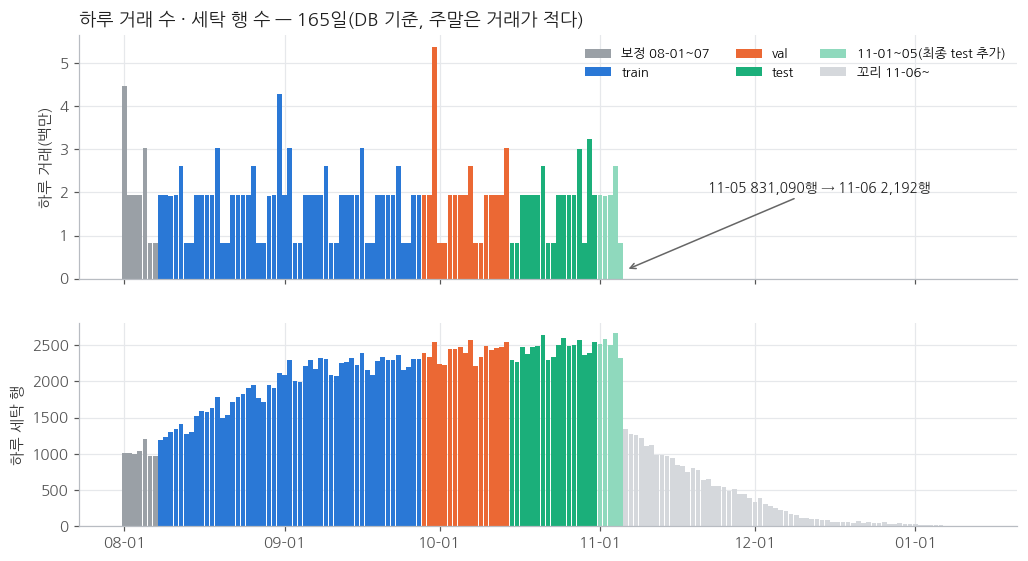

In [7]:
def period_of(d):
    s = str(d.date())
    if s < '2022-08-08': return '보정 08-01~07'
    for sp in ('train', 'val', 'test'):
        a, b = L.SPLIT_DAYS[sp]
        if a <= s <= b: return sp
    return '11-01~05(최종 test 추가)' if s <= '2022-11-05' else '꼬리 11-06~'
PC = {'보정 08-01~07': GRAY, 'train': SC['train'], 'val': SC['val'], 'test': SC['test'], '11-01~05(최종 test 추가)': '#8fd9bd', '꼬리 11-06~': LIGHT}
A0['기간'] = A0['d'].map(period_of)
show(A0.groupby('기간', sort=False).agg(날짜=('day', 'count'), 첫날=('day', 'first'), 끝날=('day', 'last'), 행=('rows', 'sum'), 세탁=('pos', 'sum')).reset_index().assign(세탁=lambda t: t['세탁'].astype(int)),
     '기간별 합(A0)')
fig, axes = plt.subplots(2, 1, figsize=(11, 5.8), sharex=True, gridspec_kw=dict(height_ratios=[1.2, 1]))
for k, g in A0.groupby('기간', sort=False):
    axes[0].bar(g['d'], g['rows'] / 1e6, width=0.9, color=PC[k], label=k)
    axes[1].bar(g['d'], g['pos'], width=0.9, color=PC[k])
axes[0].set_ylabel('하루 거래(백만)'); axes[1].set_ylabel('하루 세탁 행')
axes[0].legend(ncol=3, fontsize=8.5, frameon=False, loc='upper right')
r5, r6 = A0.set_index('day').loc['2022-11-05'], A0.set_index('day').loc['2022-11-06']
axes[0].annotate(f"11-05 {int(r5['rows']):,}행 → 11-06 {int(r6['rows']):,}행", xy=(pd.Timestamp('2022-11-06'), 0.2), xytext=(pd.Timestamp('2022-11-22'), 2.0),
                 fontsize=9, color=INK, arrowprops=dict(arrowstyle='->', color=MUTED))
axes[1].xaxis.set_major_locator(mdates.MonthLocator()); axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[0].set_title('하루 거래 수 · 세탁 행 수 — 165일(DB 기준, 주말은 거래가 적다)', fontsize=12, loc='left', color=INK)
savefig(fig, 'F02_하루_행수_세탁_165일.png')

---
## ② 라벨 · 모집단

지금 모델의 라벨은 **두 출처**가 같은 값을 준다.

| 출처 | 무엇 | 지금 쓰는 곳 |
|---|---|---|
| (a) 옛 09-17 전처리 `processed_9class/HI-Large_main/index_full.npz` | 처리 후 행마다 `y9`(0~7 패턴 · 8 그 밖) · `is_pos` · `attempt` | **라벨 값과 모집단**. 원본 행 번호로 펼쳐 캐시 · 결합 파일에 붙인다 |
| (b) 태훈님 DuckDB `pattern_labels.parquet` | Patterns.txt 거래를 11열 전부 일치로 원본 행에 붙인 것 | 시도 번호(attempt) · 검증 · EDA |

- 두 출처의 유형은 주 기간 179,650,681행 전부에서 **다른 행이 0** 이다(fix [G], `fix_20260927/results/G1 · G3`). 출처를 (b)로 바꾸는 정정안은 적용하지 않았다(부록 B).
- **모집단**: 옛 전처리가 남긴 행만 라벨을 가진다. 옛 전처리는 **센트 반올림 금액**으로 중복을 판정해 10,829행을 지웠다.
  - 그중 정확히 같은 거래는 150행뿐이고, 10,679행은 **가짜 중복**이다(Bitcoin 10,668 · USD 11, 세탁 0, 금액 차 최대 0.0099).
  - 이 행들은 라벨이 −1(모집단 밖)이 되어 학습 · 채점에서 **조용히 빠진다**. 85일로 보면 9,320행이다(모두 정상).
  - 되살리는 정정안 [D] 는 적용하지 않았다(09-24 트리에서는 넣어도 지표가 소수 다섯째 자리까지 같았다).

### (a) 옛 09-17 전처리에서 라벨 · 모집단에 닿는 부분
| 단계 | 코드 | 내용 |
|---|---|---|
| 중복 제거 | `prep9/lowmem.py` 141-178 `clean_rows` | 키 = 분 시각 · src · dst · **센트 반올림 금액(보낸 · 받은)** · 결제 수단 · 통화 2 · is_pos. 첫 행만 남김 |
| 꼬리 절단 | `prep9/lowmem.py` 184-201 `trim_tails` | 가장 많은 날의 5% 미만인 앞뒤 날 제거 → 08-01~11-05 |
| 패턴 매칭 | 09-17 판 셀 20 `load_patterns` · `attach_labels` | 키(분 · src · dst · 센트 · 결제 수단)로 세탁 행에 유형을 붙임 |
| y9 | `preprocess_9class.py` 70-81 `make_y9` | 0~7 그대로, 패턴 밖 세탁 + 정상 → 8 |
| 저장 | `preprocess_9class.py` 454-457 | `index_full.npz`(행 = 처리 후 순서 179,650,681) |

`index_full.npz` 는 **다시 만들지 않는다**(같은 경로에 덮어쓰게 되고, 지금 사슬은 이 파일을 그대로 쓴다). 아래는 코드를 보여 주기만 한다.

In [8]:
show_src('/workspace/prep9/lowmem.py', 148, 155, '중복 키: k1 = 분·src·dst, k2·k3 = 센트 금액(보낸·받은), k4 = 결제 수단·통화·is_pos')
show_src('/workspace/prep9/lowmem.py', 186, 191, '꼬리 절단: 가장 많은 날의 TAIL_MIN_FRAC(0.05) 미만인 앞뒤 날')
show_nb_src('/workspace/Final_preprocess/전처리_통합_HI-Large_20260917.ipynb', 20, 47, 56, '09-17 판 셀 20 attach_labels 앞부분 — JOIN_KEYS 로 세탁 행에 패턴을 붙인다')
show_src('/workspace/preprocess_9class.py', 70, 71, 'make_y9(설명 일부 생략)')
show_src('/workspace/preprocess_9class.py', 81, 81)
show_src('/workspace/preprocess_9class.py', 454, 457, 'index_full.npz 저장')

── /workspace/prep9/lowmem.py:148-155 · 중복 키: k1 = 분·src·dst, k2·k3 = 센트 금액(보낸·받은), k4 = 결제 수단·통화·is_pos
  148      k1 = (tso << (b_s + b_d)) | (raw['src_id'].astype(np.int64) << b_d) | raw['dst_id'].astype(np.int64)
  149      del tso
  150      # 금액(cents)은 조 단위까지 있어(HI-Large) 다른 키와 한 int64 에 못 묶는다 — 키 4개로 정렬한다.
  151      # 코드 4개(fmt·pay·recv ≤ 31, is_pos 0/1)만 int32 하나로 묶는다.
  152      k4 = ((raw['fmt_code'].astype(np.int32) << 11) | (raw['pay_code'].astype(np.int32) << 6)
  153            | (raw['recv_code'].astype(np.int32) << 1) | raw['is_pos'].astype(np.int32))
  154      k2, k3 = raw['cents'], raw['recv_cents']
  155      order = np.lexsort((k4, k3, k2, k1))                   # 안정 정렬: 같은 키는 원래 순서

── /workspace/prep9/lowmem.py:186-191 · 꼬리 절단: 가장 많은 날의 TAIL_MIN_FRAC(0.05) 미만인 앞뒤 날
  186          day = raw['ts_epoch_min'] // 1440
  187          uniq, cnt = np.unique(day, return_counts=True)
  188          thr = ns['TAIL_MIN_FRAC'] * float(cnt.max())
  189          ok = uniq[cnt

In [9]:
# 옛 전처리 기록(new_align.json · L0_labels.json)과 가짜 중복 감사
print('정리:', NA['clean']); print('꼬리:', NA['trim']); print('분할(옛 60/20/20):', {k: NA['split'][k] for k in ('val_start', 'test_start', 'rows')})
print('처리 후 행 → 원본 행 대조(index_full_equal):', NA['index_full_equal'])
print('패턴 매칭(L0):', {k: L0[k] for k in ('pattern_rows', 'pattern_rows_matched', 'pattern_rows_unmatched', 'unknown_pattern_names', 'laundering_rows')})
DA = rj(EDA_DIR / 'reprocess/dedup/dedup_audit_HI-Large.json')
show(pd.DataFrame([dict(센트키로_지운_행=DA['removed_by_our_key_cents'], 정확히_같은_행=DA['removed_by_exact_amounts'], 가짜_중복=DA['false_duplicates'],
                        가짜중_세탁=DA['false_duplicates_laundering'], 금액차_최대=DA['false_dup_max_abs_paid_diff'], 통화별=str(DA['false_dup_by_payment_currency']))]),
     '가짜 중복 감사(reprocess/dedup/dedup_audit_HI-Large.json)')
show(rd(FIXD / 'results/D1_되살린행_기간별.csv')[['기간', '되살린_행', '그중_세탁', 'Bitcoin', 'US_Dollar', '날짜수']],
     '가짜 중복이 기간별로 몇 행인가 — 지금은 모집단 밖(−1)으로 빠져 있다(fix D1, 적용 안 함)')
G1 = rd(FIXD / 'results/G1_유형_옛x새_대조.csv'); G3 = rd(FIXD / 'results/G3_유형_바뀐행_요약.csv')
_new = [c for c in G1.columns if c.startswith('새_')]
_off = sum(int(r[c]) for _, r in G1.iterrows() for c in _new if not c.startswith('새_' + r['옛_유형']) and not (c.startswith('새_8') and r['옛_유형'].startswith('8')))
print(f'옛 y9 유형 × 태훈님 pattern_labels 유형(G1): 대각선 밖 합 = {_off} · 바뀐 행 요약(G3) {len(G3)}줄')

정리: {'rows_in': 179702229, 'exact_duplicates': 10829, 'exact_duplicates_positive': 0, 'nonpositive_amount': 0, 'nonpositive_amount_positive': 0, 'rows_out': 179691400}
꼬리: {'threshold_per_day': 268973.25, 'kept_start': '2022-08-01', 'kept_end': '2022-11-05', 'kept_days': 97, 'rows_cut': 40719, 'positives_cut': 24273}
분할(옛 60/20/20): {'val_start': '2022-09-28T17:36', 'test_start': '2022-10-18T00:45', 'rows': [107790054, 35929921, 35930706]}
처리 후 행 → 원본 행 대조(index_full_equal): {'ts_min': True, 'src_id': True, 'dst_id': True, 'pair_id': True, 'split': True, 'is_pos': True}
패턴 매칭(L0): {'pattern_rows': 137936, 'pattern_rows_matched': 137936, 'pattern_rows_unmatched': 0, 'unknown_pattern_names': 0, 'laundering_rows': 225546}
읽음: /workspace/Final_preprocess/HI-Large_EDA/reprocess/dedup/dedup_audit_HI-Large.json


**가짜 중복 감사(reprocess/dedup/dedup_audit_HI-Large.json)**

,센트키로_지운_행,정확히_같은_행,가짜_중복,가짜중_세탁,금액차_최대,통화별
0,"10,829",150,"10,679",0,0.009895,"{'Bitcoin': 10668, 'US Dollar': 11}"


읽음: /workspace/Final_preprocess/fix_20260927/results/D1_되살린행_기간별.csv


**가짜 중복이 기간별로 몇 행인가 — 지금은 모집단 밖(−1)으로 빠져 있다(fix D1, 적용 안 함)**

,기간,되살린_행,그중_세탁,Bitcoin,US_Dollar,날짜수
0,0_보정(08-01~08-07),781,0,781,0,7
1,1_train(08-08~09-27),"5,615",0,"5,606",9,51
2,2_val(09-28~10-14),"1,933",0,"1,931",2,17
3,3_test17(10-15~10-31),"1,772",0,"1,772",0,17
4,4_되살린5일(11-01~11-05),578,0,578,0,5
5,5_꼬리(11-06~),0,0,0,0,0
6,합계(주 기간 97일),"10,679",0,"10,668",11,97
7,85일(train+val+test17),"9,320",0,"9,309",11,85


읽음: /workspace/Final_preprocess/fix_20260927/results/G1_유형_옛x새_대조.csv
읽음: /workspace/Final_preprocess/fix_20260927/results/G3_유형_바뀐행_요약.csv
옛 y9 유형 × 태훈님 pattern_labels 유형(G1): 대각선 밖 합 = 0 · 바뀐 행 요약(G3) 0줄


### (b) Patterns.txt 파싱 — 태훈님 방식을 실제로 돌린다(13.8 MB, 가볍다)
- `daily_pipeline.py` 208-235 의 앞부분(파싱)을 글자 그대로 옮겼다. 원본 거래와 11열 전부 일치로 붙이는 뒷부분(229-235)은 DuckDB 안에서만 돈다.
- 결과를 09-21 DB 가 만든 `pattern_labels.parquet`(저장본)과 대조한다: 행 수 · 시도 수 · 행별 유형 · 시도 번호.

In [10]:
# ▼ 원본 /workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py:209-227 · 들여쓰기만 줄임 · 글자 그대로
records=[];attempt=-1;ptype=None
with files['patterns'].open(newline='') as f:
    for line_no,line in enumerate(f,1):
        raw=line.rstrip('\r\n');s=raw.strip()
        if not s:continue
        if s.startswith('BEGIN'):
            if ptype is not None:raise ValueError('Nested pattern block')
            m=re.fullmatch(r'BEGIN LAUNDERING ATTEMPT - ([^:]+)(?::.*)?',s)
            if not m:raise ValueError(f'Bad BEGIN line {line_no}')
            attempt+=1;ptype=m.group(1).strip()
        elif s.startswith('END'):
            if ptype is None:raise ValueError('Unmatched END')
            ptype=None
        else:
            vals=next(csv.reader([raw]))
            if ptype is None or len(vals)!=11:raise ValueError(f'Bad pattern transaction {line_no}')
            records.append(dict(zip(RAW_COLUMNS,vals),attempt_id=attempt,pattern_type=ptype,pattern_row_id=len(records)))
if ptype is not None:raise ValueError('Unclosed pattern block')
pat=pd.DataFrame(records,columns=RAW_COLUMNS+['attempt_id','pattern_type','pattern_row_id'])
# ▲ 원본 끝(daily_pipeline.py:209-227)
PL = pd.read_parquet(META / 'pattern_labels.parquet'); print('읽음:', META / 'pattern_labels.parquet')
PLs = PL.sort_values('pattern_row_id').reset_index(drop=True)
assert len(pat) == len(PLs) and (PLs['pattern_row_id'].to_numpy() == np.arange(len(pat))).all()
assert (PLs['pattern_type'].to_numpy() == pat['pattern_type'].to_numpy()).all() and (PLs['attempt_id'].to_numpy() == pat['attempt_id'].to_numpy()).all()
assert not PL['edge_id'].duplicated().any()
tb = pat.groupby('pattern_type').agg(거래=('attempt_id', 'size'), 시도=('attempt_id', 'nunique')).sort_values('거래', ascending=False).reset_index()
tb.loc[len(tb)] = ['합계', len(pat), pat['attempt_id'].nunique()]
show(tb, f'Patterns.txt 파싱 결과 — pattern_labels.parquet 과 행별 유형 · 시도 번호까지 같음')
print('패턴 이름 → 내부 클래스 번호:', {n: i for i, n in enumerate(L.CLASS_NAMES[:8])})
del pat, PLs, records; _ = gc.collect()

읽음: /workspace/Final_preprocess/HI-Large_EDA/_work/tree9_20260921/meta/pattern_labels.parquet


**Patterns.txt 파싱 결과 — pattern_labels.parquet 과 행별 유형 · 시도 번호까지 같음**

,pattern_type,거래,시도
0,SCATTER-GATHER,"26,978","2,067"
1,GATHER-SCATTER,"26,361","2,054"
2,STACK,"23,624","2,096"
3,FAN-OUT,"13,554","2,040"
4,FAN-IN,"13,287","2,014"
5,CYCLE,"12,340","2,086"
6,BIPARTITE,"12,174","2,109"
7,RANDOM,"9,618","2,001"
8,합계,"137,936","16,467"


패턴 이름 → 내부 클래스 번호: {'FAN-OUT': 0, 'FAN-IN': 1, 'CYCLE': 2, 'SCATTER-GATHER': 3, 'GATHER-SCATTER': 4, 'BIPARTITE': 5, 'STACK': 6, 'RANDOM': 7}


### (c) 원본 행 번호로 펼친 라벨 — `label_arrays`(지금 모델이 쓰는 라벨)
- `new_proc2raw.npy`(처리 후 행 → 원본 행)로 원본 행 크기 배열을 만들고 `y9` · `is_pos` 를 흩어 넣는다. 모집단 밖 행은 −1.
- 캐시 · 결합 파일을 만들 때 쓰는 변환 `y9_of`: `y9 < 0` → −1(모집단 밖) · `y9 < 8` → 패턴 · `is_pos == 1` → −1(패턴 밖, 09-22~28 규칙) · 나머지 → 8.
  09-29 부터는 학습 · 채점 때 패턴 밖을 다시 8로 바꾼다(⑦).
- 기본 실행에서는 큰 배열(1.6 GB · 719 MB)을 열지 않는다. 헤더(모양 · 자료형)만 읽는다.
- `RUN_LABELS_RAW` 의 실행 셀은 **③ DuckDB 셀 바로 뒤**에 있다. 노트북 A 도 DuckDB 가 끝난 뒤 `label_arrays` 를 부른다(`build_nb_A.py` 174줄이 §1 82-98 뒤).
  DuckDB 가 도는 동안 라벨 배열(약 360 MB)을 메모리에 들고 있지 않기 위해서다.

In [11]:
show_src('/workspace/Final_preprocess/HI-Large_EDA/tree9_lib.py', 183, 197, 'label_arrays — 원본 행 번호 → 내 y9 · is_pos')
def npz_header(p):
    """확인용: npz 안 배열의 모양 · 자료형만 읽는다(값은 읽지 않음)."""
    out = {}
    with zipfile.ZipFile(p) as z:
        for n in z.namelist():
            with z.open(n) as f:
                v = np.lib.format.read_magic(f)
                sh, _, dt = (np.lib.format.read_array_header_1_0 if v == (1, 0) else np.lib.format.read_array_header_2_0)(f)
                out[n[:-4]] = (sh, str(dt))
    return out
IDXF = Path('/workspace/processed_9class/HI-Large_main/index_full.npz'); P2R = EDA_DIR / 'reprocess/align/new_proc2raw.npy'
H = npz_header(IDXF); print(f'index_full.npz {IDXF.stat().st_size:,} B:', H)
p2r = np.load(P2R, mmap_mode='r'); print(f'new_proc2raw.npy {P2R.stat().st_size:,} B: {p2r.shape} {p2r.dtype} · 앞 3개 {np.asarray(p2r[:3]).tolist()}')
assert H['y9'][0] == (NA['n_proc'],) == p2r.shape; del p2r
PA = np.load(META / 'pos_attempt.npz'); print('읽음:', META / 'pos_attempt.npz')
_y = PA['y9']; _pat = _y < 8
print(f"주 기간 세탁 {len(_y):,}행 = 패턴 {int(_pat.sum()):,} + 패턴 밖 {int((~_pat).sum()):,} · 패턴 시도 {len(np.unique(PA['attempt'][_pat])):,}개")
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py:175-178 · 글자 그대로
def y9_of(eid):
    """0~7 패턴 · 8 정상 · −1 = 뺄 행(패턴 밖 세탁, 내 모집단 밖). tree_gnn_9class.py:323-327 과 같음(사용자 결정 09-22)."""
    y9, ip = y9_raw[eid], ip_raw[eid]
    return np.where(y9 < 0, -1, np.where(y9 < 8, y9, np.where(ip == 1, -1, 8))).astype(np.int8)
# ▲ 원본 끝(build_nb_A.py:175-178)
print('y9_of 준비됨 — 원본 행 라벨 배열(y9_raw · ip_raw)은 RUN_LABELS_RAW 를 켰을 때 ③ DuckDB 셀 뒤에서 만든다(노트북 A 와 같은 순서)')

── /workspace/Final_preprocess/HI-Large_EDA/tree9_lib.py:183-197 · label_arrays — 원본 행 번호 → 내 y9 · is_pos
  183  def label_arrays():
  184      """원본 행 번호(0부터) → 내 y9·is_pos. 내 모집단에 없는 행은 -1."""
  185      f = WORK / 'labels_raw.npz'
  186      if f.exists():
  187          z = np.load(f)
  188          return z['y9'], z['is_pos']
  189      n_raw = int(json.loads((INTERIM / 'manifest.json').read_text())['n_rows'])
  190      p2r = np.load(EDA / 'reprocess/align/new_proc2raw.npy')
  191      idx = np.load(MAIN / 'index_full.npz')
  192      y9 = np.full(n_raw, -1, np.int8)
  193      y9[p2r] = idx['y9']
  194      ip = np.full(n_raw, -1, np.int8)
  195      ip[p2r] = idx['is_pos'].astype(np.int8)
  196      np.savez(f, y9=y9, is_pos=ip)
  197      return y9, ip

index_full.npz 1,622,463,633 B: {'ts_min': ((179650681,), 'int64'), 'src_id': ((179650681,), 'int32'), 'dst_id': ((179650681,), 'int32'), 'pair_id': ((179650681,), 'int64'), 'split': ((179650681,), 'int8'), 'y9': ((179650681,),

---
## ③ 태훈님 DuckDB — 3단계(dataset · pairagg · features)

**설정**: `experiments/split_60_20_20/plan.json` 의 `data_config` 그대로(`tree9_lib.make_cfg`, 147-151줄). 바꾼 것은 경로(`source` · `output`)와 DuckDB 자원(`threads=4` · `memory_limit='14GB'`)뿐이다.

| 설정 | 값 | 뜻 |
|---|---|---|
| `duplicate_policy` | `drop_exact` | 11열 **원문 글자**가 전부 같은 묶음에서 첫 `edge_id` 만 남김 → 150행 제거 |
| `calibration_start` · `train_start` | 08-01 · 08-08 | 통화 기준을 맞추는 보정 기간 = 08-01~07(학습 전) |
| `history_days` | 30 | 노드 창 = [D−29, D] **당일 포함** = 일 마감 판정(09-29 사용자 결정) |
| `incoming_neighbors` | 10 | 계좌마다 받은 거래 최근 10건(⑨ 캐시) |
| `val_start` · `test_start` · `test_end` | 09-01 · 10-01 · 11-01 | **DB `split` 열에만** 쓰인다. 실제 분할이 아니다(⑥) |

**코드 지도**(`daily_pipeline.py`)
| 줄 | 하는 일 |
|---|---|
| 142-144 | 원본을 `row_number() − 1 = edge_id`(원본 0부터 행 번호)로 넣는다 |
| 148-159 | 형식 검사(빈 칸 · 숫자 · 16진 계좌 · 금액 · 시각). 틀린 행이 있으면 멈춘다 |
| 161-174 | 11열 hash 로 중복 감사 → `drop_exact` 면 묶음의 첫 행만 남긴다 |
| 175-197 | 노드(은행 앞 0 정리 + 계좌) · KYC 조인 · 국가 · 실체 유형 |
| 199-207 | `split` 열 CASE · `tx` 테이블 |
| 208-235 | 패턴 라벨(②) |
| 249-269 | 계좌쌍 하루 시작 스냅샷(그날 전체 제외): 이력 수 · 반대 방향 수 · 나이 |
| 279-291 | 통화 기준: 보정 기간 송금 · 수취 금액 합쳐 중앙값 scale · median · IQR |
| 293-297 | 리듬 창: `RANGE … INTERVAL '1 minute' PRECEDING` — 같은 분 거래는 서로 안 보인다 |
| 298-317 | 엣지 18식 · NaN 이 있으면 멈춤 |
| 343-403 | `load_day`: 노드 23열(창 [D−29, D]) · 받은 문맥 10건 · 대상 = 그날 거래 전부 |

- **새 폴더 규칙**: 같은 출력 폴더에 단계 기록(json)이 있으면 멈춘다(`fresh_stage`, 103-105). 설정이나 코드가 바뀌면 `require_stage` 가 멈춘다(94-101).

In [12]:
cfg = L.make_cfg(L.RAW_DIR, DB)                           # tree9_lib.py:147-151 — 09-21 · 09-28 · 09-30 DB 와 같은 설정
_now, _old = asdict(cfg), ds_meta['config']
_diff = {k: (_old[k], _now[k]) for k in _now if _now[k] != _old[k]}
assert set(_diff) == {'output'}, _diff
print('09-21 DB 설정과 다른 것은 출력 폴더뿐:', _diff)
show(pd.DataFrame([(k, _now[k]) for k in ('source', 'duplicate_policy', 'calibration_start', 'train_start', 'val_start', 'test_start', 'test_end',
                                          'history_days', 'incoming_neighbors', 'target_batch_size', 'threads', 'memory_limit')], columns=['설정', '값']), 'DB 설정(make_cfg)')
show_src('/workspace/Final_preprocess/HI-Large_EDA/tree9_lib.py', 147, 151)
show_src('/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py', 142, 144, 'edge_id = 원본 0부터 행 번호')
show_src('/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py', 172, 174, 'drop_exact: 중복 묶음의 첫 edge_id 만 남김')
show_src('/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py', 199, 199, 'DB split 열 — 실제 분할 아님(⑥)')
show_src('/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py', 279, 283, '통화 기준(보정 기간, 송금+수취)')
show_src('/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py', 293, 297, '리듬 창: 1분 이전까지만')
show_src('/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py', 349, 356, '노드 창 [D−29, D] — 당일 포함(일 마감)')

09-21 DB 설정과 다른 것은 출력 폴더뿐: {'output': ('/tmp/tree9_work/db_full', '/tmp/prep_integrated_20260930/db_full')}


**DB 설정(make_cfg)**

,설정,값
0,source,/workspace/IBM_AML_dataset
1,duplicate_policy,drop_exact
2,calibration_start,2022-08-01
3,train_start,2022-08-08
4,val_start,2022-09-01
5,test_start,2022-10-01
6,test_end,2022-11-01
7,history_days,30
8,incoming_neighbors,10
9,target_batch_size,4096


── /workspace/Final_preprocess/HI-Large_EDA/tree9_lib.py:147-151
  147  def make_cfg(source, output, threads: int = 4, memory_limit: str = '14GB'):
  148      """태훈님 split_60_20_20/plan.json 의 data_config 그대로. 바꾸는 것: source·output(경로), threads·memory_limit(DuckDB 자원)."""
  149      d = dict(PLAN_SPLIT['data_config'])
  150      d.update(source=str(source), output=str(output), threads=threads, memory_limit=memory_limit)
  151      return dp.Config(**d)

── /workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py:142-144 · edge_id = 원본 0부터 행 번호
  142              c.execute(f'''CREATE OR REPLACE TABLE raw AS SELECT row_number() OVER ()-1 AS edge_id,*
  143                FROM read_csv({sql_string(files['transactions'])},header=true,columns={cols},
  144                parallel=false,strict_mode=true,nullstr='')''')

── /workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py:172-174 · drop_exact: 중복 묶음의 첫 edge_id 만 남김
  172          c.

In [13]:
# DB 결과 기록(09-21 DB 저장본 meta) · 네 번 돌린 시간
print({k: ds_meta[k] for k in ('rows', 'nodes', 'kyc_unmatched_nodes', 'duplicate_extra_rows')})
DUP = rd(META / 'duplicate_audit.csv')
print(f"중복 감사: {len(DUP)}행 = {DUP['duplicate_group_id'].nunique()}묶음 × multiplicity {sorted(DUP['multiplicity'].unique().tolist())} → 지운 행 {int((DUP['edge_id'] != DUP['duplicate_group_id']).sum())}")
print('pair_days(계좌쌍 × 날):', f"{rj(META / 'pairagg.json')['pair_days']:,}")
show(rd(META / 'dataset_summary.csv').rename(columns={'split': 'DB split 열'}), 'DB split 열별 행(dataset_summary.csv) — ⑥ 참고: 실제 분할과 다르다')
_t = {'09-21(노트북 20)': rj(META / 'step2_timing.json'), '09-28(노트북 A)': rj(TG / 'common/duckdb_timing.json'),
      '09-30 복구 ① 01:47 시작(04:07 컨테이너 재생성으로 캐시 단계에서 끊김)': rj(TG / '_fix/recover_20260930/duckdb_timing_복구_중단_0407.json'),
      '09-30 복구 ② 04:12 재시작(지금 도는 연쇄의 DB)': rj(TG / '_fix/recover_20260930/duckdb_timing_복구.json')}
TT = pd.DataFrame([dict(실행=k, 단계=s, 초=v[s]['sec'], anon_피크_GiB=v[s]['anon_peak_gib']) for k, v in _t.items() for s in ('dataset', 'pairagg', 'features')])
_TS = TT.pivot(index='실행', columns='단계', values='초').reindex(list(_t))[['dataset', 'pairagg', 'features']].assign(합계_분=lambda t: (t.sum(axis=1) / 60).round(1))
show(_TS, 'DuckDB 3단계 시간(초)')
show(TT.pivot(index='실행', columns='단계', values='anon_피크_GiB').reindex(list(_t))[['dataset', 'pairagg', 'features']], 'anon 피크(GiB) — mem_guard 는 19.14 GiB 에서 가장 큰 작업을 죽인다')
print(f"네 번의 합계 {_TS['합계_분'].min()}~{_TS['합계_분'].max()}분 · anon 피크 {TT['anon_피크_GiB'].min()}~{TT['anon_피크_GiB'].max()} GiB")
print('DB 크기: 31.2 GiB(09-24 실측, MANIFEST) · daily.duckdb 21 GB + edges 5.0 + edge_features 5.5 + pair_daily 0.4 GB(tree9_20260921/README.txt)')

{'rows': 179702079, 'nodes': 2116168, 'kyc_unmatched_nodes': 0, 'duplicate_extra_rows': 150}
읽음: /workspace/Final_preprocess/HI-Large_EDA/_work/tree9_20260921/meta/duplicate_audit.csv
중복 감사: 300행 = 150묶음 × multiplicity [2] → 지운 행 150
읽음: /workspace/Final_preprocess/HI-Large_EDA/_work/tree9_20260921/meta/pairagg.json
pair_days(계좌쌍 × 날): 93,609,308
읽음: /workspace/Final_preprocess/HI-Large_EDA/_work/tree9_20260921/meta/dataset_summary.csv


**DB split 열별 행(dataset_summary.csv) — ⑥ 참고: 실제 분할과 다르다**

,DB split 열,rows,positives,first_ts,last_ts
0,calibration,"14,933,007","7,206",2022-08-01,2022-08-07 23:59:00
1,train,"44,535,079","38,834",2022-08-08,2022-08-31 23:59:00
2,val,"56,137,066","67,372",2022-09-01,2022-09-30 23:59:00
3,test,"54,821,337","75,263",2022-10-01,2022-10-31 23:59:00
4,outside,"9,275,590","36,871",2022-11-01,2023-01-12 16:49:00


읽음: /workspace/Final_preprocess/HI-Large_EDA/_work/tree9_20260921/meta/step2_timing.json
읽음: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/common/duckdb_timing.json
읽음: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_fix/recover_20260930/duckdb_timing_복구_중단_0407.json
읽음: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_fix/recover_20260930/duckdb_timing_복구.json


**DuckDB 3단계 시간(초)**

단계,dataset,pairagg,features,합계_분
실행,,,,
09-21(노트북 20),1300.6,147.8,948.7,40.0
09-28(노트북 A),1174.2,131.2,933.2,37.3
09-30 복구 ① 01:47 시작(04:07 컨테이너 재생성으로 캐시 단계에서 끊김),1261.5,136.0,896.5,38.2
09-30 복구 ② 04:12 재시작(지금 도는 연쇄의 DB),1373.8,151.4,950.5,41.3


**anon 피크(GiB) — mem_guard 는 19.14 GiB 에서 가장 큰 작업을 죽인다**

단계,dataset,pairagg,features
실행,,,
09-21(노트북 20),15.96,16.21,17.41
09-28(노트북 A),16.22,16.62,16.14
09-30 복구 ① 01:47 시작(04:07 컨테이너 재생성으로 캐시 단계에서 끊김),15.03,15.20,15.46
09-30 복구 ② 04:12 재시작(지금 도는 연쇄의 DB),15.32,15.35,15.28


네 번의 합계 37.3~41.3분 · anon 피크 15.03~17.41 GiB
DB 크기: 31.2 GiB(09-24 실측, MANIFEST) · daily.duckdb 21 GB + edges 5.0 + edge_features 5.5 + pair_daily 0.4 GB(tree9_20260921/README.txt)


**무거운 셀 — `RUN_DUCKDB`**(노트북 A §1 을 그대로 옮김). 새 폴더 `/tmp/prep_integrated_20260930/db_full` 에 만든다.
단계마다 anon 6 GiB 미만인지 확인한다(0-4 셀의 공통 검사에 더해). 자체 한도 18.5 GiB 를 넘으면 멈춘다. 기록상 37~41분.

In [14]:
if RUN_DUCKDB:
    # ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py:82-98 · 스위치 안으로 들여씀 · 글자 그대로
    cfg = L.make_cfg(L.RAW_DIR, DB)
    T = {}
    guard = L.AnonGuard(18.5, marker=W / 'ANON_GUARD.txt').start()
    try:
        for name, fn in [('dataset', dp.build_dataset), ('pairagg', dp.build_pairagg), ('features', dp.build_features)]:
            if (DB / f'{name}.json').exists():
                print(name, '이미 있음 — 건너뜀'); continue
            assert L.anon_gib() < 6, f'다른 무거운 작업이 돌고 있다(anon {L.anon_gib():.1f} GiB)'
            L.check_disk(); guard.reset_peak(); status(f'DUCKDB {name} 시작 (/tmp 여유 {L.free_gib("/tmp"):.0f} GiB)'); t = time.time()
            fn(cfg)
            T[name] = dict(sec=round(time.time() - t, 1), anon_peak_gib=round(guard.peak_anon, 2))
            status(f'DUCKDB {name} 끝 {T[name]}')
            if name == 'dataset': L.drop_cache(L.RAW_DIR / 'HI-Large_Trans.csv')
    finally:
        guard.stop()
    (COMMON / 'duckdb_timing.json').write_text(json.dumps(T, ensure_ascii=False, indent=1))
    dp.require_stage(cfg, 'features'); print('DuckDB 준비 끝', T)
    # ▲ 원본 끝(build_nb_A.py:82-98)
else:
    print('RUN_DUCKDB 꺼짐 — DB 를 만들지도 열지도 않는다')

RUN_DUCKDB 꺼짐 — DB 를 만들지도 열지도 않는다


**무거운 셀 — `RUN_LABELS_RAW`**(② (c) 의 원본 행 라벨, 노트북 A §3 의 한 줄). DuckDB 가 끝난 **뒤**에 만든다(노트북 A 와 같은 순서).
`index_full.npz` 와 `new_proc2raw.npy` 를 읽어 `/tmp/prep_integrated_20260930/labels_raw.npz` 에 저장한다. 09-30 두 번의 복구에서 DuckDB 끝 → 다음 단계까지 6초였다(부록 D).

In [15]:
if RUN_LABELS_RAW:
    # ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py:174-174 · 스위치 안으로 들여씀 · 글자 그대로
    y9_raw, ip_raw = L.label_arrays()
    # ▲ 원본 끝(build_nb_A.py:174-174)
    Y9_RAW, IP_RAW = y9_raw, ip_raw                            # 수정판 TGNN 코드가 쓰는 이름
    print('원본 행 라벨', len(y9_raw), '· 모집단 밖', int((y9_raw < 0).sum()), '· 저장', L.WORK / 'labels_raw.npz')
else:
    print('RUN_LABELS_RAW 꺼짐 — 원본 행 라벨 배열을 만들지 않는다(RUN_CACHE36 은 없으면 스스로 만든다)')

RUN_LABELS_RAW 꺼짐 — 원본 행 라벨 배열을 만들지 않는다(RUN_CACHE36 은 없으면 스스로 만든다)


---
## ④ 결합 파일(09-21) — 하루 1파일, LightGBM 입력의 원천이자 캐시의 대조 기준

| 항목 | 내용 |
|---|---|
| 한 줄 | 거래 1건 = `src_` 노드 22 + `dst_` 노드 22 + 엣지 18 = 62열 + `y9` · `is_pos` · `weight` · `edge_id` |
| 노드 22열 | `load_day` 앞부분(노드 값 계산까지)을 **소스 글자 그대로** 잘라 실행(`tree9_lib.py` 154-168). `net_count_ratio` 는 태훈님 plan 에서 빠짐 |
| 엣지 18열 | `day_targets`(171-179) — `load_day` 의 대상 쿼리와 같은 문장 |
| 라벨 | ② 의 `y9` · `is_pos` 를 `edge_id` 로 붙이고 **모집단 밖(y9 < 0)은 뺀다** |
| 가중치 | 세탁 300 / 정상 1(`POS_WEIGHT`, 56줄) |
| 저장본 | `HI-Large_EDA/_work/tree9_20260921/joined/`(85개, 6.0 GiB). `/tmp` 원본과 크기 · 행 수 같음(README) |

- 멈춤 조건(노트북 20 셀 7): 태훈님 라벨과 내 `is_pos` 불일치 · 노드를 못 찾은 행 0.1% 초과.
- 이 결합 파일은 **LightGBM 55열의 직접 입력**(⑩)이고, 노트북 A 가 캐시를 만들 때 **날마다 대조하는 기준**(⑨)이다.

In [16]:
show_src('/workspace/Final_preprocess/HI-Large_EDA/tree9_lib.py', 201, 238, 'join_day')

── /workspace/Final_preprocess/HI-Large_EDA/tree9_lib.py:201-238 · join_day
  201  def join_day(cfg, day: str, y9_raw, ip_raw, out_dir: Path, edge_map=None) -> dict:
  202      """거래 1줄 = src_ 노드 22 + dst_ 노드 22 + 엣지 18 (+ y9·is_pos·weight·edge_id). 노드는 DuckDB node_id 로 붙인다.
  203      edge_map: 작은 기간 DB 의 edge_id → 원본 행 번호(전체 DB 에서는 None = edge_id 가 곧 원본 행 번호)."""
  204      t0 = time.time()
  205      node_ids, N = node_values(cfg, day)
  206      t1 = time.time()
  207      T = day_targets(cfg, day)
  208      t2 = time.time()
  209      src, dst = T['src'].to_numpy(np.int64), T['dst'].to_numpy(np.int64)
  210      si = np.minimum(np.searchsorted(node_ids, src), len(node_ids) - 1)
  211      di = np.minimum(np.searchsorted(node_ids, dst), len(node_ids) - 1)
  212      ok_s, ok_d = node_ids[si] == src, node_ids[di] == dst
  213      X = np.empty((len(T), 62), np.float32)
  214      X[:, :22] = N[si]
  215      X[:, 22:44] = N[di]
  216      X[:, 44:] = T[EDGE18].to_numpy(np.float32)


In [17]:
# 확인용: 저장본 85개 파일의 메타데이터(행 수 · 열 이름)만 읽어 기록과 대조
C36L = rd(TG / 'common/cache36_log.csv').set_index('day')
rows = []
for d in L.days_of('train') + L.days_of('val') + L.days_of('test'):
    pf = pq.ParquetFile(SAVED_JD / f'day={d}.parquet')
    if not rows: COLS = pf.schema_arrow.names
    rows.append(dict(day=d, 파일_행=pf.metadata.num_rows, 기록_행=JS[d]['rows'], 캐시_joined_rows=int(C36L.loc[d, 'joined_rows'])))
JR = pd.DataFrame(rows)
assert (JR['파일_행'] == JR['기록_행']).all() and (JR['파일_행'] == JR['캐시_joined_rows']).all()
assert COLS == L.F62 + ['y9', 'is_pos', 'weight', 'edge_id'] and len(COLS) == 66
print(f"85개 파일 행 합 {JR['파일_행'].sum():,} = joined_stats.json = cache36_log joined_rows · 열 {len(COLS)}개(62 + y9 · is_pos · weight · edge_id)")
ST = pd.DataFrame([JS[d] for d in JR['day']]); ST['split'] = ST['day'].map({d: s for s in ('train', 'val', 'test') for d in L.days_of(s)})
G = ST.groupby('split', sort=False).agg(일수=('day', 'count'), 태훈님_행=('rows_taehoon', 'sum'), 모집단_밖=('rows_outside_my_population', 'sum'),
                                          결합_행=('rows', 'sum'), 세탁=('pos', 'sum'), 패턴=('pos_pattern', 'sum'), 라벨_불일치=('label_mismatch', 'sum'),
                                          노드_못찾음=('node_missing_rows', 'sum'), NaN_칸=('nan_cells', 'sum'), 파일_MB=('file_mb', 'sum')).reset_index()
show(G, '분할별 결합 결과(meta/joined_stats.json)')
assert G[['라벨_불일치', '노드_못찾음', 'NaN_칸']].to_numpy().sum() == 0
print('결합 단계 시간(step2_timing.json join):', rj(META / 'step2_timing.json')['join'])

읽음: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/common/cache36_log.csv


85개 파일 행 합 155,484,162 = joined_stats.json = cache36_log joined_rows · 열 66개(62 + y9 · is_pos · weight · edge_id)


**분할별 결합 결과(meta/joined_stats.json)**

,split,일수,태훈님_행,모집단_밖,결합_행,세탁,패턴,라벨_불일치,노드_못찾음,NaN_칸,파일_MB
0,train,51,"91,432,129","5,615","91,426,514","98,932","55,837",0,0,0,3558.4
1,val,17,"33,651,717","1,933","33,649,784","40,971","24,280",0,0,0,1337.6
2,test,17,"30,409,636","1,772","30,407,864","41,566","24,503",0,0,0,1225.5


읽음: /workspace/Final_preprocess/HI-Large_EDA/_work/tree9_20260921/meta/step2_timing.json
결합 단계 시간(step2_timing.json join): {'sec': 11391.000000000002, 'sec_node': 10294.2, 'files_gib': 5.98, 'anon_peak_gib': 17.69}


**무거운 셀 — `RUN_JOIN`**(노트북 20 셀 1 의 시작 검사 · 감시 줄 + 셀 7 을 옮김). 저장본이 있으므로 보통 끈다. 켜면 `/tmp/prep_integrated_20260930/joined` 에 새로 만든다(DB · 라벨이 먼저 있어야 한다).
- 시작 검사(셀 1 의 7-8줄): anon 6 GiB 미만 · 디스크 여유. 감시 한도는 원래 24 GiB 였지만 mem_guard(19.14)보다 높아 쓸모가 없으므로 **18.5 GiB 로 바꿨다**(머리 주석에 적음). 결합 단계 anon 피크 기록은 17.69 GiB 다.
- 끝나면 새 결합 파일이 저장본과 행 수 · 열 · 기록(joined_stats)이 같은지, 첫날은 모든 열 값이 같은지 대조한다(이 노트북 추가). 위 확인 셀은 저장본만 본다.

In [18]:
if RUN_JOIN:
    JD.mkdir(parents=True, exist_ok=True)
    # ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/notebooks/20_태훈님코드_전체계산.ipynb 셀 1:7-9 · 스위치 안으로 들여씀 · 바꾼 곳: L.AnonGuard(24.0, → L.AnonGuard(18.5, | # 24 GiB = 프롬프트 v2 멈춤 조건 → # 18.5 GiB = mem_guard 19.14 보다 먼저 멈춤(이 노트북에서 바꿈)
    a, _ = L.mem('시작'); assert a < 6, '다른 무거운 작업이 돌고 있다'
    L.check_disk()
    guard = L.AnonGuard(18.5, marker=L.WORK / 'ANON_GUARD_nb20.txt').start()     # 18.5 GiB = mem_guard 19.14 보다 먼저 멈춤(이 노트북에서 바꿈)
    # ▲ 원본 끝(20_태훈님코드_전체계산.ipynb:7-9)
    # ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/notebooks/20_태훈님코드_전체계산.ipynb 셀 7:1-15 · 스위치 안으로 들여씀 · 글자 그대로
    y9_raw, ip_raw = L.label_arrays(); L.mem('라벨')
    SFILE = L.WORK / 'joined_stats.json'
    stats = json.loads(SFILE.read_text()) if SFILE.exists() else {}
    days = L.days_of('train') + L.days_of('val') + L.days_of('test'); assert len(days) == 85
    for i, day in enumerate(days):
        if day in stats and (JD / f'day={day}.parquet').exists(): continue
        L.check_disk(); guard.reset_peak()
        st = L.join_day(cfg, day, y9_raw, ip_raw, JD); st['anon_peak_gib'] = round(guard.peak_anon, 2)
        assert st['label_mismatch'] == 0, f'멈춤 조건: 태훈님 라벨과 내 is_pos 불일치 {day} {st}'
        assert st['node_missing_rows'] <= 0.001 * st['rows_taehoon'], f'멈춤 조건: 노드 값 못 찾은 행 0.1% 초과 {day} {st}'
        stats[day] = st; SFILE.write_text(json.dumps(stats, ensure_ascii=False, indent=1))
        print(f"[{time.strftime('%H:%M:%S')}] {i+1}/85 {day} 행 {st['rows']:,} 세탁 {st['pos']:,} · 노드 {st['sec_node']}초 + 엣지 {st['sec_targets']}초 = {st['sec_total']}초 · anon 피크 {st['anon_peak_gib']} GiB · {st['file_mb']} MB", flush=True)
        gc.collect()
    ST = pd.DataFrame([stats[d] for d in days])
    ST['split'] = ['train'] * len(L.days_of('train')) + ['val'] * len(L.days_of('val')) + ['test'] * len(L.days_of('test'))
    # ▲ 원본 끝(20_태훈님코드_전체계산.ipynb:1-15)
    guard.stop()
    # 확인용(이 노트북 추가): 새 결합 파일이 저장본과 같은가 — 85개 행 수 · 열 이름 · 기록, 첫날은 모든 열 값
    for _d in days:
        _a, _b = pq.ParquetFile(JD / f'day={_d}.parquet'), pq.ParquetFile(SAVED_JD / f'day={_d}.parquet')
        assert _a.metadata.num_rows == _b.metadata.num_rows == JS[_d]['rows'] and _a.schema_arrow.names == _b.schema_arrow.names, _d
        assert all(stats[_d][k] == JS[_d][k] for k in ('rows_taehoon', 'rows_outside_my_population', 'rows', 'pos', 'pos_pattern')), _d
    _a, _b = pq.ParquetFile(JD / f'day={days[0]}.parquet'), pq.ParquetFile(SAVED_JD / f'day={days[0]}.parquet')
    for _c in _b.schema_arrow.names:
        assert np.array_equal(_a.read(columns=[_c]).column(0).to_numpy(), _b.read(columns=[_c]).column(0).to_numpy()), (days[0], _c)
    print(f'새 결합 파일 {len(days)}개 = 저장본(행 수 · 열 · 기록) · 첫날 {days[0]} 모든 열 값 같음')
else:
    print('RUN_JOIN 꺼짐 — 결합 파일은 저장본을 읽기만:', JD)

RUN_JOIN 꺼짐 — 결합 파일은 저장본을 읽기만: /workspace/Final_preprocess/HI-Large_EDA/_work/tree9_20260921/joined


---
## ⑤ 36피처 — 노드 19 + 엣지 17 · 결제 수단 제외

- 정본 명세: `태훈님_전처리/FEATURE_SPEC_36_피처추가_docs브랜치_7e457c5.md`(docs 브랜치 7e457c5, 09-23). 열 표: `Final_preprocess/aml_feature_schema.csv`(36행).
- 태훈님 코드의 노드 23 · 엣지 18 에서 **고른다**(값은 태훈님 코드 그대로). 엣지 끝에 **`amt_z_pay_ccy` 한 열을 더한다**.
- 채택 근거(명세 99-106줄): 시드 42/43/44 검증 AP 평균 0.609885 → 0.621124. 명세가 가리키는 protocol · RESULTS 파일은 저장소에 없다(끊긴 링크).

| 구분 | 내용 |
|---|---|
| 뺀 노드 4 | `net_count_ratio` · `reciprocity_ratio` · `mean_received_currency_z` · `received_outlier_fraction` |
| 뺀 엣지 2 | `paid_currency_unseen` · `received_currency_unseen` |
| 더한 엣지 1 | `amt_z_pay_ccy` = `clip((ln(1+paid) − μ_c) / (σ_c + 1e−6), −10, 10)` · μ · σ = 보정 기간 [08-01, 08-08) **송금액만**, 결제 통화별 평균 · 모표준편차 |
| 비슷한 기존 열 | `paid_currency_z`(median/IQR, ±8, 송금 · 수취 합쳐 적합). 이름만 다른 중복이 아니다(명세 89줄) |
| 결제 수단 | 태훈님 18엣지 · 23노드에 **처음부터 없다**. 세탁 거래가 ACH 한 값에 몰려 있어 의도적으로 뺐다(09-29 사용자 재확인) |

- `amt_z_pay_ccy` 는 태훈님 코드(`build_extras`)가 저장소에 없어 **명세 문장대로 계산**했다. 태훈님 값과 **미대조**다(`amtz_meta.json` 의 `대조`).

In [19]:
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py:65-74 · 글자 그대로
# 36피처 열 — 스키마 순서 그대로. 노드 이름은 스키마(공백 판) = 태훈님 코드 이름
SCH = pd.read_csv(SCHEMA, encoding='utf-8-sig')
NODE19 = list(SCH.query("tensor=='node'").sort_values('col_index')['feature'])
EDGE17 = list(SCH.query("tensor=='edge'").sort_values('col_index')['feature'])
assert len(NODE19) == 19 and len(EDGE17) == 17 and EDGE17[-1] == 'amt_z_pay_ccy'
NODE_IDX = [dp.NODE_FEATURES.index(f) for f in NODE19]
EDGE_IDX = [dp.EDGE_FEATURES.index(f) for f in EDGE17[:16]]
assert NODE_IDX == sorted(NODE_IDX) and EDGE_IDX == list(range(16)), '스키마 순서가 태훈님 코드 순서와 다르다'
print('빼는 노드:', [f for f in dp.NODE_FEATURES if f not in NODE19])
print('빼는 엣지:', [f for f in dp.EDGE_FEATURES if f not in EDGE17], '· 더하는 엣지: amt_z_pay_ccy')
# ▲ 원본 끝(build_nb_A.py:65-74)
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py:194-194 · 글자 그대로
ESEL = np.array(EDGE_IDX); NSEL = np.array(NODE_IDX)
# ▲ 원본 끝(build_nb_A.py:194-194)
SCH_SHOW = SCH[['tensor', 'col_index', 'feature', 'value_type', 'group', 'definition', 'ap_drop_pp']].copy()
SCH_SHOW['definition'] = SCH_SHOW['definition'].str.slice(0, 70)
show(SCH_SHOW, '36피처 표(aml_feature_schema.csv · BOM 이 있어 utf-8-sig 로 읽음)')
print('이진 열', int((SCH['value_type'] == 'binary').sum()), '개 · 연속 열', int((SCH['value_type'] == 'continuous').sum()), '개')

빼는 노드: ['net_count_ratio', 'reciprocity_ratio', 'mean_received_currency_z', 'received_outlier_fraction']
빼는 엣지: ['paid_currency_unseen', 'received_currency_unseen'] · 더하는 엣지: amt_z_pay_ccy


**36피처 표(aml_feature_schema.csv · BOM 이 있어 utf-8-sig 로 읽음)**

,tensor,col_index,feature,value_type,group,definition,ap_drop_pp
0,node,0,log_out_count,continuous,활동규모,L(30일 문맥의 송금 거래 수). 자기 이체 포함,1.112
1,node,1,log_in_count,continuous,활동규모,L(30일 문맥의 수취 거래 수). 자기 이체 포함,1.868
2,node,2,log_out_neighbors,continuous,연결구조,L(서로 다른 수신 노드 수). 자기 이체 시 자신 포함,1.033
3,node,3,log_in_neighbors,continuous,연결구조,L(서로 다른 송신 노드 수). 자기 이체 시 자신 포함,0.230
4,node,4,log_self_count,continuous,연결구조,L(src=dst인 송금 거래 수),0.308
5,node,5,log_reciprocal_neighbors,continuous,연결구조,L(A→B와 B→A가 모두 존재하는 상대 B 수). A 자신 제외,3.605
6,node,6,mean_paid_currency_z,continuous,금액통화,30일 송금 거래의 paid_currency_z 평균. 송금 없으면 0,0.757
7,node,7,paid_outlier_fraction,continuous,금액통화,30일 송금 중 abs(paid_currency_z)>=3 비율. 송금 없으면 0,0.012
8,node,8,log_currency_count,continuous,금액통화,L(송금 통화와 수취 통화의 합집합 크기),0.756
9,node,9,log_active_days,continuous,활동일,L(송금 또는 수취가 1회 이상 발생한 날짜 수),0.042


이진 열 11 개 · 연속 열 25 개


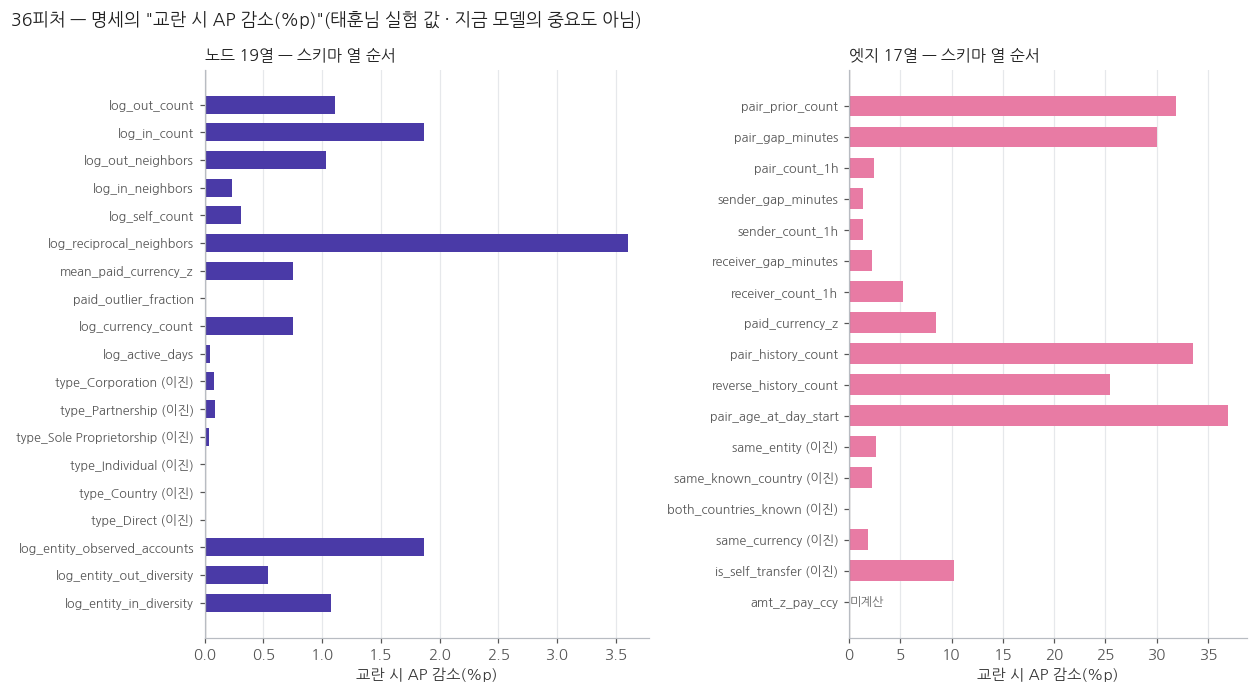

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 6.4), gridspec_kw=dict(width_ratios=[19, 17]))
for ax, t in zip(axes, ('node', 'edge')):
    s = SCH[SCH['tensor'] == t].sort_values('col_index')
    yy = np.arange(len(s))[::-1]
    v = pd.to_numeric(s['ap_drop_pp'], errors='coerce')                  # amt_z_pay_ccy 는 명세에 '미계산'
    ax.barh(yy, v.fillna(0), color=TC[t], height=0.66)
    for yi, vv in zip(yy, v):
        if pd.isna(vv): ax.text(0.1, yi, '미계산', va='center', fontsize=8, color=MUTED)
    ax.set_yticks(yy); ax.set_yticklabels([f"{f}{' (이진)' if v == 'binary' else ''}" for f, v in zip(s['feature'], s['value_type'])], fontsize=8.3)
    ax.axvline(0, color=MUTED, lw=0.8); ax.grid(axis='y', visible=False)
    ax.set_title(f"{'노드' if t == 'node' else '엣지'} {len(s)}열 — 스키마 열 순서", fontsize=10.5, loc='left', color=INK)
    ax.set_xlabel('교란 시 AP 감소(%p)')
fig.suptitle('36피처 — 명세의 "교란 시 AP 감소(%p)"(태훈님 실험 값 · 지금 모델의 중요도 아님)', fontsize=11.5, x=0.01, ha='left', color=INK)
fig.tight_layout()
savefig(fig, 'F06_36피처_표.png')

### `amt_z_pay_ccy` — 저장된 배열 · 통화별 기준 · 식 재현
- 배열: `tgnn36_20260928/common/amt_z_pay_ccy_f32.npy`(원본 행 번호 인덱스, 719 MB). 기본 실행에서는 mmap 으로 **몇 개 값만** 읽는다.
- NaN 150 = drop_exact 로 지운 행(tx 에 없음). Bitcoin 36행이 +10 에서 잘렸다.

In [21]:
AZ = np.load(AZ_SAVED, mmap_mode='r')                          # 기본: 09-28 배열(읽기만). RUN_AMTZ 면 아래 셀이 새 배열로 바꾼다
AM = rj(TG / 'common/amtz_meta.json'); print({k: AM[k] for k in ('정의', '보정기간', '통화수', 'NaN_행', '대조', 'sha1')})
assert AZ.shape == (man['n_rows'],) and AM['원본_행수'] == man['n_rows'] and AM['NaN_행'] == 150
A1Z = rd(TG / 'results/A1_amtz_통화별_보정통계.csv')
CUR = pd.read_parquet(META / 'currency_stats.parquet'); print('읽음:', META / 'currency_stats.parquet')
AMT = A1Z[['통화', '보정_행수', 'mu', 'sigma', '전체_행수', 'clip_-10', 'clip_+10']].merge(
    CUR.rename(columns={'currency': '통화', 'scale': 'pz_scale', 'med': 'pz_med', 'iqr': 'pz_iqr'}), on='통화', how='left')
show(AMT.round(4), 'amt_z 통화별 기준(A1, 송금액만 · 평균/표준편차) 과 paid_currency_z 기준(currency_stats, 송금+수취 · median/IQR)')

# 확인용: 원본 CSV 앞 2,000행의 Amount Paid · Payment Currency 로 명세 식을 다시 계산해 저장 배열과 비교
mu, sd = dict(zip(A1Z['통화'], A1Z['mu'])), dict(zip(A1Z['통화'], A1Z['sigma']))
with open(RAW / 'HI-Large_Trans.csv', newline='') as f:
    r = csv.reader(f); next(r); smp = [(i, float(v[7]), v[8]) for i, v in zip(range(2000), r)]
e = np.array([s[0] for s in smp]); p = np.array([s[1] for s in smp]); cc = [s[2] for s in smp]
z = np.clip((np.log(1.0 + p) - np.array([mu[c] for c in cc])) / (np.array([sd[c] for c in cc]) + 1e-6), -10, 10).astype(np.float32)
dz = float(np.abs(z - np.asarray(AZ[e])).max())
print(f'앞 2,000행(08-01) 식 재현 최대 차 {dz:.2e} · 통화 {len(set(cc))}종'); assert dz < 1e-5

읽음: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/common/amtz_meta.json
{'정의': 'clip((ln(1+paid)-mu_c)/(sigma_c+1e-6),-10,10), mu·sigma 비유한이면 0', '보정기간': '[2022-08-01, 2022-08-08)', '통화수': 15, 'NaN_행': 150, '대조': '태훈님 build_extras 와 미대조', 'sha1': 'b5400b29ec0f8c029922f1a5c34f2f79b1574fe8'}
읽음: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/results/A1_amtz_통화별_보정통계.csv
읽음: /workspace/Final_preprocess/HI-Large_EDA/_work/tree9_20260921/meta/currency_stats.parquet


**amt_z 통화별 기준(A1, 송금액만 · 평균/표준편차) 과 paid_currency_z 기준(currency_stats, 송금+수취 · median/IQR)**

,통화,보정_행수,mu,sigma,전체_행수,clip_-10,clip_+10,pz_scale,pz_med,pz_iqr
0,Australian Dollar,"429,782",7.3313,2.9032,"5,182,297",0,0,1338.900,0.6931,1.8092
1,Bitcoin,"320,318",0.5235,1.1158,"3,904,291",0,36,0.074,0.6931,1.8794
2,Brazil Real,"294,383",8.7002,2.9445,"3,544,798",0,0,5420.130,0.6931,1.8266
3,Canadian Dollar,"505,116",7.2378,2.8860,"6,075,569",0,0,1209.170,0.6931,1.8014
4,Euro,"3,429,215",6.8338,2.8840,"41,214,346",0,0,801.570,0.6931,1.8118
5,Mexican Peso,"395,300",10.0012,3.0281,"4,737,795",0,0,20934.250,0.6931,1.8355
6,Ruble,"457,625",11.2740,3.1262,"5,491,287",0,0,75154.880,0.6931,1.8834
7,Rupee,"345,295",11.1989,3.1545,"4,160,681",0,0,70654.610,0.6931,1.8767
8,Saudi Riyal,"264,367",8.3004,2.9337,"3,181,040",0,0,3633.220,0.6931,1.8114
9,Shekel,"660,369",8.1822,2.9417,"7,933,432",0,0,3164.950,0.6931,1.8283


앞 2,000행(08-01) 식 재현 최대 차 0.00e+00 · 통화 3종


**무거운 셀 — `RUN_AMTZ`**(노트북 A §2 를 옮김). 저장본이 있으므로 보통 끈다. 켜면 새 배열을 `/tmp/prep_integrated_20260930/` 에, 통화 표 · meta 는 `out/` 에 쓴다. DB 가 먼저 있어야 한다.
- 원본의 레코드 배치 변수 `rd` 는 `_rb` 로 이름만 바꿨다. 그대로 두면 이 노트북의 표 읽기 도우미 `rd()` 를 덮어 뒤 셀이 전부 멈춘다(생성기의 이름 덮기 검사가 잡는다).

In [22]:
if RUN_AMTZ:
    # ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py:106-157 · 스위치 안으로 들여씀 · 바꾼 곳: COMMON / 'amt_z_pay_ccy_f32.npy' → AZ_NEW | rd = c.execute( → _rb = c.execute( | for b in rd: → for b in _rb:
    if (AZ_NEW).exists():
        AZ = np.load(AZ_NEW, mmap_mode='r'); print('amt_z 있음 — 건너뜀', AZ.shape)
    else:
        status('AMTZ 시작'); t0 = time.time()
        y9_raw, ip_raw = L.label_arrays(); N_RAW = len(y9_raw); del y9_raw, ip_raw
        c = dp.connect(cfg, read_only=True)
        try:
            cur = [r[0] for r in c.execute('SELECT DISTINCT payment_currency FROM tx ORDER BY 1').fetchall()]
            rows = []
            for i, cc in enumerate(cur):
                p = c.execute(f"""SELECT paid::DOUBLE AS p FROM tx WHERE payment_currency={dp.sql_string(cc)}
                     AND ts>={dp.sql_string(CAL[0])}::TIMESTAMP AND ts<{dp.sql_string(CAL[1])}::TIMESTAMP ORDER BY edge_id""").fetchnumpy()['p']
                v = np.log(1.0 + p.astype(np.float64))
                mu = float(v.mean()) if len(v) else float('nan'); sd = float(v.std(ddof=0)) if len(v) else float('nan')
                zr = (v - mu) / (sd + 1e-6) if len(v) else v
                rows.append(dict(통화=cc, 코드=i, 보정_행수=len(v), mu=mu, sigma=sd, sigma_0=bool(len(v) and sd == 0.0),
                                 보정_z평균=float(zr.mean()) if len(v) else float('nan'), 보정_z표준편차=float(zr.std()) if len(v) else float('nan'),
                                 보정_paid0=int((p == 0).sum())))
            S = pd.DataFrame(rows)
            MU = S['mu'].to_numpy(np.float64); SD = S['sigma'].to_numpy(np.float64)
            OKC = np.isfinite(MU) & np.isfinite(SD)                    # 비유한 → 그 통화 거래는 0
            case = 'CASE payment_currency ' + ' '.join(f'WHEN {dp.sql_string(cc)} THEN {i}' for i, cc in enumerate(cur)) + ' ELSE -1 END'
            AZ = np.full(N_RAW, np.nan, np.float32)                    # tx 에 없는 원본 행(중복 제거분)은 NaN 으로 남는다
            n_all = np.zeros(len(cur), np.int64); lo = np.zeros(len(cur), np.int64); hi = np.zeros(len(cur), np.int64); n_tx = 0
            _rb = c.execute(f'SELECT edge_id, {case} AS cc, paid::DOUBLE AS p FROM tx').fetch_record_batch(5_000_000)
            for b in _rb:
                e = b.column(0).to_numpy(); k = b.column(1).to_numpy().astype(np.int64); p = b.column(2).to_numpy()
                assert (k >= 0).all(), '통화 목록 밖 값'
                ok = OKC[k]; z = np.zeros(len(e), np.float64)
                zr = (np.log(1.0 + p[ok]) - MU[k[ok]]) / (SD[k[ok]] + 1e-6)
                z[ok] = np.clip(zr, -10.0, 10.0)
                z[~np.isfinite(z)] = 0.0
                AZ[e] = z.astype(np.float32)
                n_all += np.bincount(k, minlength=len(cur)); lo += np.bincount(k[ok][zr <= -10], minlength=len(cur))
                hi += np.bincount(k[ok][zr >= 10], minlength=len(cur)); n_tx += len(e)
        finally:
            c.close()
        S['전체_행수'] = n_all; S['clip_-10'] = lo; S['clip_+10'] = hi; S['기준_유한'] = OKC
        S.to_csv(RES / 'A1_amtz_통화별_보정통계.csv', index=False, encoding='utf-8-sig')
        fin = np.isfinite(AZ)
        assert int(fin.sum()) == n_tx and float(np.nanmin(AZ)) >= -10 and float(np.nanmax(AZ)) <= 10
        np.save(AZ_NEW, AZ)
        meta = dict(정의='clip((ln(1+paid)-mu_c)/(sigma_c+1e-6),-10,10), mu·sigma 비유한이면 0', 보정기간=f'[{CAL[0]}, {CAL[1]})',
                    통화수=len(cur), 기준_비유한_통화=[cur[i] for i in np.flatnonzero(~OKC)], sigma0_통화=list(S.loc[S.sigma_0, '통화']),
                    tx_행수=n_tx, 원본_행수=N_RAW, NaN_행=int((~fin).sum()), 대조='태훈님 build_extras 와 미대조',
                    sha1=sha1(AZ_NEW), sec=round(time.time() - t0, 1))
        (COMMON / 'amtz_meta.json').write_text(json.dumps(meta, ensure_ascii=False, indent=1))
        status(f'AMTZ 끝 ({meta["sec"]}초 · 통화 {len(cur)} · NaN {meta["NaN_행"]:,})')
        AZ = np.load(AZ_NEW, mmap_mode='r')
    print(pd.read_csv(RES / 'A1_amtz_통화별_보정통계.csv').to_string(index=False))
    print(json.loads((COMMON / 'amtz_meta.json').read_text()))
    # ▲ 원본 끝(build_nb_A.py:106-157)
else:
    print('RUN_AMTZ 꺼짐 — 09-28 배열을 읽기만:', AZ_SAVED)

RUN_AMTZ 꺼짐 — 09-28 배열을 읽기만: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/common/amt_z_pay_ccy_f32.npy


### 결제 수단을 뺀 근거(측정)
- 주 기간 패턴 세탁 거의 전부가 ACH 한 값이다(아래 표). 이 열을 넣으면 모델이 "ACH 인가"만 배울 위험이 크다.
- 뺀 뒤 모델이 ACH 에 기대지 않는지: ACH 거래만 남겨도 세탁 여부 AP 가 떨어지지 않는다(`review_leakage_20260929/results/ACH1`, val 만 보인다).

In [23]:
PF = rd(EDA_DIR / 'results/A1_결제수단별_세탁비율.csv')
show(PF[PF['범위'] == '주기간(전처리 대상)'].drop(columns='범위').round(4), '결제 수단별 세탁(주 기간 08-01~11-05, 옛 모집단)')
AC = rd(EDA_DIR / 'review_leakage_20260929/results/ACH1_세탁여부AP_부분집합.csv')
show(AC[AC['split'] == 'val'][['모델', '부분', '행', '패턴세탁', '세탁여부_AP', '정밀도', '재현율']].round(4), 'ACH 만 남겼을 때 세탁 여부 AP(val · 09-29 모델, 패턴 밖 제외 라벨)')

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/A1_결제수단별_세탁비율.csv


**결제 수단별 세탁(주 기간 08-01~11-05, 옛 모집단)**

,결제수단,거래수,정상,패턴 세탁,패턴 밖 세탁,세탁수,세탁비율(%),패턴 비율(%),패턴 밖 비율(%)
0,ACH,"22,085,448","21,910,553","113,650","61,245","174,895",0.7919,0.5146,0.2773
1,Bitcoin,"3,894,249","3,892,644",10,"1,595","1,605",0.0412,0.0003,0.0410
2,Cash,"18,412,981","18,409,318",0,"3,663","3,663",0.0199,0.0000,0.0199
3,Cheque,"70,586,103","70,572,843",0,"13,260","13,260",0.0188,0.0000,0.0188
4,Credit Card,"50,856,118","50,848,272",0,"7,846","7,846",0.0154,0.0000,0.0154
5,Reinvestment,"7,410,555","7,410,555",0,0,0,0.0000,0.0000,0.0000
6,Wire,"6,405,227","6,405,223",3,1,4,0.0001,0.0000,0.0000


읽음: /workspace/Final_preprocess/HI-Large_EDA/review_leakage_20260929/results/ACH1_세탁여부AP_부분집합.csv


**ACH 만 남겼을 때 세탁 여부 AP(val · 09-29 모델, 패턴 밖 제외 라벨)**

,모델,부분,행,패턴세탁,세탁여부_AP,정밀도,재현율
0,TGNN36,전체,"33,633,093","24,280",0.8811,0.5697,0.9799
1,TGNN36,ACH만,"4,082,177","24,278",0.8992,0.6173,0.9799
2,TGNN36,ACH 아님,"29,550,916",2,0.0001,0.0000,0.0000
6,LGB55 r299,전체,"33,633,093","24,280",0.9688,0.6344,0.9976
7,LGB55 r299,ACH만,"4,082,177","24,278",0.9695,0.6599,0.9976
8,LGB55 r299,ACH 아님,"29,550,916",2,0.1074,0.0014,1.0000


---
## ⑥ 분할 — 날짜 기준. 네 가지 정의가 함께 있으니 **어느 것인지 적는다**

| 정의 | train | val | test | 쓰는 곳 |
|---|---|---|---|---|
| **개발 · 팔 비교(지금)** 51/17/17 | 08-08~09-27 | 09-28~10-14 | 10-15~10-31 | `tree9_lib.SPLIT_DAYS`(54줄) · 모든 노트북의 assert |
| **최종 평가** 51/17/22 | 같음 | 같음 | 10-15~**11-05** | 09-29 사용자 결정. **11-01~05 입력은 아직 안 만듦** |
| DB `tx.split` 열 24/30/31일 | 08-08~08-31 | 09-01~09-30 | 10-01~10-31 | `daily_pipeline.py` 199 + `data_config`. **분할 판단에 쓰면 틀린다** |
| 옛 09-17 행 기준 60/20/20 | ~09-28 17:36 | ~10-18 00:45 | ~11-05 | `new_align.json`. 지금 안 씀 |
| 보정(통화 기준) | 08-01~08-07 | | | `daily_pipeline.py` 279-281 · `build_nb_A.py` 47 |

- 팔(설정) 비교는 **val 만** 본다. test 는 팀이 최종 설정을 고른 뒤 그 하나만 연다.
- 11-01~05 가 빠진 이유: plan.json 의 `test_end 2022-11-01` 을 그대로 따랐다(fix [A]). 진짜 꼬리는 11-06 부터다.
- 11-01~05 를 붙이는 방법(미결 · 부록 B): 최종 모델이 정해진 뒤 그 모델만 5일 입력으로 채점 → test 17일과 이어 붙여 22일 지표.

In [24]:
show_src('/workspace/Final_preprocess/HI-Large_EDA/tree9_lib.py', 52, 57)
FINAL_TEST = ('2022-10-15', '2022-11-05')                    # 09-29 사용자 결정(최종 평가만)
n = {s: len(L.days_of(s)) for s in ('train', 'val', 'test')}; n_final = len(pd.date_range(*FINAL_TEST, freq='D'))
print('개발 분할 날짜 수', n, '· 최종 test', n_final, '일'); assert n == {'train': 51, 'val': 17, 'test': 17} and n_final == 22
F1 = rd(FIXD / 'results/F1_분할정의_두개.csv')
show(F1.drop(columns='출처'), 'DB split 열 vs 실제로 쓴 분할(fix F1)')
show(rd(FIXD / 'results/A2_경계에_걸친_사건.csv'), '분할 경계에 걸친 세탁 시도(fix A2) — 경계를 넘는 시도는 잘린 채로 둔다(미래 정보를 앞으로 옮기지 않음)')
P0 = rd(FIXD / 'results/P0_precheck_1101_1105_라벨보유.csv')
show(P0, '11-01~05(최종 test 에만 붙을 5일) · 10-31 · 11-06 — DB 행과 내 라벨(fix P0)')
_b5 = FIXD / '_backup/joined_v2_new5'
NEW5 = [(p.name, pq.ParquetFile(p).metadata.num_rows, len(pq.ParquetFile(p).schema_arrow.names)) for p in sorted(_b5.glob('day=*.parquet'))]
print('11-01~05 LightGBM 재료(fix_20260927/_backup/joined_v2_new5, 정정안 판):', NEW5)
# 확인용: 재료 행 = DB 행(되살린 행 포함) · 내 모집단 기준 5일 행 · test 22일 행 수 두 가지
_p5 = P0.set_index('day').loc[[f'2022-11-0{i}' for i in range(1, 6)]]
n5_db, n5_my = int(_p5['rows_tx'].sum()), int(_p5['my_in_population'].sum())
assert len(NEW5) == 5 and {c for _, _, c in NEW5} == {67} and sum(n for _, n, _ in NEW5) == n5_db
_f1 = F1[F1['정의'].str.startswith('고친 분할')].set_index('구간')['행']
_te17 = {r['split']: r for r in C36['by_split']}['test']['joined_rows']
t22_my, t22_fix = _te17 + n5_my, int(_f1['3_test17(10-15~10-31)'] + _f1['4_되살린5일(11-01~11-05)'])
assert n5_db - n5_my == 578 and t22_my == 39_642_157 and t22_fix == 39_644_507
print(f'재료 5개 · 67열 · 행 합 {n5_db:,} = DB 행(P0 rows_tx) — 되살린 {n5_db - n5_my}행 포함, 내 모집단 기준이면 {n5_my:,}행')
print(f'test 22일 행: 내 모집단 기준 {t22_my:,} = test17 {_te17:,} + 11-01~05 {n5_my:,}(09-29 구현 방침, 세션상태 0929 229줄) '
      f'· 정정안(되살림 포함, fix F1) {t22_fix:,}')

── /workspace/Final_preprocess/HI-Large_EDA/tree9_lib.py:52-57
   52  # 분할(태훈님 GNN_REPORT §6.2, 날짜 기준, 양 끝 포함) — 사용자·태훈님 2인 잠정 합의(09-21)
   53  # 주의(2026-09-27 주석만 추가): DuckDB tx.split 열(train 08-08~08-31 · val 9월 · test 10월)은 태훈님 data_config 기준이라 아래와 다르다 — 분할은 이 SPLIT_DAYS 로만 판단한다. 공식 주 기간 끝은 11-05(10-31 아님): fix_20260927/ 참고.
   54  SPLIT_DAYS = {'train': ('2022-08-08', '2022-09-27'), 'val': ('2022-09-28', '2022-10-14'), 'test': ('2022-10-15', '2022-10-31')}
   55  EXPECT_POS = {'train': 98_932, 'val': 40_971, 'test': 41_566}          # 태훈님 GNN_REPORT §6.2 표
   56  POS_WEIGHT = 300.0                                                     # 사용자 결정 (가), 태훈님 GNN_REPORT 211·216줄
   57  CLASS_NAMES = ['FAN-OUT', 'FAN-IN', 'CYCLE', 'SCATTER-GATHER', 'GATHER-SCATTER', 'BIPARTITE', 'STACK', 'RANDOM', '정상+패턴밖']

개발 분할 날짜 수 {'train': 51, 'val': 17, 'test': 17} · 최종 test 22 일
읽음: /workspace/Final_preprocess/fix_20260927/results/F1_분할정의_두개.csv


**DB split 열 vs 실제로 쓴 분할(fix F1)**

,정의,구간,시작,끝,행,세탁
0,DB tx.split 열(태훈님 data_config),calibration,2022-08-01,2022-08-07,"14,933,007","7,206"
1,DB tx.split 열(태훈님 data_config),train,2022-08-08,2022-08-31,"44,535,079","38,834"
2,DB tx.split 열(태훈님 data_config),val,2022-09-01,2022-09-30,"56,137,066","67,372"
3,DB tx.split 열(태훈님 data_config),test,2022-10-01,2022-10-31,"54,821,337","75,263"
4,DB tx.split 열(태훈님 data_config),outside,2022-11-01,2023-01-12,"9,275,590","36,871"
5,우리가 실제로 쓴 분할(tree9_lib.SPLIT_DAYS 51/17/17) — 고치기 전,0_보정(08-01~08-07),NaN,NaN,"14,932,226","7,206"
6,우리가 실제로 쓴 분할(tree9_lib.SPLIT_DAYS 51/17/17) — 고치기 전,1_train(08-08~09-27),NaN,NaN,"91,426,514","98,932"
7,우리가 실제로 쓴 분할(tree9_lib.SPLIT_DAYS 51/17/17) — 고치기 전,2_val(09-28~10-14),NaN,NaN,"33,649,784","40,971"
8,우리가 실제로 쓴 분할(tree9_lib.SPLIT_DAYS 51/17/17) — 고치기 전,3_test17(10-15~10-31),NaN,NaN,"30,407,864","41,566"
9,우리가 실제로 쓴 분할(tree9_lib.SPLIT_DAYS 51/17/17) — 고치기 전,4_되살린5일(11-01~11-05),NaN,NaN,"9,234,293","12,598"


읽음: /workspace/Final_preprocess/fix_20260927/results/A2_경계에_걸친_사건.csv


**분할 경계에 걸친 세탁 시도(fix A2) — 경계를 넘는 시도는 잘린 채로 둔다(미래 정보를 앞으로 옮기지 않음)**

...

읽음: /workspace/Final_preprocess/fix_20260927/results/P0_precheck_1101_1105_라벨보유.csv


**11-01~05(최종 test 에만 붙을 5일) · 10-31 · 11-06 — DB 행과 내 라벨(fix P0)**

,day,rows_tx,pos_tx,my_in_population,my_outside,my_pos,my_pos_pattern,my_label_mismatch,th_pattern_rows,pos_outside_my_population
0,2022-10-31,"1,935,577","2,543","1,935,468",109,"2,543","1,444",0,"1,444",0
1,2022-11-01,"1,928,540","2,520","1,928,421",119,"2,520","1,440",0,"1,440",0
2,2022-11-02,"1,927,739","2,587","1,927,600",139,"2,587","1,468",0,"1,468",0
3,2022-11-03,"1,928,144","2,498","1,928,016",128,"2,498","1,457",0,"1,457",0
4,2022-11-04,"2,619,358","2,667","2,619,212",146,"2,667","1,471",0,"1,471",0
5,2022-11-05,"831,090","2,326","831,044",46,"2,326","1,412",0,"1,412",0
6,2022-11-06,"2,192","1,339",0,"2,192",0,0,0,"1,339","1,339"


11-01~05 LightGBM 재료(fix_20260927/_backup/joined_v2_new5, 정정안 판): [('day=2022-11-01.parquet', 1928540, 67), ('day=2022-11-02.parquet', 1927739, 67), ('day=2022-11-03.parquet', 1928144, 67), ('day=2022-11-04.parquet', 2619358, 67), ('day=2022-11-05.parquet', 831090, 67)]


재료 5개 · 67열 · 행 합 9,234,871 = DB 행(P0 rows_tx) — 되살린 578행 포함, 내 모집단 기준이면 9,234,293행
test 22일 행: 내 모집단 기준 39,642,157 = test17 30,407,864 + 11-01~05 9,234,293(09-29 구현 방침, 세션상태 0929 229줄) · 정정안(되살림 포함, fix F1) 39,644,507


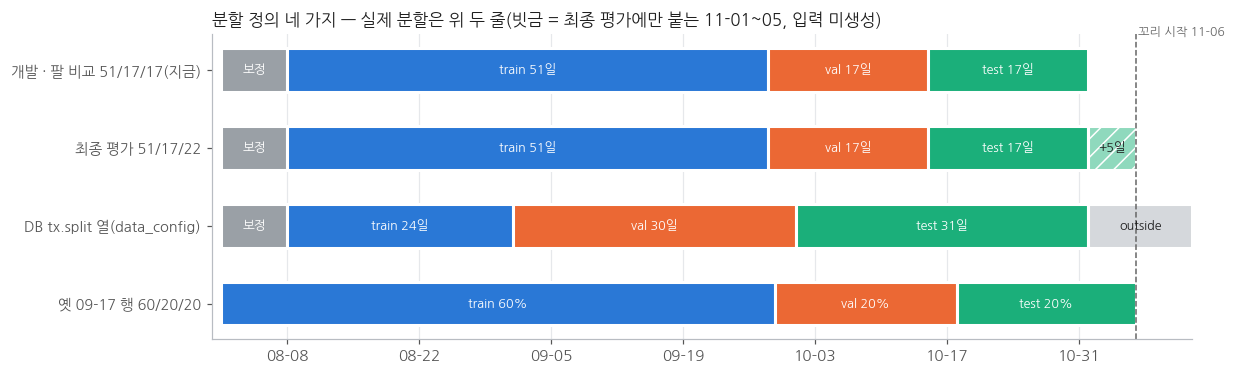

In [25]:
def seg(ax, yv, a, b, color, text=None, hatch=None):
    a, b = pd.Timestamp(a), pd.Timestamp(b)
    ax.barh(yv, (b - a) / pd.Timedelta(days=1), left=mdates.date2num(a), height=0.56, color=color, edgecolor='white', linewidth=2, hatch=hatch)
    if text: ax.text(mdates.date2num(a) + (b - a) / pd.Timedelta(days=2), yv, text, ha='center', va='center', fontsize=8.3, color='white' if color not in (LIGHT, '#8fd9bd') else INK)
cfgd = ds_meta['config']; END = '2022-11-12'
tr0, tr1 = L.SPLIT_DAYS['train']; va0, va1 = L.SPLIT_DAYS['val']; te0, te1 = L.SPLIT_DAYS['test']
nx = lambda d: str((pd.Timestamp(d) + pd.Timedelta(days=1)).date())
old_v, old_t = NA['split']['val_start'].replace('T', ' '), NA['split']['test_start'].replace('T', ' ')
fig, ax = plt.subplots(figsize=(11.5, 3.6))
rowsdef = ['옛 09-17 행 60/20/20', 'DB tx.split 열(data_config)', '최종 평가 51/17/22', '개발 · 팔 비교 51/17/17(지금)']
for yv, name in enumerate(rowsdef):
    if name.startswith('옛'):
        seg(ax, yv, '2022-08-01', old_v, SC['train'], 'train 60%'); seg(ax, yv, old_v, old_t, SC['val'], 'val 20%'); seg(ax, yv, old_t, '2022-11-06', SC['test'], 'test 20%')
    elif name.startswith('DB'):
        seg(ax, yv, cfgd['calibration_start'], cfgd['train_start'], GRAY, '보정'); seg(ax, yv, cfgd['train_start'], cfgd['val_start'], SC['train'], 'train 24일')
        seg(ax, yv, cfgd['val_start'], cfgd['test_start'], SC['val'], 'val 30일'); seg(ax, yv, cfgd['test_start'], cfgd['test_end'], SC['test'], 'test 31일')
        seg(ax, yv, cfgd['test_end'], END, LIGHT, 'outside')
    else:
        seg(ax, yv, cfgd['calibration_start'], tr0, GRAY, '보정'); seg(ax, yv, tr0, nx(tr1), SC['train'], 'train 51일'); seg(ax, yv, va0, nx(va1), SC['val'], 'val 17일')
        seg(ax, yv, te0, nx(te1), SC['test'], 'test 17일')
        if name.startswith('최종'): seg(ax, yv, '2022-11-01', '2022-11-06', '#8fd9bd', '+5일', hatch='//')
ax.set_yticks(range(len(rowsdef))); ax.set_yticklabels(rowsdef, fontsize=9.5); ax.grid(axis='y', visible=False)
ax.xaxis_date(); ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.set_xlim(mdates.date2num(pd.Timestamp('2022-07-31')), mdates.date2num(pd.Timestamp(END)))
ax.axvline(mdates.date2num(pd.Timestamp('2022-11-06')), color=MUTED, lw=1, ls='--'); ax.text(mdates.date2num(pd.Timestamp('2022-11-06')) + 0.3, 3.45, '꼬리 시작 11-06', fontsize=8, color=MUTED)
ax.set_title('분할 정의 네 가지 — 실제 분할은 위 두 줄(빗금 = 최종 평가에만 붙는 11-01~05, 입력 미생성)', fontsize=11, loc='left', color=INK)
savefig(fig, 'F03_분할_타임라인.png')

---
## ⑦ 라벨 병합 — 9클래스(09-29): 패턴 밖 세탁 → 클래스 8

- **규칙**: 패턴 8종은 0~7, 정상과 패턴 밖 세탁은 **8**. 10번째 클래스는 만들지 않는다(09-29 09:1x 사용자 확인).
  - 09-22~28 에는 패턴 밖 세탁을 학습 · 평가에서 **뺐다**(−1). 09-29 에 08-30 팀 결정(병합, 팀장 `message.txt` 72줄)으로 돌아갔다.
  - **팀 확인 필요**: 08-30 뒤에 나온 **09-01 팀 기록**("패턴 밖 고립 세탁은 학습 · 평가 범위에서 제외, 정상으로 재라벨 안 함", `세션상태_손은총_20260922.md` 133줄)과 부딪친다.
    09-29 결정 기록은 08-30 과 09-22 만 언급하고 09-01 기록과의 관계는 적지 않았다. 어느 것이 마지막 팀 결정인지 기록만으로는 알 수 없으니 다섯 명이 함께 확인해야 한다(부록 A).
  - 캐시의 `y9.npy` 는 옛 규칙(−1)으로 저장돼 있다. **학습 · 채점 때** `merge_labels` 로 패턴 밖만 8 로 바꾼다. 모집단 밖(−1)은 그대로 뺀다.
- **학습 행**: 패턴 전부 + CSSMC 정상 + **train 패턴 밖 43,095행 전부(가중치 1)**. CSSMC 는 진짜 정상만 골랐으므로 따로 넣는다.
- **평가 행**: 병합이면 모집단 전부(val 33,649,784 · test 30,407,864). 병합에서 `세탁여부_AP` 는 "패턴 세탁 여부"다(패턴 밖은 음성).
  - 제거판(33,633,093 · 30,390,801)과 macro-AP 를 직접 비교하지 않는다 → 바닥대비 · 조건부 8종으로 비교한다.
- **클래스 순서**: 내부는 `[FAN-OUT, FAN-IN, CYCLE, SCATTER-GATHER, GATHER-SCATTER, BIPARTITE, STACK, RANDOM, 정상]`.
  API(팀장 message.txt 74줄)는 0 NORMAL · 1 FAN-OUT · 2 FAN-IN · 3 G-SCATTER · 4 S-GATHER · 5 CYCLE · 6 RANDOM · 7 BIPARTITE · 8 STACK.
  내보낼 때만 `P_api = P[:, [8,0,1,4,3,2,7,5,6]]`(G-SCATTER = GATHER-SCATTER 로 봄 — **팀 확인 필요**).

In [26]:
def label_rule_table():
    """확인용: 가능한 라벨 조합을 옛 규칙(y9_of)과 병합 규칙(merge_labels)에 그대로 넣어 본다(아래 두 함수는 원본 글자 그대로)."""
    Y9_RAW = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 8, -1], np.int8)       # 행 = 원본 행 번호 0~10 이라고 친다
    IP_RAW = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 0, -1], np.int8)
    y9_raw, ip_raw = Y9_RAW, IP_RAW
    FIX = dict(label_merge=True)
    # ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py:175-178 · 스위치 안으로 들여씀 · 글자 그대로
    def y9_of(eid):
        """0~7 패턴 · 8 정상 · −1 = 뺄 행(패턴 밖 세탁, 내 모집단 밖). tree_gnn_9class.py:323-327 과 같음(사용자 결정 09-22)."""
        y9, ip = y9_raw[eid], ip_raw[eid]
        return np.where(y9 < 0, -1, np.where(y9 < 8, y9, np.where(ip == 1, -1, 8))).astype(np.int8)
    # ▲ 원본 끝(build_nb_A.py:175-178)
    # ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py:424-433 · 스위치 안으로 들여씀 · 글자 그대로
    PO_RAW = (Y9_RAW == 8) & (IP_RAW == 1)                               # 패턴 밖 세탁(원본 행 번호) — 캐시 y9.npy 에서는 −1(뺌)
    def merge_labels(tid, y, fx=None):
        """라벨 병합(`label_merge`, 09-29 사용자 결정 · 08-30 팀 결정): 패턴 밖 세탁을 정상 클래스(8 = API 의 0 NORMAL)로. 끄면 원본(−1 = 뺌)."""
        fx = fx or FIX
        if not fx['label_merge']:
            return y
        po = PO_RAW[tid]
        assert np.all(y[po] == -1), '패턴 밖 세탁인데 캐시 라벨이 −1 이 아니다'
        y = np.array(y, copy=True); y[po] = 8
        return y
    # ▲ 원본 끝(build_nb_fix.py:424-433)
    eid = np.arange(len(Y9_RAW)); y_old = y9_of(eid); y_new = merge_labels(eid, y_old)
    kind = [L.CLASS_NAMES[i] + ' 패턴' for i in range(8)] + ['패턴 밖 세탁', '정상', '모집단 밖(가짜 중복 등)']
    return pd.DataFrame(dict(경우=kind, index_y9=Y9_RAW, is_pos=IP_RAW, 캐시_y9_제거판_0922=y_old, 학습채점_병합판_0929=y_new))
show(label_rule_table(), '라벨 규칙표 — −1 은 학습 · 채점에서 빠지는 행')
show_src('/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py', 441, 448, '학습 행: 패턴 + CSSMC 정상 + (병합이면) 패턴 밖 전부')
show_src('/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py', 144, 150, 'LightGBM 병합 평가 행 = 원시 파일 + 패턴 밖 행(정상 클래스)')
show_src('/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py', 73, 73, 'API 순서로 내보낼 때만 — 팀 확인 필요')

**라벨 규칙표 — −1 은 학습 · 채점에서 빠지는 행**

,경우,index_y9,is_pos,캐시_y9_제거판_0922,학습채점_병합판_0929
0,FAN-OUT 패턴,0,1,0,0
1,FAN-IN 패턴,1,1,1,1
2,CYCLE 패턴,2,1,2,2
3,SCATTER-GATHER 패턴,3,1,3,3
4,GATHER-SCATTER 패턴,4,1,4,4
5,BIPARTITE 패턴,5,1,5,5
6,STACK 패턴,6,1,6,6
7,RANDOM 패턴,7,1,7,7
8,패턴 밖 세탁,8,1,-1,8
9,정상,8,0,8,8


── /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py:441-448 · 학습 행: 패턴 + CSSMC 정상 + (병합이면) 패턴 밖 전부
  441  def train_positions_ids(tid, y):
  442      """학습 대상(edge_id 순서): 패턴 세탁 전부 + CSSMC 로 고른 정상 — 원본 §8 train_positions 와 같음.
  443      병합이면 패턴 밖 세탁(정상 클래스, 가중치 1)을 전부 더한다(CSSMC 는 진짜 정상만 골랐으므로 따로 넣는다. train 43,095행)."""
  444      q = np.minimum(np.searchsorted(CS, tid), len(CS) - 1)
  445      keep = ((y >= 0) & (y < 8)) | ((CS[q] == tid) & (y == 8))
  446      if FIX['label_merge']:
  447          keep |= PO_RAW[tid] & (y == 8)
  448      return np.flatnonzero(keep)

── /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py:144-150 · LightGBM 병합 평가 행 = 원시 파일 + 패턴 밖 행(정상 클래스)
  144  # 병합 평가 행 = 원시 파일(패턴 밖 뺀 행) 뒤에 패턴 밖 행을 붙인 순서. 패턴 밖은 정상 클래스(8)
  145  NM = {sp: N[sp] + NOUT[sp] for sp in ('val', 'test')}
  146  YM = {sp: np.concatenate([Y[sp], np.full(NOUT[sp], 8, np.int8)]) for sp in ('val', 'test')}
  147  POM = {sp: np.con

읽음: /workspace/Final_preprocess/EDA_현황_20260929/results/E1b_분할별_사전확률.csv


**분할별 클래스 행 수 — 병합 전/후(EDA 현황 E1b · 개발 분할 51/17/17)**

,클래스,train,val,test
0,FAN-OUT,"5,423","2,323","2,571"
1,FAN-IN,"5,718","2,385","2,323"
2,CYCLE,"5,402","2,129","2,250"
3,SCATTER-GATHER,"11,214","4,668","4,726"
4,GATHER-SCATTER,"7,689","4,592","4,637"
5,BIPARTITE,"5,869","2,047","2,216"
6,STACK,"10,089","4,408","4,151"
7,RANDOM,"4,433","1,728","1,629"
8,"8 병합 전(정상만, 패턴 밖은 뺌)","91,327,582","33,608,813","30,366,298"
9,패턴 밖 세탁,"43,095","16,691","17,063"


평가 행 — 제거판(kept): {'val': 33633093, 'test': 30390801} · 병합판(joined_rows): {'val': 33649784, 'test': 30407864}
학습 행 — 제거판 16,806,937 · 병합판 16,850,032
읽음: /workspace/Final_preprocess/fix_20260927/results/D2_라벨수_전후대조.csv


**참고 — 11-01~05 를 포함한 기간별 라벨 수(fix D2, 옛 라벨판 = 지금 라벨)**

,기간,모집단_행,정상,패턴_세탁,패턴밖_세탁
0,0_보정(08-01~08-07),"14,932,226","14,925,020","1,795","5,411"
1,1_train(08-08~09-27),"91,426,514","91,327,582","55,837","43,095"
2,2_val(09-28~10-14),"33,649,784","33,608,813","24,280","16,691"
3,3_test17(10-15~10-31),"30,407,864","30,366,298","24,503","17,063"
4,4_되살린5일(11-01~11-05),"9,234,293","9,221,695","7,248","5,350"
5,5_꼬리(11-06~),0,0,0,0


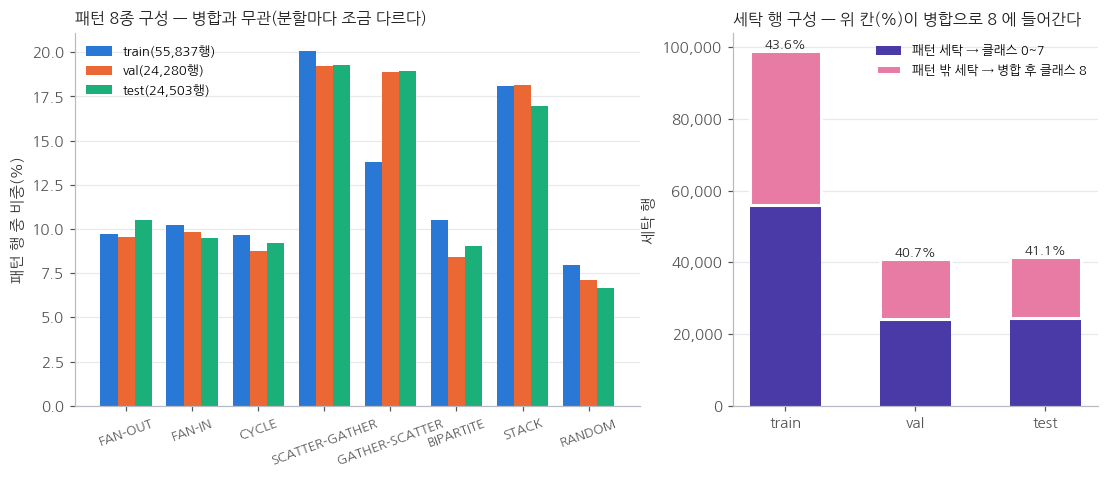

In [27]:
E1B = rd(EDA_NOW / 'results/E1b_분할별_사전확률.csv').set_index('분할')
TY = L.CLASS_NAMES[:8]
CD = pd.DataFrame({sp: {**{t: int(E1B.loc[sp, t]) for t in TY}, '8 병합 전(정상만, 패턴 밖은 뺌)': int(E1B.loc[sp, '정상']),
                        '패턴 밖 세탁': int(E1B.loc[sp, '패턴밖세탁']), '8 병합 후(정상 + 패턴 밖)': int(E1B.loc[sp, '정상'] + E1B.loc[sp, '패턴밖세탁'])}
                   for sp in ('train', 'val', 'test')})
show(CD.reset_index().rename(columns={'index': '클래스'}), '분할별 클래스 행 수 — 병합 전/후(EDA 현황 E1b · 개발 분할 51/17/17)')
_c = {r['split']: r for r in C36['by_split']}
for sp in ('train', 'val', 'test'):
    assert int(E1B.loc[sp, '정상'] + E1B.loc[sp, '패턴밖세탁'] + E1B.loc[sp, '패턴']) == _c[sp]['joined_rows']
    assert int(E1B.loc[sp, '정상'] + E1B.loc[sp, '패턴']) == _c[sp]['kept']
print('평가 행 — 제거판(kept):', {s: _c[s]['kept'] for s in ('val', 'test')}, '· 병합판(joined_rows):', {s: _c[s]['joined_rows'] for s in ('val', 'test')})
print('학습 행 — 제거판', f"{C36['train_rows_cssmc_r300']:,}", '· 병합판', f"{n_tr_rows:,}")
D2L = rd(FIXD / 'results/D2_라벨수_전후대조.csv'); D2L = D2L[D2L['라벨판'] == '0_옛(고치기 전)']
show(D2L[['기간', '모집단_행', '정상', '패턴_세탁', '패턴밖_세탁']], '참고 — 11-01~05 를 포함한 기간별 라벨 수(fix D2, 옛 라벨판 = 지금 라벨)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw=dict(width_ratios=[1.55, 1]))
ax = axes[0]; w = 0.26; x = np.arange(8)
for i, sp in enumerate(('train', 'val', 'test')):
    share = np.array([E1B.loc[sp, t] for t in TY], float); share = share / share.sum() * 100
    ax.bar(x + (i - 1) * w, share, width=w, color=SC[sp], label=f'{sp}({int(E1B.loc[sp, "패턴"]):,}행)')
ax.set_xticks(x); ax.set_xticklabels(TY, fontsize=8.5, rotation=20); ax.set_ylabel('패턴 행 중 비중(%)'); ax.legend(fontsize=8.5, frameon=False)
ax.set_title('패턴 8종 구성 — 병합과 무관(분할마다 조금 다르다)', fontsize=10.5, loc='left', color=INK); ax.grid(axis='x', visible=False)
ax = axes[1]; xs = np.arange(3)
pt = np.array([E1B.loc[s, '패턴'] for s in ('train', 'val', 'test')]); po = np.array([E1B.loc[s, '패턴밖세탁'] for s in ('train', 'val', 'test')])
ax.bar(xs, pt, color='#4a3aa7', width=0.55, label='패턴 세탁 → 클래스 0~7')
ax.bar(xs, po, bottom=pt, color='#e87ba4', width=0.55, label='패턴 밖 세탁 → 병합 후 클래스 8', edgecolor='white', linewidth=2)
for xi, a, b in zip(xs, pt, po): ax.text(xi, a + b, f'{b / (a + b) * 100:.1f}%', ha='center', va='bottom', fontsize=8.5, color=INK)
ax.set_xticks(xs); ax.set_xticklabels(['train', 'val', 'test']); ax.set_ylabel('세탁 행'); ax.legend(fontsize=8.3, frameon=False, loc='upper right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.set_title('세탁 행 구성 — 위 칸(%)이 병합으로 8 에 들어간다', fontsize=10.5, loc='left', color=INK); ax.grid(axis='x', visible=False)
savefig(fig, 'F04_분할별_클래스분포_병합전후.png')

---
## ⑧ CSSMC r300 언더샘플링 — train 정상에서 패턴 수의 300배를 결정적으로 고른다

**왜**: train 정상 91,327,582행을 다 쓰면 학습이 너무 무겁다. 행을 고를 때 분포가 뒤틀리지 않게, 군집 층화 후보 중 **모집단 분포와 가장 가까운(KL 최소)** 것을 고른다.

| 단계 | 설정(`us_lib.py` 38-52 CFG) |
|---|---|
| 모집단 | 09-21 결합 파일 train 정상(패턴 밖 · 모집단 밖 제외) 91,327,582행 · 패턴 55,837 |
| 적합 표본 | train 정상을 시간순 **매 91번째**(1,003,600행) |
| k-means | 전배치(lloyd, n_init 1), 초기 중심 = 표본의 일정 간격 K행. k 격자 64/256/1024 → **K = 1024**(inertia/row ≤ 최적 × 1.1 인 최소 K). k=1024 는 100회에서 미수렴 |
| 몫 | 군집 크기 비례 floor + 남는 몫은 큰 군집부터(`us_lib.py` 132-138) |
| CSSMC 후보 | 군집 안 시간순 일정 간격, 시작 오프셋 j/20(`us_lib.py` 153-163) · 후보 20벌 |
| 채택 | 54열 히스토그램 KL(P_모집단 ‖ Q) 평균이 가장 작은 후보(nbin 32 · 라플라스 0.5). **무작위 없음**(사용자 09-22 Q1) |
| 결과 | `indices/cssmc_r300.npy` — 정상 edge_id 16,751,100개(= 300 × 55,837), 정렬, sha1 c237ac91… |

- **다시 만들 수 없는 유일본**이다. k-means 가 비트 단위로 재현되지 않는다. 그래서 무거운 스위치도 두지 않았다.
- 가중치 w300: 패턴 300 · 정상 1 → 유효 세탁 비중 약 50%.
- 09-24 F05 정정: "km 이 경계 정상을 버린다"는 **철회**했다. 실제로는 열 안 분포 모양을 뒤튼 것이다.
- 고친 모집단(정정안)으로 다시 고르면 옛 선택과 18.34% 만 겹친다(fix T4). 재선택은 적용하지 않았다.

In [28]:
show_src('/workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/code/us_lib.py', 38, 52)
show_src('/workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/code/us_lib.py', 132, 163)
show_src('/workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/code/us_step5_select.py', 26, 33, 'KL 계산')
show_src('/workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/code/us_step5_select.py', 55, 70, '방식 × r 선택 · CSSMC 는 후보 20벌 중 KL 최소')

── /workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/code/us_lib.py:38-52
   38  CFG = dict(
   39      fit_step=(5 if SMOKE else 91),               # 적합 표본 = train 정상 행을 시간순 매 fit_step 번째. 임의 — 예전 fit_subsample 100만(prep9/undersample.py:31)과 같은 크기가 되게 91,327,582/91 ≈ 1,003,600
   40      k_grid=((4, 8) if SMOKE else (64, 256, 1024)),   # 기존 코드 값 make_cluster_indices.py:53 (팀 결정 아님)
   41      k_rule_tol=1.10,                             # "최적 inertia/row 대비 10% 이내 최소 K" make_cluster_indices.py:74
   42      kmeans_max_iter=100, kmeans_tol=1e-4,        # max_iter 100 = prep9/undersample.py:41 · tol = sklearn 기본값. 전배치 KMeans(lloyd, n_init 1): MiniBatch 대신(무작위 없음)
   43      nbin=32, laplace=0.5, n_cand=(3 if SMOKE else 20),   # CSSMC KL 계산·후보 수 — 논문에 없어 make_cluster_indices.py 에서 임의로 정했던 값 그대로
   44      ratios=((2, 5) if SMOKE else (10, 30, 100, 300)),   # 사용자 결정 Q4(09-22)
   45      clara_samples=5, clara_extra=40,             # CLARA 표본 5회 × (40+2K)행 — Kaufman & Rousseeuw(1990

In [29]:
# 확인용: 유일본의 지문 · 크기 · 정렬, 그리고 train 51일 결합 파일(저장본)과 날짜별 대조
CSSMC_F = US / 'indices/cssmc_r300.npy'
assert sha1(CSSMC_F) == CSSMC_SHA1, 'cssmc_r300.npy 지문이 09-28 기록과 다르다'
CS = np.load(CSSMC_F); assert len(CS) == 16_751_100 and bool(np.all(CS[1:] > CS[:-1]))
D3 = rd(US / 'results/D3_일별_행수.csv'); d3 = D3[(D3['방식'] == 'cssmc') & (D3['r'] == 300)].set_index('day')
rows = []
for d in L.days_of('train'):
    t = pq.read_table(SAVED_JD / f'day={d}.parquet', columns=['edge_id', 'y9', 'is_pos'])
    e, y9, ip = t.column('edge_id').to_numpy(), t.column('y9').to_numpy(), t.column('is_pos').to_numpy(); del t
    q = np.minimum(np.searchsorted(CS, e), len(CS) - 1); m = CS[q] == e              # build_nb_A.py:228 과 같은 방식
    normal = (y9 == 8) & (ip == 0)
    rows.append(dict(day=d, 정상=int(normal.sum()), CSSMC=int(m.sum()), CSSMC_중_정상아님=int((m & ~normal).sum()),
                     D3_모집단_정상=int(d3.loc[d, '모집단_정상']), D3_남긴_정상=int(d3.loc[d, '남긴_정상']), 캐시_cssmc_hits=int(C36L.loc[d, 'cssmc_hits'])))
CK = pd.DataFrame(rows)
assert (CK['CSSMC'] == CK['D3_남긴_정상']).all() and (CK['CSSMC'] == CK['캐시_cssmc_hits']).all() and (CK['정상'] == CK['D3_모집단_정상']).all()
assert CK['CSSMC_중_정상아님'].sum() == 0 and CK['CSSMC'].sum() == len(CS)
print(f"sha1 같음 · {len(CS):,}개 정렬 · train 51일 저장본에서 전부 찾음 · 전부 정상 · 날짜별 수가 D3 · 캐시 기록과 같음")
print(f"날짜별 보존율 {(CK['CSSMC'] / CK['정상']).min():.4f} ~ {(CK['CSSMC'] / CK['정상']).max():.4f}")
print({k: rj(US / f'common/{k}.json')[f] for k, f in (('step2_meta', 'n_fit'), ('kmeans_meta', 'k'), ('step7_meta', 'ref_interval'))})
show(rd(US / 'results/K1_kmeans_스윕.csv'), 'k-means k 격자(K1)')
D1U = rd(US / 'results/D1_분포왜곡_요약.csv')
show(D1U[['방식', 'r', '남긴_정상', '보존율', 'KL_평균', 'KL_최대열', 'KL_최대', '일별_보존율_최소', '일별_보존율_최대', '선택']], '분포 왜곡(D1) — KL 작을수록 모집단과 가깝다')
del CS; _ = gc.collect()

읽음: /workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/results/D3_일별_행수.csv


sha1 같음 · 16,751,100개 정렬 · train 51일 저장본에서 전부 찾음 · 전부 정상 · 날짜별 수가 D3 · 캐시 기록과 같음
날짜별 보존율 0.1834 ~ 0.1835
읽음: /workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/common/step2_meta.json
읽음: /workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/common/kmeans_meta.json
읽음: /workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/common/step7_meta.json
{'step2_meta': 1003600, 'kmeans_meta': 1024, 'step7_meta': 456}
읽음: /workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/results/K1_kmeans_스윕.csv


**k-means k 격자(K1)**

,k,inertia,inertia_per_row,n_iter,converged,empty_clusters,size_min,size_max,sec
0,64,"21,251,048",21.174819,49,True,0,508,"34,212",5.1
1,256,"14,586,921",14.534596,83,True,0,21,"10,934",25.9
2,"1,024","10,088,687",10.052498,100,False,0,7,"3,459",117.9


읽음: /workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/results/D1_분포왜곡_요약.csv


**분포 왜곡(D1) — KL 작을수록 모집단과 가깝다**

,방식,r,남긴_정상,보존율,KL_평균,KL_최대열,KL_최대,일별_보존율_최소,일별_보존율_최대,선택
0,km,10,"558,370",0.006114,6.300918e-02,pair_age_at_day_start,3.287113e-01,0.001256,0.015176,중심 근접 순서(center_frac 1.0)
1,clara,10,"558,370",0.006114,1.268414e-02,dst_log_self_count,5.533629e-02,0.004102,0.008577,medoid 근접 순서(center_frac 1.0)
2,cssmc,10,"558,370",0.006114,7.858067e-06,dst_log_in_count,2.929012e-05,0.006012,0.006298,후보 20벌 중 KL 최소(후보 18)
3,km,30,"1,675,110",0.018342,4.892677e-02,pair_age_at_day_start,2.315376e-01,0.005431,0.039735,중심 근접 순서(center_frac 1.0)
4,clara,30,"1,675,110",0.018342,1.255763e-02,dst_log_self_count,5.686362e-02,0.011970,0.025114,medoid 근접 순서(center_frac 1.0)
5,cssmc,30,"1,675,110",0.018342,2.380590e-06,src_log_entity_out_diversity,9.305295e-06,0.018267,0.018451,후보 20벌 중 KL 최소(후보 15)
6,km,100,"5,583,700",0.061139,3.358501e-02,pair_age_at_day_start,1.357093e-01,0.024806,0.110034,중심 근접 순서(center_frac 1.0)
7,clara,100,"5,583,700",0.061139,1.133247e-02,dst_log_self_count,5.071658e-02,0.039718,0.079959,medoid 근접 순서(center_frac 1.0)
8,cssmc,100,"5,583,700",0.061139,6.271250e-07,dst_log_in_count,2.768740e-06,0.061103,0.061183,후보 20벌 중 KL 최소(후보 12)
9,km,300,"16,751,100",0.183418,1.939010e-02,dst_log_self_count,7.870291e-02,0.097378,0.270894,중심 근접 순서(center_frac 1.0)


읽음: /workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/results/T11_팔별_지표.csv


읽음: /workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/results/D4_cssmc_후보.csv


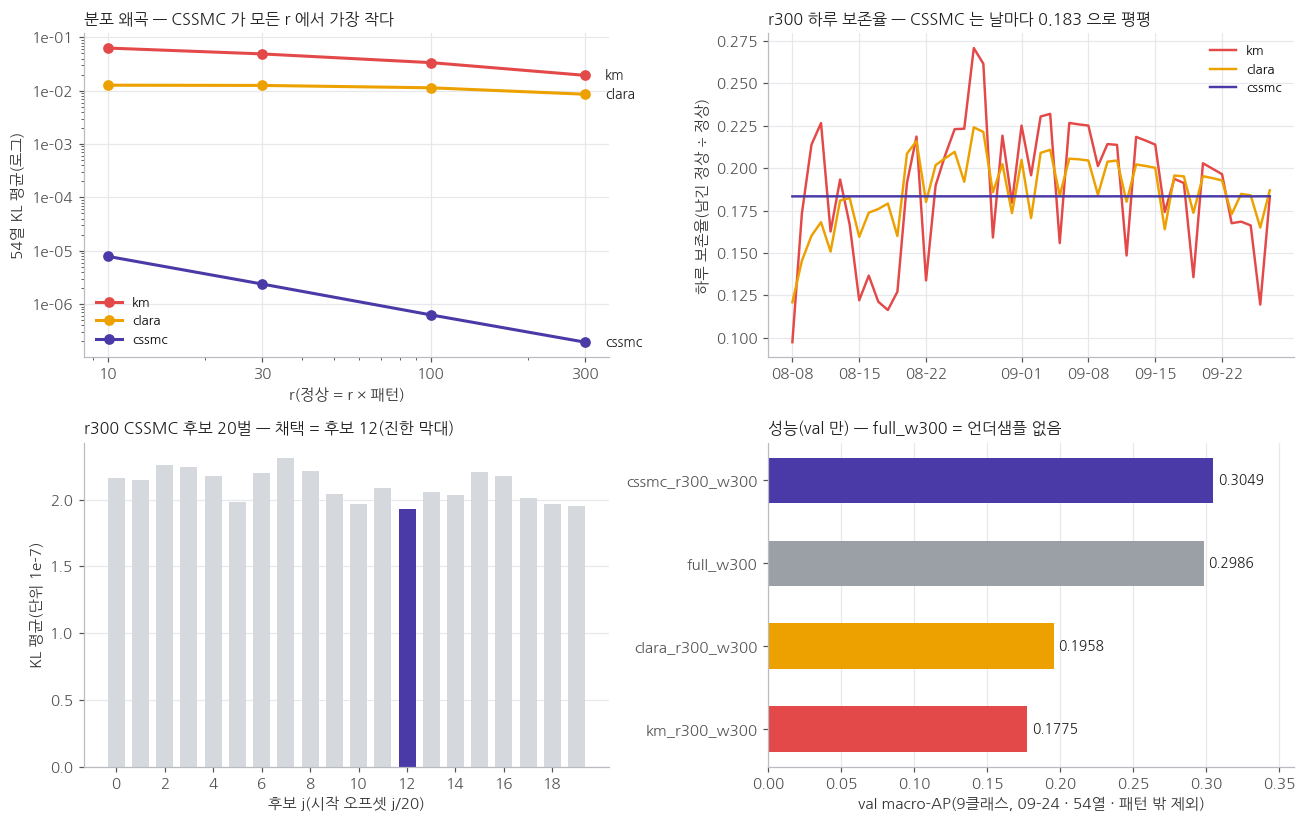

**r300 · w300 팔과 언더샘플 없음(T11, val 만)**

,팔,학습_행,선택_round,macro_AP_9,세탁여부_AP,macro_F1_argmax_9
44,km_r300_w300,"16,806,937",29,0.1775,0.6714,0.1934
10,clara_r300_w300,"16,806,937",79,0.1958,0.8970,0.2174
32,full_w300,"91,383,419",179,0.2986,0.9276,0.3344
26,cssmc_r300_w300,"16,806,937",299,0.3049,0.9678,0.3357


In [30]:
T11 = rd(US / 'results/T11_팔별_지표.csv'); T11v = T11[T11['split'] == 'val']      # 팔 비교는 val 만
D4 = rd(US / 'results/D4_cssmc_후보.csv')
fig, axes = plt.subplots(2, 2, figsize=(12, 7.6))
ax = axes[0, 0]
for m in ('km', 'clara', 'cssmc'):
    s = D1U[D1U['방식'] == m].sort_values('r'); ax.plot(s['r'], s['KL_평균'], marker='o', color=MC[m], label=m)
    ax.text(s['r'].iloc[-1] * 1.15, s['KL_평균'].iloc[-1], m, color=INK, fontsize=9, va='center')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xticks([10, 30, 100, 300]); ax.set_xticklabels(['10', '30', '100', '300'])
ax.xaxis.set_minor_formatter(mticker.NullFormatter()); ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0e}'))
ax.set_xlabel('r(정상 = r × 패턴)'); ax.set_ylabel('54열 KL 평균(로그)'); ax.legend(fontsize=8.5, frameon=False)
ax.set_title('분포 왜곡 — CSSMC 가 모든 r 에서 가장 작다', fontsize=10.5, loc='left', color=INK)
ax = axes[0, 1]
d3all = D3[D3['r'] == 300].copy(); d3all['d'] = pd.to_datetime(d3all['day'])
for m in ('km', 'clara', 'cssmc'):
    s = d3all[d3all['방식'] == m]; ax.plot(s['d'], s['보존율'], color=MC[m], lw=1.6, label=m)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d')); ax.set_ylabel('하루 보존율(남긴 정상 ÷ 정상)'); ax.legend(fontsize=8.5, frameon=False)
ax.set_title('r300 하루 보존율 — CSSMC 는 날마다 0.183 으로 평평', fontsize=10.5, loc='left', color=INK)
ax = axes[1, 0]
s = D4[D4['r'] == 300].sort_values('후보')
ax.bar(s['후보'], s['KL'] * 1e7, color=[MC['cssmc'] if c else LIGHT for c in s['채택']], width=0.7)
ax.set_xlabel('후보 j(시작 오프셋 j/20)'); ax.set_ylabel('KL 평균(단위 1e-7)'); ax.grid(axis='x', visible=False); ax.set_xticks(range(0, 20, 2))
ax.set_title(f"r300 CSSMC 후보 20벌 — 채택 = 후보 {int(s.loc[s['채택'], '후보'].iloc[0])}(진한 막대)", fontsize=10.5, loc='left', color=INK)
ax = axes[1, 1]
sel = T11v[(T11v['r'] == 300) & (T11v['가중치'] == 'w300')].copy(); sel = pd.concat([sel, T11v[T11v['팔'] == 'full_w300']])
sel = sel.sort_values('macro_AP_9')
ax.barh(sel['팔'], sel['macro_AP_9'], color=[MC.get(m, GRAY) for m in sel['방식']], height=0.55)
for yi, v in enumerate(sel['macro_AP_9']): ax.text(v + 0.003, yi, f'{v:.4f}', va='center', fontsize=9, color=INK)
ax.set_xlabel('val macro-AP(9클래스, 09-24 · 54열 · 패턴 밖 제외)'); ax.set_xlim(0, 0.36); ax.grid(axis='y', visible=False)
ax.set_title('성능(val 만) — full_w300 = 언더샘플 없음', fontsize=10.5, loc='left', color=INK)
fig.tight_layout(); savefig(fig, 'F07_CSSMC_vs_km_clara.png')
show(sel[['팔', '학습_행', '선택_round', 'macro_AP_9', '세탁여부_AP', 'macro_F1_argmax_9']].round(4), 'r300 · w300 팔과 언더샘플 없음(T11, val 만)')

---
## ⑨ TGNN 하루 캐시 — 받은 문맥(10건 상한) · 나가는 문맥(revmp)

### (a) 받은 문맥 캐시 `gnn36_full/day=*/`(노트북 A §3-§5)
- 태훈님 `load_day` 를 `inspect.getsource` 로 읽고 대상 확인 줄 뒤에 **한 줄**(`_CTX_IDS[0]=context.edge_id`)만 덧붙여 실행한다.
  파일을 고치면 `require_stage` 의 sha 검사에 걸리기 때문이다. 첫날은 원래 `load_day` 와 배열 10개가 전부 같은지 확인한다.
- 하루 그래프: 노드 = 30일 창 [D−29, D] 에 활동한 계좌(노드 19열) · 문맥 = 계좌마다 **받은 거래 최근 10건**(`ts DESC, edge_id DESC`) · 대상 = D일 거래 전부.
- 날마다 저장: `node_ids · node_x · context_src/dst/x/ids · target_ids/src/dst/x · labels(태훈님 y) · y9` + `_DONE`.
- 멈춤 조건: 태훈님 y ≠ 내 라벨 · amt_z NaN · **결합 파일과 엣지 16 · 노드 19 차이 > 1e−4**(85일 모두 0.0) · CSSMC 행이 정상 아님 · /tmp 여유 < 15 GiB · anon 18.5 GiB.

### (b) 나가는 문맥 캐시 `gnn36_out/day=*/`(수정판 `FIX_RUN_OUT_CACHE`)
- 같은 30일 창에서 계좌마다 **보낸 거래 최근 10건**(`PARTITION BY src`). DuckDB memory_limit 10GB.
- 대조: 같은 거래의 17열이 받은 쪽 캐시와 비트 단위로 같아야 한다 · 첫날은 같은 조회로 만든 받은 쪽 문맥이 원본 캐시와 edge_id 까지 같아야 한다.
- 양방향 샘플러 `BiNeighborSampler`: 받은 쪽 + 보낸 쪽 2홉. 두 목록에 다 있는 거래는 받은 쪽 것만 쓴다.

### (c) 하루 안 배치 순서(`_m` 팔) — 학습과 **채점 둘 다** 섞는다
- **학습**: 시드 셔플 `default_rng(SEED + epoch + dayofyear).permutation` — 태훈님 `daily_pipeline.py` 545줄과 같은 식(09-29 사용자 승인, 무작위 금지의 예외).
- **채점(val · test)**: `_m` 팔은 채점도 `default_rng([SEED, 7919, dayofyear])` 로 섞은 **4,096건 배치**로 하고, 점수는 원래 행 순서로 되돌린다(`split_scores`, `build_nb_fix.py` 473-485).
  - 양방향 샘플러(revmp)와 ego 는 **점수가 배치 구성에 따라 달라진다**(받은 목록 · 보낸 목록이 따로 잘림). 그래서 시간순 배치로 채점하면 09-30 복구 연쇄의 revmp_m 채점과 다른 점수가 나온다.
  - 받은 쪽만 보는 샘플러(shuffle_m)는 점수가 배치와 무관해 섞어도 결과가 같다(`build_nb_fix.py` 62-65).
  - 지금 채점 중인 revmp_m 의 설정은 끝 셀에서 `ep8.pt` 의 meta 로 확인한다(shuffle · reverse_mp · 노트북 지문).
- 셔플 전에는 CSSMC 배치의 29% 가 세탁 0건이었다(`results/D2_배치구성_요약.csv`).

### (d) 지금 상태(09-30)
- 85일 캐시(101.3 GiB)와 나가는 문맥은 09-30 01:40 · 04:07 컨테이너 재생성으로 **모두 사라졌다**.
- 복구 연쇄는 **val · test 34일만** 다시 만든다(`_fix/recover_20260930/make_patched.py` — 날짜 목록 · 로그 위치 · 완료 표시 이름만 바꾼 사본).
  - 01:46 첫 복구: /tmp 여유 149 GiB 가 85일 캐시(약 177 GiB)에 모자라서 val · test 만 골랐다(`make_patched.py` 1-2줄).
  - 04:12 재시작: /tmp 는 266 GB 였지만 **사용자가 val · test 34일만으로 정했다**(세션상태 09-30 208줄).
- **train 51일은 다시 만들 계획이 아직 없다 — 재생성 시점은 사용자 결정 대기**(09-30 05:50 기준 /tmp 여유 209 GB 로 자리는 충분, 세션상태 09-30 235줄).
  revmp_ego_m · FraudGT 팔의 전제다: 받은 문맥 train 51일(60.2 GiB) + reverse_mp 를 쓰는 팔(revmp_ego_m · `fgt_rmp_ego_m` · `fgt_multi_m`)은 나가는 문맥 train 51일도(크기 · 시간은 아래 기록 셀).

In [31]:
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py:164-172 · 글자 그대로
import inspect
_SRC = inspect.getsource(dp.load_day)
_ANCHOR = "        if targets.empty:raise ValueError(f'No target transactions on {day.date()}')\n"
_DEF = 'def load_day(cfg,day,with_labels=False):'
assert _SRC.count(_ANCHOR) == 1 and _SRC.count(_DEF) == 1
dp.__dict__['_CTX_IDS'] = [None]
exec(compile(_SRC.replace(_DEF, 'def _load_day_ctx(cfg,day,with_labels=False):', 1)
                 .replace(_ANCHOR, _ANCHOR + '        _CTX_IDS[0]=context.edge_id.to_numpy(np.int64)\n', 1),
             '<daily_pipeline.load_day + 문맥 edge_id>', 'exec'), dp.__dict__)
# ▲ 원본 끝(build_nb_A.py:164-172)
_orig = inspect.getsource(dp.load_day)
_new = _orig.replace(_DEF, 'def _load_day_ctx(cfg,day,with_labels=False):', 1).replace(_ANCHOR, _ANCHOR + '        _CTX_IDS[0]=context.edge_id.to_numpy(np.int64)\n', 1)
_added = [l for l in _new.splitlines() if l not in _orig.splitlines() and '_load_day_ctx' not in l]
print('원래 load_day 대비 덧붙인 줄:', _added, '· dp._load_day_ctx 준비됨:', callable(dp._load_day_ctx))
show_src('/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py', 392, 397, '받은 문맥 10건 · 대상 = 그날 거래 전부')
show_src('/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py', 210, 217, '캐시: 36피처로 고르고 amt_z 를 붙인다')
show_src('/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py', 218, 224, '캐시: 결합 파일과 날마다 대조')
show_src('/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py', 406, 434, '받은 쪽 2홉 샘플러')
show_src('/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py', 283, 297, '나가는 문맥 조회')
show_src('/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py', 355, 370, '양방향 샘플러 batch')
show_src('/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py', 255, 258, '하루 안 학습 순서(시드 셔플)')
show_src('/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py', 473, 485, '채점도 섞은 배치로(_m 팔) — 순서 시드 [SEED, 7919, dayofyear], 점수는 원래 행 순서로 되돌림')
show_src('/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py', 545, 545, '태훈님 원본의 같은 시드 식')

원래 load_day 대비 덧붙인 줄: ['        _CTX_IDS[0]=context.edge_id.to_numpy(np.int64)'] · dp._load_day_ctx 준비됨: True
── /workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py:392-397 · 받은 문맥 10건 · 대상 = 그날 거래 전부
  392          context=c.execute(f'''SELECT edge_id,src,dst,{names} FROM hist
  393            QUALIFY row_number() OVER(PARTITION BY dst ORDER BY ts DESC,edge_id DESC)<={cfg.incoming_neighbors}
  394            ORDER BY dst,ts DESC,edge_id DESC''').fetchdf()
  395          targets=c.execute(f'''SELECT f.edge_id,f.src,f.dst,{','.join('f.'+x for x in EDGE_FEATURES)}
  396            {',t.y' if with_labels else ''} FROM features f {'JOIN tx t USING(edge_id)' if with_labels else ''}
  397            WHERE f.day={sql_string(str(day.date()))}::DATE ORDER BY f.edge_id''').fetchdf()

── /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py:210-217 · 캐시: 36피처로 고르고 amt_z 를 붙인다
  210          day = dp._load_day_ctx(cfg, D, with_labels=True)

**무거운 셀 — `RUN_CACHE36` · `RUN_OUT_CACHE`**(노트북 A §3-§5 · 수정판 [B] 를 옮김). 새 폴더 `/tmp/prep_integrated_20260930/gnn36_full` · `gnn36_out` 에 만들고 하루 기록은 `out/common/` 에 쓴다.
`PREP_CACHE_SPLITS=val,test` 로 분할을 고를 수 있다(09-30 복구와 같은 선택). DB 가 먼저 있어야 한다(원본 행 라벨은 없으면 스스로 만든다).
- 부분 실행이면 하루 기록을 분할별 파일(`out/common/cache36_log_valtest.csv` 처럼)에 쓰고, 나가는 문맥의 완료 표시도 `_VALTEST_DONE` 처럼 붙인다(09-30 복구 사본 `make_patched.py` 30줄과 같은 규칙). 부분 완료를 전체 완료(`_ALL_DONE`)로 오해하지 않기 위해서다.
- 먼저 일부 분할을 만들고 뒤에 전체를 돌리면, 이미 만든 날은 건너뛰고 앞선 기록 파일을 합쳐 날짜 순으로 대조한다(이 노트북 추가).
- 행 수 대조는 복구 스크립트(`run_recover_revmp_m.sh` 18-26)와 같다. 고른 분할의 날만 09-28 기록과 비교한다.

In [32]:
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py:169-173 · 글자 그대로
def status_fix(t):
    line = f'[{time.strftime("%F %T")} UTC] [FIX:{RUN_NAME}{"/smoke" if SMOKE else ""}] {t}'
    (OUT / 'STATUS.txt').write_text(line + '\n')
    with open(W / 'STATUS_log.txt', 'a') as f: f.write(line + '\n')
    print(line, flush=True)
# ▲ 원본 끝(build_nb_fix.py:169-173)
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py:283-297 · 글자 그대로
def load_out_context(cfg, day, direction='out'):
    """보낸 거래 최근 10건(direction='out') 또는 받은 거래 최근 10건(direction='in', 원본과 대조용). 원본 load_day 의 hist 창과 같은 기간."""
    require_stage(cfg, 'features'); day = pd.Timestamp(day).normalize(); start = day - pd.Timedelta(days=cfg.history_days - 1)
    from dataclasses import replace as _dc_replace
    c = connect(_dc_replace(cfg, memory_limit='10GB'), read_only=True)   # 14GB 로는 노트북 A 가 mem_guard 19.14 에 0.1 GiB 까지 갔다(09-28) — 10GB 에서 값 같음(09-27 기록)
    try:
        c.execute(f"""CREATE TEMP VIEW hist AS SELECT f.* FROM features f
           WHERE f.day>={sql_string(str(start.date()))}::DATE AND f.day<={sql_string(str(day.date()))}::DATE""")
        key = 'src' if direction == 'out' else 'dst'
        names = ','.join(EDGE_FEATURES)
        return c.execute(f"""SELECT edge_id,src,dst,{names} FROM hist
          QUALIFY row_number() OVER(PARTITION BY {key} ORDER BY ts DESC,edge_id DESC)<={cfg.incoming_neighbors}
          ORDER BY {key},ts DESC,edge_id DESC""").fetchdf()
    finally:
        c.close()
# ▲ 원본 끝(build_nb_fix.py:283-297)
RUN_NAME, SMOKE = 'out_cache', False                              # status_fix 가 쓰는 이름(수정판 §1-수정과 같은 값)
require_stage, connect, sql_string, EDGE_FEATURES = dp.require_stage, dp.connect, dp.sql_string, dp.EDGE_FEATURES   # 수정판은 이 이름을 전역에 둔다
if RUN_CACHE36:
    if 'y9_raw' not in globals(): y9_raw, ip_raw = L.label_arrays()
    # ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py:180-187 · 스위치 안으로 들여씀 · 글자 그대로
    d0 = DAYS['train'][0]
    if not (FC / f'day={d0}' / '_DONE').exists():
        status(f'스모크 대조 {d0} (원래 load_day 와 비교)'); t = time.time()
        a = dp.load_day(cfg, d0, with_labels=True); b = dp._load_day_ctx(cfg, d0, with_labels=True)
        for f in ('node_ids', 'node_x', 'context_src', 'context_dst', 'context_x', 'target_ids', 'target_src', 'target_dst', 'target_x', 'labels'):
            assert np.array_equal(getattr(a, f), getattr(b, f)), f'{f} 가 다르다'
        assert len(dp._CTX_IDS[0]) == len(b.context_src)
        print(f'{d0}: 원래 load_day 와 배열 10개 전부 같음 · 문맥 {len(b.context_src):,} · {time.time()-t:.0f}초'); del a, b; gc.collect()
    # ▲ 원본 끝(build_nb_A.py:180-187)
    # ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py:194-245 · 스위치 안으로 들여씀 · 바꾼 곳: LOGF = COMMON / 'cache36_log.csv' → LOGF = COMMON / f'cache36_log{SPLIT_TAG}.csv'   # 이 노트북: 부분 실행이면 분할별 기록 파일
    ESEL = np.array(EDGE_IDX); NSEL = np.array(NODE_IDX)
    J_E = [L.F62.index(f) for f in EDGE17[:16]]
    J_S = [L.F62.index('src_' + L.NAME_FIX.get(f, f)) for f in NODE19]
    J_D = [L.F62.index('dst_' + L.NAME_FIX.get(f, f)) for f in NODE19]
    CS = np.load(CSSMC); assert len(CS) == 16_751_100 and np.all(np.diff(CS) > 0)
    FC.mkdir(parents=True, exist_ok=True)
    LOGF = COMMON / f'cache36_log{SPLIT_TAG}.csv'   # 이 노트북: 부분 실행이면 분할별 기록 파일
    done_rows = pd.read_csv(LOGF).to_dict('records') if LOGF.exists() else []
    guard = L.AnonGuard(18.5, marker=W / 'ANON_GUARD.txt').start()
    try:
        for i, D in enumerate(ALL_DAYS):
            dd = FC / f'day={D}'
            if (dd / '_DONE').exists(): continue
            assert L.free_gib('/tmp') > 15, '/tmp 여유 15 GiB 미만 — 멈춤'
            if dd.exists(): shutil.rmtree(dd)
            dd.mkdir(); t0 = time.time()
            day = dp._load_day_ctx(cfg, D, with_labels=True); ctx = dp._CTX_IDS[0]; tl = time.time() - t0
            y = y9_of(day.target_ids); ok = y >= 0
            assert (day.labels[ok & (y < 8)] == 1).all() and (day.labels[y == 8] == 0).all(), '태훈님 y 와 내 라벨 불일치'
            az_c, az_t = np.asarray(AZ[ctx]), np.asarray(AZ[day.target_ids])
            assert np.isfinite(az_c).all() and np.isfinite(az_t).all(), 'amt_z NaN'
            nx = np.ascontiguousarray(day.node_x[:, NSEL])
            cx = np.concatenate([day.context_x[:, ESEL], az_c[:, None]], 1).astype(np.float32)
            tx = np.concatenate([day.target_x[:, ESEL], az_t[:, None]], 1).astype(np.float32)
            # 09-21 결합 파일과 대조(결합 파일 = 내 모집단 행만, edge_id 순서)
            X, _, _, _, eid = L.read_day(JD, D)
            p = np.searchsorted(day.target_ids, eid); assert (day.target_ids[p] == eid).all(), '결합 파일 행이 캐시에 없다'
            de = float(np.abs(tx[p, :16] - X[:, J_E]).max())
            si = np.searchsorted(day.node_ids, day.target_src[p]); di = np.searchsorted(day.node_ids, day.target_dst[p])
            dn = float(max(np.abs(nx[si] - X[:, J_S]).max(), np.abs(nx[di] - X[:, J_D]).max()))
            assert de <= 1e-4 and dn <= 1e-4, f'{D}: 결합 파일과 값이 다르다(엣지 {de}, 노드 {dn})'
            n_join = len(eid); del X, eid
            hit = 0
            if D in DAYS['train']:
                q = np.searchsorted(CS, day.target_ids); q = np.minimum(q, len(CS) - 1); m = CS[q] == day.target_ids
                assert (y[m] == 8).all(), 'CSSMC 행이 정상이 아니다'; hit = int(m.sum())
            for f, v in dict(node_ids=day.node_ids, node_x=nx, context_src=day.context_src, context_dst=day.context_dst, context_x=cx,
                             context_ids=ctx, target_ids=day.target_ids, target_src=day.target_src, target_dst=day.target_dst,
                             target_x=tx, labels=day.labels, y9=y).items():
                np.save(dd / f'{f}.npy', v)
            (dd / '_DONE').write_text(D)
            rec = dict(day=D, split=[s for s in DAYS if D in DAYS[s]][0], load_sec=round(tl, 1), total_sec=round(time.time() - t0, 1),
                       targets=len(y), kept=int(ok.sum()), pattern=int(((y >= 0) & (y < 8)).sum()), excluded=int((~ok).sum()),
                       joined_rows=n_join, nodes=len(day.node_ids), context=len(ctx), edge16_maxdiff=de, node19_maxdiff=dn, cssmc_hits=hit,
                       mb=round(sum(x.stat().st_size for x in dd.iterdir()) / 2**20), free_tmp_gib=round(L.free_gib('/tmp'), 1),
                       anon_peak=round(guard.peak_anon, 1))
            done_rows.append(rec); pd.DataFrame(done_rows).to_csv(LOGF, index=False)
            status(f'CACHE36 {D} {i+1}/{len(ALL_DAYS)} · {rec["total_sec"]}초 · {rec["mb"]} MB · 차이 엣지 {de:.1e} 노드 {dn:.1e}')
            del day, nx, cx, tx, y, ctx; gc.collect()
    finally:
        guard.stop()
    # ▲ 원본 끝(build_nb_A.py:194-245)
    # 이 노트북 추가(노트북 A 에 없음): 앞선 실행(다른 PREP_CACHE_SPLITS)이 이미 만든 날(_DONE)은 건너뛰므로 그 기록을 합쳐 날짜 순으로 둔다
    _logs = pd.concat([pd.read_csv(p_) for p_ in sorted(COMMON.glob('cache36_log*.csv')) if p_ != LOGF] + [pd.read_csv(LOGF)])
    _logs = _logs[_logs['day'].isin(ALL_DAYS)].drop_duplicates('day', keep='last').set_index('day')
    assert set(_logs.index) == set(ALL_DAYS), f'기록이 없는 날: {sorted(set(ALL_DAYS) - set(_logs.index))[:5]}'
    _logs.loc[ALL_DAYS].reset_index().to_csv(LOGF, index=False)
    if len(ALL_DAYS) == 85:
        # ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py:248-261 · 스위치 안으로 들여씀 · 글자 그대로
        G = pd.read_csv(LOGF)
        assert len(G) == len(ALL_DAYS) and G['day'].tolist() == ALL_DAYS
        S = G.groupby('split')[['targets', 'kept', 'pattern', 'excluded', 'joined_rows', 'cssmc_hits']].sum().reindex(['train', 'val', 'test'])
        print(S.to_string())
        assert [int(S.loc[s, 'pattern']) for s in ('train', 'val', 'test')] == [L.EXPECT_POS[s] - EXCLUDED[s] for s in ('train', 'val', 'test')]
        assert int(S.loc['val', 'kept']) == KEPT_EXPECT['val'] and int(S.loc['test', 'kept']) == KEPT_EXPECT['test']
        assert int(S.loc['train', 'cssmc_hits']) == 16_751_100, 'CSSMC 행이 train 대상에 다 있지 않다'
        summary = dict(days=len(G), cache_gib=round(G['mb'].sum() / 1024, 1), hours=round(G['total_sec'].sum() / 3600, 2),
                       edge16_maxdiff=float(G['edge16_maxdiff'].max()), node19_maxdiff=float(G['node19_maxdiff'].max()),
                       train_rows_cssmc_r300=int(S.loc['train', 'pattern'] + S.loc['train', 'cssmc_hits']),
                       by_split=S.reset_index().to_dict('records'), anon_peak=float(G['anon_peak'].max()))
        (COMMON / 'cache36_summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=1, default=int))
        status(f'DONE A 준비 끝 · 캐시 {summary["cache_gib"]} GiB · {summary["hours"]}시간 · 결합 파일 최대 차이 엣지 {summary["edge16_maxdiff"]:.1e} 노드 {summary["node19_maxdiff"]:.1e}')
        print(json.dumps(summary, ensure_ascii=False, indent=1, default=int))
        # ▲ 원본 끝(build_nb_A.py:248-261)
    else:
        # ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_fix/recover_20260930/run_recover_revmp_m.sh:18-26 · 스위치 안으로 들여씀 · 바꾼 곳: .query("split!='train'") → .query('split in @CACHE_SPLITS') | f'{R}/cache36_log_valtest.csv' → LOGF | print('34일 행 수 전부 같음') → print(f'{len(b)}일 행 수 전부 같음')
        import pandas as pd
        R='/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_fix/recover_20260930'
        a=pd.read_csv(f'{R}/cache36_log_85일_원본백업.csv').query('split in @CACHE_SPLITS').set_index('day')
        b=pd.read_csv(LOGF).set_index('day')
        cols=['targets','kept','pattern','excluded','joined_rows','nodes','context']
        assert list(a.index)==list(b.index), '날짜 목록 다름'
        d=(a[cols]!=b[cols]).any(axis=1); assert not d.any(), f'다른 날 {list(d[d].index)}'
        assert b['edge16_maxdiff'].max()<=1e-4 and b['node19_maxdiff'].max()<=1e-4
        print(f'{len(b)}일 행 수 전부 같음')
        # ▲ 원본 끝(run_recover_revmp_m.sh:18-26)
else:
    print('RUN_CACHE36 꺼짐 — 캐시를 만들지 않는다')
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py:299-332 · 바꾼 곳:     ALL = DAYS['train'] + DAYS['val'] + DAYS['test'] →     ALL = ALL_DAYS   # 이 노트북: PREP_CACHE_SPLITS | COMMON_FIX / 'out_cache_log.csv' → COMMON_FIX / f'out_cache_log{SPLIT_TAG}.csv' | (FC_OUT / '_ALL_DONE') → (FC_OUT / DONE_MARK)
if RUN_OUT_CACHE:
    import shutil
    assert not heavy_jobs(), f'다른 무거운 작업이 돌고 있다 — 단독으로만 실행: {heavy_jobs()}'
    assert anon_gib() < 6, f'메모리 사용이 이미 크다(anon {anon_gib():.1f} GiB)'
    FC_OUT.mkdir(parents=True, exist_ok=True); rows = []
    ALL = ALL_DAYS   # 이 노트북: PREP_CACHE_SPLITS
    for i, d in enumerate(ALL):
        dd = FC_OUT / f'day={d}'
        if (dd / '_DONE').exists():
            continue
        a_ = anon_gib(); free_ = shutil.disk_usage('/tmp').free / 2**30
        assert a_ < 16, f'메모리 anon {a_:.1f} GiB ≥ 16 — 멈춤(날별 _DONE 이 있어 다시 돌리면 이어서 만든다)'
        assert free_ > 5, f'/tmp 여유 {free_:.1f} GiB ≤ 5 — 멈춤'
        dd.mkdir(exist_ok=True); t0 = time.time()
        o = load_out_context(cfg, d, 'out'); ids = o.edge_id.to_numpy(np.int64)
        az = np.asarray(AZ[ids]); assert np.isfinite(az).all(), 'amt_z NaN'
        ox = np.concatenate([o[EDGE_FEATURES].to_numpy(np.float32)[:, ESEL], az[:, None]], 1).astype(np.float32)
        osrc, odst = o.src.to_numpy(np.int64), o.dst.to_numpy(np.int64); del o
        assert np.all(osrc[:-1] <= osrc[1:]) and np.bincount(np.unique(osrc, return_inverse=True)[1]).max() <= cfg.incoming_neighbors
        cids = np.load(FC / f'day={d}' / 'context_ids.npy'); cx = np.load(FC / f'day={d}' / 'context_x.npy', mmap_mode='r')
        _, ia, ib = np.intersect1d(ids, cids, assume_unique=False, return_indices=True)
        assert np.array_equal(ox[ia], np.asarray(cx[ib])), f'{d}: 같은 거래의 17열 값이 원본 캐시와 다르다'
        if i == 0:                                                   # 첫날: 이 조회 방식의 "받은 거래" 문맥 = 원본 캐시
            chk = load_out_context(cfg, d, 'in')
            assert np.array_equal(chk.edge_id.to_numpy(np.int64), cids), f'{d}: 받은 쪽 문맥이 원본 캐시와 다르다'
            del chk
        for f_, v in dict(out_context_src=osrc, out_context_dst=odst, out_context_x=ox, out_context_ids=ids).items():
            np.save(dd / f'{f_}.npy', v)
        (dd / '_DONE').write_text(d)
        gc.collect(); rows.append(dict(day=d, out_edges=len(ids), overlap_with_in=len(ia), sec=round(time.time() - t0, 1), anon=round(anon_gib(), 1),
                                       tmp_free_gib=round(shutil.disk_usage('/tmp').free / 2**30, 1)))
        pd.DataFrame(rows).to_csv(COMMON_FIX / f'out_cache_log{SPLIT_TAG}.csv', index=False); status_fix(f'OUT_CACHE {d} {i+1}/{len(ALL)} · {rows[-1]}')
    if all((FC_OUT / f'day={d}' / '_DONE').exists() for d in ALL):
        (FC_OUT / DONE_MARK).write_text(time.strftime('%F %T')); status_fix('OUT_CACHE 끝')
# ▲ 원본 끝(build_nb_fix.py:299-332)
if not RUN_OUT_CACHE: print('RUN_OUT_CACHE 꺼짐 — 나가는 문맥 캐시를 만들지 않는다')

RUN_CACHE36 꺼짐 — 캐시를 만들지 않는다
RUN_OUT_CACHE 꺼짐 — 나가는 문맥 캐시를 만들지 않는다


In [33]:
# 기록: 받은 문맥 캐시(85일) · 나가는 문맥(85일) · 09-30 복구의 끊긴 판(33일)
show(pd.DataFrame(C36['by_split']), f"받은 문맥 캐시 합계(cache36_summary.json) — {C36['days']}일 · {C36['cache_gib']} GiB · {C36['hours']}시간 · 결합 파일 최대 차이 엣지 {C36['edge16_maxdiff']} 노드 {C36['node19_maxdiff']} · anon 피크 {C36['anon_peak']}")
C36D = C36L.reset_index(); C36D['d'] = pd.to_datetime(C36D['day'])
show(C36D.groupby('split', sort=False).agg(일수=('day', 'count'), GiB=('mb', lambda s: round(s.sum() / 1024, 1)), 시간=('total_sec', lambda s: round(s.sum() / 3600, 2)),
                                           하루_초_최소=('total_sec', 'min'), 하루_초_최대=('total_sec', 'max'), 노드_평균=('nodes', 'mean'), 문맥_평균=('context', 'mean')).round({'노드_평균': 0, '문맥_평균': 0}).reset_index(),
     '분할별 캐시 크기 · 시간(cache36_log.csv)')
OC = rd(TG / '_fix/common/out_cache_log.csv'); OC['d'] = pd.to_datetime(OC['day'])
print(f"나가는 문맥 85일: 거래 {OC['out_edges'].sum():,} · 받은 문맥과 겹침 {OC['overlap_with_in'].sum():,} · {OC['sec'].sum() / 60:.1f}분 · anon 최대 {OC['anon'].max()} GiB(크기는 로그에 없음, 세션상태 09-30 '65 GB')")
# train 51일 몫(revmp_ego_m · reverse_mp FraudGT 팔의 전제) — 크기는 로그에 없어 거래 수 비중으로 추정
_tr = OC['day'].isin(L.days_of('train')); _share = OC.loc[_tr, 'out_edges'].sum() / OC['out_edges'].sum()
print(f"  └ train 51일 몫: 거래 비중 {_share:.1%} → 약 {65 * _share:.0f} GB(65 GB × 비중, 추정) · {OC.loc[_tr, 'sec'].sum() / 60:.1f}분 · 받은 문맥 train 51일은 {C36L.loc[C36L['split'] == 'train', 'mb'].sum() / 1024:.1f} GiB")
print(f"  └ 실행 시점 /tmp 여유 {L.free_gib('/tmp'):.0f} GiB(참고: 09-30 05:50 기록 209 GB)")
# 확인용: 09-30 복구의 끊긴 판(04:07, 33일)이 09-28 기록과 행 수까지 같은가 — run_recover_revmp_m.sh 18-26 과 같은 대조를 끊긴 날까지만
bk = rd(TG / '_fix/recover_20260930/cache36_log_85일_원본백업.csv').set_index('day')
rc33 = rd(TG / '_fix/recover_20260930/cache36_log_valtest_중단_0407.csv').set_index('day')
cols = ['targets', 'kept', 'pattern', 'excluded', 'joined_rows', 'nodes', 'context']
assert (bk.loc[rc33.index, cols] == rc33[cols]).all().all() and rc33['edge16_maxdiff'].max() <= 1e-4 and rc33['node19_maxdiff'].max() <= 1e-4
assert (bk[cols] == C36L[cols]).all().all()
print(f'복구 ① 끊긴 판 {len(rc33)}일({rc33.index[0]}~{rc33.index[-1]}): 09-28 기록과 행 수 전부 같음 · 결합 파일 차이 0')
# 확인용: 지금 도는 복구 ②(04:12~)의 기록도 실행 시점까지 만든 날만 같은 대조(연쇄가 쓰는 중일 수 있어 읽기 실패는 건너뜀)
try:
    rcN = pd.read_csv(TG / '_fix/recover_20260930/cache36_log_valtest.csv').set_index('day'); print('읽음:', TG / '_fix/recover_20260930/cache36_log_valtest.csv')
    assert (bk.loc[rcN.index, cols] == rcN[cols]).all().all() and rcN['edge16_maxdiff'].max() <= 1e-4 and rcN['node19_maxdiff'].max() <= 1e-4
    print(f'복구 ② 실행 시점 {len(rcN)}/34일({rcN.index[0]}~{rcN.index[-1]}): 09-28 기록과 행 수 전부 같음 · 결합 파일 차이 0')
except (pd.errors.ParserError, pd.errors.EmptyDataError, FileNotFoundError) as _e:
    print('복구 ② 기록을 지금 읽을 수 없어 건너뜀:', type(_e).__name__)
show(rd(TG / 'results/E1_구조가_보는것_train.csv').round(3), '10건 상한이 보는 것(train, E1) — 받는 계좌가 10건 상한에 걸린 비율 등')
show(rd(TG / 'results/E2_이전거래없음_0채움_비율.csv').round(4), '이전 거래가 없어 0 으로 채운 비율(E2) — 패턴은 처음 쌍이 많다')
show(rd(TG / 'results/D2_배치구성_요약.csv').iloc[:, :8].round(3), '셔플 전 배치 구성(D2) — CSSMC 순서에서 배치 29% 가 패턴 0건')

**받은 문맥 캐시 합계(cache36_summary.json) — 85일 · 101.3 GiB · 3.89시간 · 결합 파일 최대 차이 엣지 0.0 노드 0.0 · anon 피크 17.6**

,split,targets,kept,pattern,excluded,joined_rows,cssmc_hits
0,train,"91,432,129","91,383,419","55,837","48,710","91,426,514","16,751,100"
1,val,"33,651,717","33,633,093","24,280","18,624","33,649,784",0
2,test,"30,409,636","30,390,801","24,503","18,835","30,407,864",0


**분할별 캐시 크기 · 시간(cache36_log.csv)**

,split,일수,GiB,시간,하루_초_최소,하루_초_최대,노드_평균,문맥_평균
0,train,51,60.2,2.21,83.1,196.3,"1,990,315","10,137,634"
1,val,17,20.7,0.84,164.6,197.8,"1,923,445","10,412,515"
2,test,17,20.4,0.84,166.0,188.9,"1,931,992","10,428,124"


읽음: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_fix/common/out_cache_log.csv
나가는 문맥 85일: 거래 748,330,218 · 받은 문맥과 겹침 544,397,820 · 47.2분 · anon 최대 5.4 GiB(크기는 로그에 없음, 세션상태 09-30 '65 GB')
  └ train 51일 몫: 거래 비중 58.8% → 약 38 GB(65 GB × 비중, 추정) · 27.4분 · 받은 문맥 train 51일은 60.2 GiB
  └ 실행 시점 /tmp 여유 169 GiB(참고: 09-30 05:50 기록 209 GB)
읽음: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_fix/recover_20260930/cache36_log_85일_원본백업.csv
읽음: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_fix/recover_20260930/cache36_log_valtest_중단_0407.csv
복구 ① 끊긴 판 33일(2022-09-28~2022-10-30): 09-28 기록과 행 수 전부 같음 · 결합 파일 차이 0
읽음: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_fix/recover_20260930/cache36_log_valtest.csv
복구 ② 실행 시점 34/34일(2022-09-28~2022-10-31): 09-28 기록과 행 수 전부 같음 · 결합 파일 차이 0
읽음: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/results/E1_구조가_보는것_train.csv


...

**이전 거래가 없어 0 으로 채운 비율(E2) — 패턴은 처음 쌍이 많다**

,열,패턴_값0_비율,정상(CSSMC)_값0_비율,패턴_0아닌_최소값,정상(CSSMC)_0아닌_최소값
0,pair_gap_minutes,0.8792,0.0310,1.0986,1.0986
1,sender_gap_minutes,0.0118,0.0008,1.0986,1.0986
2,receiver_gap_minutes,0.0194,0.0003,1.0986,1.0986
3,pair_age_at_day_start,0.8797,0.0311,1.0986,1.0986
4,pair_prior_count,0.8792,0.0310,0.6931,0.6931


읽음: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/results/D2_배치구성_요약.csv


**셔플 전 배치 구성(D2) — CSSMC 순서에서 배치 29% 가 패턴 0건**

,학습순서,배치수,패턴행,배치당_패턴_평균,중앙,패턴0_배치비율,가중비중_1퍼미만_배치비율,가중비중_90퍼초과_배치비율
0,cssmc,"4,128","55,837",13.526,1.0,0.290,0.290,0.012
1,full,"22,333","55,837",2.500,0.0,0.811,0.811,0.002


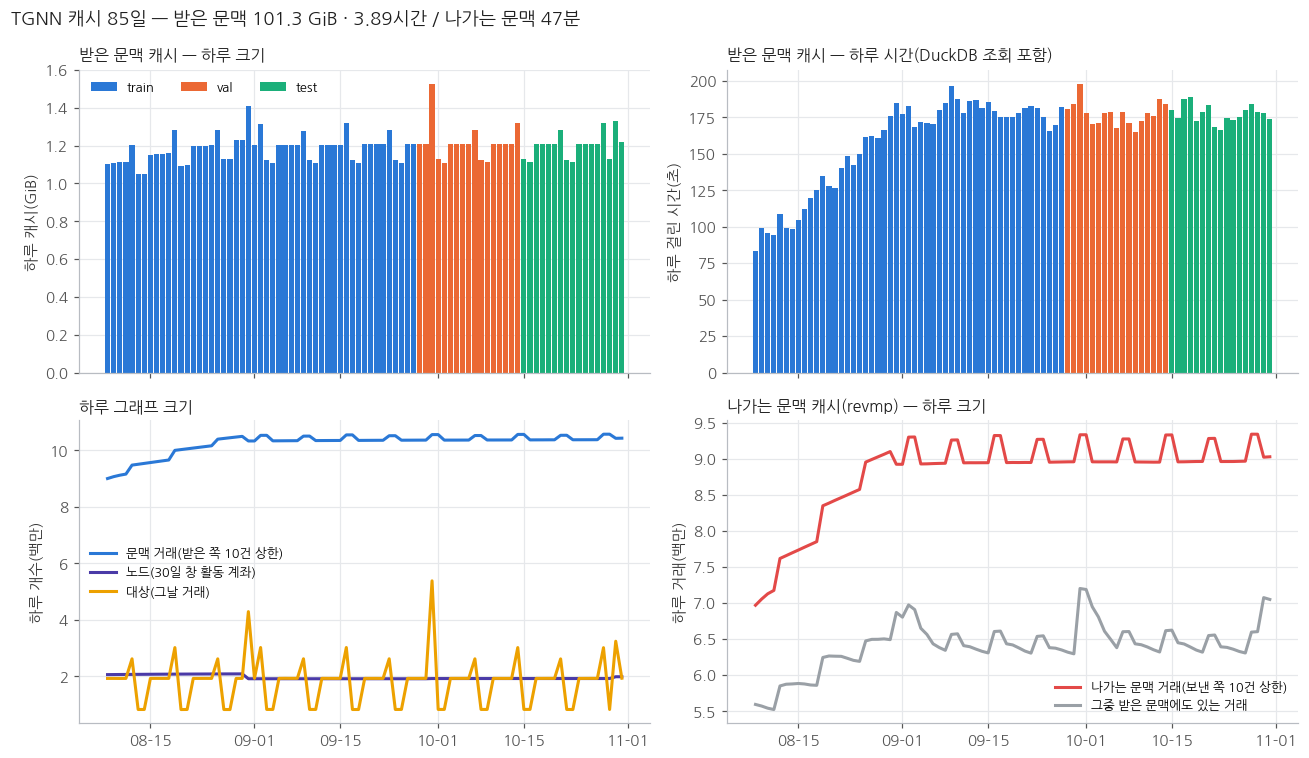

이 노트북을 실행한 시점의 복구 연쇄(STATUS_log 끝 4줄, 읽기만):
    [2026-09-30 06:59:38 UTC] [FIX:out_cache] OUT_CACHE 2022-10-17 20/34 · {'day': '2022-10-17', 'out_edges': 8959259, 'overlap_with_in': 6432779, 'sec': 42.7, 'ano
    [2026-09-30 07:00:17 UTC] [FIX:out_cache] OUT_CACHE 2022-10-18 21/34 · {'day': '2022-10-18', 'out_edges': 8961287, 'overlap_with_in': 6391691, 'sec': 38.5, 'ano
    [2026-09-30 07:01:01 UTC] [FIX:out_cache] OUT_CACHE 2022-10-19 22/34 · {'day': '2022-10-19', 'out_edges': 8963157, 'overlap_with_in': 6348234, 'sec': 44.3, 'ano
    [2026-09-30 07:01:39 UTC] [FIX:out_cache] OUT_CACHE 2022-10-20 23/34 · {'day': '2022-10-20', 'out_edges': 8963694, 'overlap_with_in': 6319222, 'sec': 37.8, 'ano


In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for sp, g in C36D.groupby('split', sort=False):
    axes[0, 0].bar(g['d'], g['mb'] / 1024, width=0.85, color=SC[sp], label=sp)
    axes[0, 1].bar(g['d'], g['total_sec'], width=0.85, color=SC[sp])
axes[0, 0].set_ylabel('하루 캐시(GiB)'); axes[0, 0].legend(fontsize=8.5, frameon=False, ncol=3)
axes[0, 0].set_title('받은 문맥 캐시 — 하루 크기', fontsize=10.5, loc='left', color=INK)
axes[0, 1].set_ylabel('하루 걸린 시간(초)'); axes[0, 1].set_title('받은 문맥 캐시 — 하루 시간(DuckDB 조회 포함)', fontsize=10.5, loc='left', color=INK)
ax = axes[1, 0]
ax.plot(C36D['d'], C36D['context'] / 1e6, color='#2a78d6', label='문맥 거래(받은 쪽 10건 상한)')
ax.plot(C36D['d'], C36D['nodes'] / 1e6, color='#4a3aa7', label='노드(30일 창 활동 계좌)')
ax.plot(C36D['d'], C36D['targets'] / 1e6, color='#eda100', label='대상(그날 거래)')
ax.set_ylabel('하루 개수(백만)'); ax.legend(fontsize=8.3, frameon=False, loc='center left'); ax.set_title('하루 그래프 크기', fontsize=10.5, loc='left', color=INK)
ax = axes[1, 1]
ax.plot(OC['d'], OC['out_edges'] / 1e6, color='#e34948', label='나가는 문맥 거래(보낸 쪽 10건 상한)')
ax.plot(OC['d'], OC['overlap_with_in'] / 1e6, color=GRAY, label='그중 받은 문맥에도 있는 거래')
ax.set_ylabel('하루 거래(백만)'); ax.legend(fontsize=8.3, frameon=False, loc='lower right'); ax.set_title('나가는 문맥 캐시(revmp) — 하루 크기', fontsize=10.5, loc='left', color=INK)
for a in axes[1]: a.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
fig.suptitle(f"TGNN 캐시 85일 — 받은 문맥 {C36['cache_gib']} GiB · {C36['hours']}시간 / 나가는 문맥 {OC['sec'].sum() / 60:.0f}분", fontsize=12, x=0.01, ha='left', color=INK)
fig.tight_layout(); savefig(fig, 'F05_캐시_하루별_크기_시간.png')
_sl = [l.rstrip() for l in open(TG / 'STATUS_log.txt', encoding='utf-8') if any(k in l for k in ('RECOVER', 'DUCKDB', 'CACHE36', 'OUT_CACHE', '[FIX:revmp_m'))][-4:]
print('이 노트북을 실행한 시점의 복구 연쇄(STATUS_log 끝 4줄, 읽기만):')
for l in _sl: print('   ', l[:160])

---
## ⑩ LightGBM 55열 입력 — 결합 파일 54열 + `amt_z_pay_ccy`

| 항목 | 내용 |
|---|---|
| 열 | `src_` 노드 19 + `dst_` 노드 19 + 엣지 16(스키마 순서, `NAME_FIX` 적용) = 54 · 끝에 `amt_z_pay_ccy` = **55** |
| 대조 | 앞 54열 · LightGBM 설정이 09-24 `cssmc_r300_w300`(`arms/cssmc_r300_w300/run.json`)과 같아야 한다 |
| `read55` | 결합 파일 하루 → 열 선택 → amt_z 를 `edge_id` 로 붙임 → 패턴 밖 행(−1)은 따로 |
| `read55m`(병합) | 모든 행 + 패턴 밖을 8 로 · 표시 |
| §1 val · test 원시 | `BIG/{val,test}_X55.f32` 등. 행 수 assert: val 33,633,093 · test 30,390,801, 패턴 밖 16,691 · 17,063 |
| §2 병합 학습 자료 | 패턴 55,837 + CSSMC 16,751,100 + 패턴 밖 43,095 = 16,850,032. 구간 경계 Xref = 패턴 밖 뺀 전체 학습 행에서 `arange(200,000) × (N_all // 200,000)`(간격 456) — 앞 54열이 09-22 `Xref.npy` 와 비트 단위로 같아야 한다 |
| 설정 | multiclass 9 · lr 0.1 · leaves 31 · depth 6 · max_bin 63 · threads 2 · seed 42 · deterministic · 행/열 무작위 끔 |

- **DuckDB · TGNN 캐시가 필요 없다.** 결합 파일 · amt_z · CSSMC · `us_cmp_20260922/common` 만 있으면 약 7분이다.
- 모델: `tgnn36_20260928/models/lgb55_cssmc_r300_w300/`(C, 병합 전). 병합판 CM 은 스모크만 했다. C 채점은 09-29 사용자 지시로 멈췄다.

In [35]:
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_C.py:48-48 · 글자 그대로
OLD = L.EDA / 'us_cmp_20260922'                           # 09-24 54열 결과
# ▲ 원본 끝(build_nb_C.py:48-48)
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_C.py:57-58 · 글자 그대로
LGB_P = dict(objective='multiclass', num_class=9, learning_rate=0.1, num_leaves=31, max_depth=6, max_bin=63, num_threads=2, seed=42,
             deterministic=True, force_col_wise=True, bagging_fraction=1.0, bagging_freq=0, feature_fraction=1.0, verbosity=-1)   # us_undersample_compare.py:141 과 같음
# ▲ 원본 끝(build_nb_C.py:57-58)
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_C.py:75-83 · 글자 그대로
SCH = pd.read_csv('/workspace/Final_preprocess/aml_feature_schema.csv', encoding='utf-8-sig')
_node = [L.NAME_FIX.get(f, f) for f in SCH.query("tensor=='node'").sort_values('col_index')['feature']]
_edge = list(SCH.query("tensor=='edge'").sort_values('col_index')['feature'])
F54 = ['src_' + f for f in _node] + ['dst_' + f for f in _node] + [f for f in _edge if f != 'amt_z_pay_ccy']
F55 = F54 + ['amt_z_pay_ccy']
IDX = np.array([L.F62.index(f) for f in F54])
OLD_RUN = json.loads((OLD / 'arms/cssmc_r300_w300/run.json').read_text())
assert F54 == OLD_RUN['settings']['features'], '앞 54열이 09-24 cssmc_r300_w300 과 다르다'
assert OLD_RUN['settings']['lgb_params'] == LGB_P, 'LightGBM 설정이 09-24 와 다르다'
# ▲ 원본 끝(build_nb_C.py:75-83)
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_C.py:89-93 · 글자 그대로
def to_y9(y9, ip, w):
    """노트북 25 와 같음: 0~7 패턴 · 8 정상 · −1 패턴 밖 세탁(뺄 행). 결합 파일 가중치(세탁 300 · 정상 1)도 확인."""
    assert not ((y9 < 8) & (ip != 1)).any()
    assert np.array_equal(w, np.where(ip == 1, 300.0, 1.0).astype(np.float32))
    return np.where(y9 < 8, y9, np.where(ip == 1, -1, 8)).astype(np.int8)
# ▲ 원본 끝(build_nb_C.py:89-93)
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_C.py:95-100 · 글자 그대로
def read55(d):
    """하루 → (패턴 밖 뺀 X55, y, edge_id, 패턴 밖 X55). 행 순서 = 결합 파일(edge_id) 순서."""
    X, y9, ip, w, eid = L.read_day(JD, d); y = to_y9(y9, ip, w); k = y >= 0
    az = np.asarray(AZ[eid]); assert np.isfinite(az).all(), f'{d}: amt_z NaN'
    X55 = np.empty((len(y), 55), np.float32); X55[:, :54] = X[:, IDX]; X55[:, 54] = az; del X
    return np.ascontiguousarray(X55[k]), y[k], eid[k], np.ascontiguousarray(X55[~k])
# ▲ 원본 끝(build_nb_C.py:95-100)
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py:111-116 · 글자 그대로
def read55m(d):
    """병합: 하루 → (모든 행 X55, y(패턴 밖 → 8), edge_id, 패턴 밖 표시). 행 순서 = 결합 파일(edge_id) 순서."""
    X, y9, ip, w, eid = L.read_day(JD, d); y = to_y9(y9, ip, w); po = y < 0; y = np.where(po, 8, y).astype(np.int8)
    az = np.asarray(AZ[eid]); assert np.isfinite(az).all(), f'{d}: amt_z NaN'
    X55 = np.empty((len(y), 55), np.float32); X55[:, :54] = X[:, IDX]; X55[:, 54] = az; del X
    return X55, y, eid, po
# ▲ 원본 끝(build_nb_CM.py:111-116)
print('55열:', len(F55), '· 앞 54열 = 09-24 run.json · LightGBM 설정 같음 · 마지막', F55[-1])

55열: 55 · 앞 54열 = 09-24 run.json · LightGBM 설정 같음 · 마지막 amt_z_pay_ccy


In [36]:
# 확인용: 실제 read55 · read55m 을 저장본 하루(val 첫날)의 표본에 그대로 돌린다
#   표본 = 앞 4,960행 + 그날 패턴 밖 세탁(y9 8 · is_pos 1) 40행(edge_id 순서 유지) — 병합 분기(패턴 밖 → 8)가 실제로 돌게 한다
#   표본 파일은 이 노트북 폴더의 _tmp_read55/ 에 잠깐 쓰고 끝나면 지운다
_d = L.days_of('val')[0]; _pf = pq.ParquetFile(SAVED_JD / f'day={_d}.parquet')
_lab = _pf.read(columns=['y9', 'is_pos']); _y9, _ip = _lab.column('y9').to_numpy(), _lab.column('is_pos').to_numpy(); del _lab
_po_all = np.flatnonzero((_y9 == 8) & (_ip == 1))
_pick = np.union1d(np.arange(4_960), _po_all[:40]); N_PO = int(np.isin(_pick, _po_all).sum())
_parts, _st = [], 0
for _bt in _pf.iter_batches(batch_size=65_536):                       # 한 번에 한 묶음만 메모리에
    _loc = _pick[(_pick >= _st) & (_pick < _st + _bt.num_rows)] - _st
    if len(_loc): _parts.append(pa.Table.from_batches([_bt]).take(pa.array(_loc)))
    _st += _bt.num_rows
_smp = pa.concat_tables(_parts); del _parts, _y9, _ip
assert _smp.num_rows == len(_pick) and N_PO > 0
_tmp = NBDIR / '_tmp_read55'; _tmp.mkdir(exist_ok=True)
try:
    pq.write_table(_smp, _tmp / f'day={_d}.parquet'); del _smp
    _jd_keep, JD = JD, _tmp
    try:
        X55, y, eid, Xo = read55(_d); X55m, ym, eidm, po = read55m(_d)
    finally:
        JD = _jd_keep
finally:
    shutil.rmtree(_tmp, ignore_errors=True)
assert X55.shape[1] == 55 and np.isfinite(X55).all() and np.isfinite(Xo).all() and len(y) + len(Xo) == len(ym) == len(_pick)
assert len(Xo) == N_PO and int(po.sum()) == len(Xo) > 0 and (ym[po] == 8).all()               # 패턴 밖이 실제로 있고, 병합에서 8 로 간다
assert np.array_equal(X55m[po], Xo) and np.array_equal(X55m[~po], X55) and np.array_equal(ym[~po], y)   # 병합판 = 제거판 + 패턴 밖(8)
print(f'표본 {_d}: 앞 4,960행 + 패턴 밖 세탁 {N_PO}행(그날 패턴 밖 {len(_po_all):,}행 중) = {len(_pick):,}행')
print(f'read55 → X {X55.shape} · 패턴 밖 따로 {len(Xo)}행 · 클래스 {np.bincount(y, minlength=9).tolist()}')
print(f'read55m → X {X55m.shape} · 패턴 밖 → 8 로 {int(po.sum())}행 · 클래스 {np.bincount(ym, minlength=9).tolist()} · 나머지 행 = read55 와 같음')
print(f'amt_z 열이 저장 배열과 같음: {bool(np.array_equal(X55m[:, 54], np.asarray(AZ[eidm])))} · 임시 폴더 지움: {not _tmp.exists()}')
display(pd.DataFrame(X55[:3], columns=F55).T.rename(columns=lambda i: f'행{i}').head(60))
del X55, X55m, Xo

표본 2022-09-28: 앞 4,960행 + 패턴 밖 세탁 40행(그날 패턴 밖 960행 중) = 5,000행
read55 → X (4960, 55) · 패턴 밖 따로 40행 · 클래스 [112, 135, 108, 237, 220, 93, 245, 99, 3711]
read55m → X (5000, 55) · 패턴 밖 → 8 로 40행 · 클래스 [112, 135, 108, 237, 220, 93, 245, 99, 3751] · 나머지 행 = read55 와 같음
amt_z 열이 저장 배열과 같음: True · 임시 폴더 지움: True


,행0,행1,행2
src_log_out_count,6.375025,6.375025,6.375025
src_log_in_count,5.342334,5.342334,5.342334
src_log_out_neighbors,3.178054,3.178054,3.178054
src_log_in_neighbors,1.791759,1.791759,1.791759
src_log_self_count,4.290460,4.290460,4.290460
src_log_reciprocal_neighbors,0.000000,0.000000,0.000000
src_mean_paid_currency_z,0.082830,0.082830,0.082830
src_paid_outlier_fraction,0.000000,0.000000,0.000000
src_log_currency_count,1.386294,1.386294,1.386294
src_log_active_days,3.433987,3.433987,3.433987


**무거운 셀 — `RUN_LGB55`**(노트북 CM §1 · §2 를 옮김, 학습 · 채점 없음). 새 폴더 `/tmp/prep_integrated_20260930/lgb55` 에 만든다. 결합 파일은 저장본을 읽기만 한다.

In [37]:
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py:49-49 · 글자 그대로
SMOKE = os.environ.get('LGB_SMOKE') == '1'               # 스모크: train 1일 · val·test 1일 · 상한 6 round
# ▲ 원본 끝(build_nb_CM.py:49-49)
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py:58-60 · 글자 그대로
CSSMC = OLD / 'indices/cssmc_r300.npy'; CSSMC_SHA1 = 'c237ac915b91069064eb1c29183ad2850dd31823'
K, CLASS9 = 9, L.CLASS_NAMES[:8] + ['정상']
DAYS = {s: L.days_of(s) for s in ('train', 'val', 'test')}
# ▲ 원본 끝(build_nb_CM.py:58-60)
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py:63-63 · 글자 그대로
CH = 500_000
# ▲ 원본 끝(build_nb_CM.py:63-63)
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py:65-65 · 글자 그대로
N_REF = 200_000                                           # LightGBM bin_construct_sample_cnt 기본값(us_lib CFG n_ref)
# ▲ 원본 끝(build_nb_CM.py:65-65)
# ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py:69-69 · 글자 그대로
EXCLUDED = {'train': 43_095, 'val': 16_691, 'test': 17_063}
# ▲ 원본 끝(build_nb_CM.py:69-69)
if RUN_LGB55:
    BIG.mkdir(parents=True, exist_ok=True)
    # ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py:71-75 · 스위치 안으로 들여씀 · 글자 그대로
    def status(t):
        line = f'[{time.strftime("%F %T")} UTC] {"[SMOKE] " if SMOKE else ""}LGB55M(병합) {t}'
        (W / 'STATUS.txt').write_text(line + '\n')
        with open(W / 'STATUS_log.txt', 'a') as f: f.write(line + '\n')
        print(line, flush=True)
    # ▲ 원본 끝(build_nb_CM.py:71-75)
    # ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py:126-156 · 스위치 안으로 들여씀 · 글자 그대로
    N, NOUT = {}, {}
    for sp in ('val', 'test'):
        fx, fy, fo = BIG / f'{sp}_X55.f32', BIG / f'{sp}_y9.npy', BIG / f'{sp}_out_X55.npy'
        if not (fx.exists() and fy.exists() and fo.exists()):
            status(f'원시 파일 {sp} 만들기'); ys, outs, n_nan = [], [], 0
            with open(fx, 'wb') as g:
                for d in DAYS[sp]:
                    X, y, _, Xo = read55(d); n_nan += int(np.isnan(X).sum()) + int(np.isnan(Xo).sum())
                    X.tofile(g); ys.append(y); outs.append(Xo); del X
            assert n_nan == 0, 'NaN 칸'
            np.save(fy, np.concatenate(ys)); np.save(fo, np.concatenate(outs)); L.drop_cache(fx)
        N[sp] = len(np.load(fy, mmap_mode='r')); NOUT[sp] = len(np.load(fo, mmap_mode='r'))
        assert fx.stat().st_size == N[sp] * 55 * 4
    print('val·test 행', N, '· 뺀 패턴 밖', NOUT)
    if not SMOKE:
        assert N == {'val': 33_633_093, 'test': 30_390_801} and NOUT == {'val': 16_691, 'test': 17_063}, '09-24 와 행 수가 다르다'
    Y = {sp: np.load(BIG / f'{sp}_y9.npy') for sp in ('val', 'test')}
    XOUT = {sp: np.load(BIG / f'{sp}_out_X55.npy') for sp in ('val', 'test')}
    # 병합 평가 행 = 원시 파일(패턴 밖 뺀 행) 뒤에 패턴 밖 행을 붙인 순서. 패턴 밖은 정상 클래스(8)
    NM = {sp: N[sp] + NOUT[sp] for sp in ('val', 'test')}
    YM = {sp: np.concatenate([Y[sp], np.full(NOUT[sp], 8, np.int8)]) for sp in ('val', 'test')}
    POM = {sp: np.concatenate([np.zeros(N[sp], bool), np.ones(NOUT[sp], bool)]) for sp in ('val', 'test')}
    print('병합 평가 행', NM)
    if not SMOKE:
        assert NM == {'val': 33_649_784, 'test': 30_407_864}, '병합 평가 행 수가 09-29 캐시 계산과 다르다'

    def iter_raw(split):
        with open(BIG / f'{split}_X55.f32', 'rb') as f:
            a = 0
            while a < N[split]:
                Xb = np.fromfile(f, np.float32, count=CH * 55).reshape(-1, 55); yield a, Xb; a += len(Xb)
    # ▲ 원본 끝(build_nb_CM.py:126-156)
    # ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py:162-193 · 스위치 안으로 들여씀 · 글자 그대로
    SD = BIG / 'subset_cssmc_r300_merged'; SD.mkdir(exist_ok=True)
    CS = np.load(CSSMC)
    n_pat_exp = 55_837 if not SMOKE else None
    if not (SD / 'DONE').exists():
        status('학습 자료 만들기'); t0 = time.time()
        dc = pd.read_csv(OLD / 'common/day_counts.csv')                            # 09-22 기록: 날짜별 남긴 행(rows_kept)
        N_all = int(dc['rows_kept'].sum()) if not SMOKE else None
        parts_X, parts_y, parts_e, ref_parts, start = [], [], [], [], 0
        fX = open(SD / 'X.f32', 'wb'); ys, es, ps_ = [], [], []
        if SMOKE:
            N_all = sum(len(read55(d)[1]) for d in DAYS['train'])
        want = np.arange(min(N_REF, N_all), dtype=np.int64) * (N_all // min(N_REF, N_all))
        for i, d in enumerate(DAYS['train']):
            X, y, e, po = read55m(d); n = int((~po).sum())
            if not SMOKE: assert n == int(dc['rows_kept'][i]) and dc['day'][i] == d, f'{d}: 남긴 행 수가 09-22 기록과 다르다'
            kk = np.flatnonzero(~po)                                      # Xref 위치는 C 와 같게 패턴 밖을 뺀 행에서
            loc = want[(want >= start) & (want < start + n)] - start; ref_parts.append(X[kk[loc]].copy()); start += n
            q = np.minimum(np.searchsorted(CS, e), len(CS) - 1); sel = (CS[q] == e)
            assert (y[sel] == 8).all() and not (sel & po).any()
            m = (y < 8) | sel | po                                        # 병합: 패턴 밖 세탁 전부(정상 클래스)
            X[m].tofile(fX); ys.append(y[m]); es.append(e[m]); ps_.append(po[m]); del X
        fX.close()
        Xref = np.concatenate(ref_parts); y_tr = np.concatenate(ys); e_tr = np.concatenate(es); po_tr = np.concatenate(ps_)
        assert start == N_all and len(Xref) == len(want)
        if not SMOKE:
            old_ref = np.load(OLD / 'common/Xref.npy')
            assert np.array_equal(Xref[:, :54], old_ref), 'Xref 앞 54열이 09-22 와 다르다 — 결합 파일이나 위치 규칙이 바뀌었다'
            assert int((y_tr < 8).sum()) == 55_837 and int((y_tr == 8).sum()) == 16_751_100 + EXCLUDED['train'] and int(po_tr.sum()) == EXCLUDED['train']
        np.save(SD / 'Xref55.npy', Xref); np.save(SD / 'y.npy', y_tr); np.save(SD / 'eid.npy', e_tr); np.save(SD / 'po.npy', po_tr)
        (SD / 'DONE').write_text(json.dumps(dict(rows=len(y_tr), n_all=N_all, sec=round(time.time() - t0, 1))))
        status(f'학습 자료 끝 {len(y_tr):,}행(패턴 밖 {int(po_tr.sum()):,} 포함) · Xref 앞 54열 09-22 와 같음 · {time.time()-t0:.0f}초')
    y_tr = np.load(SD / 'y.npy'); n_tr = len(y_tr)
    # ▲ 원본 끝(build_nb_CM.py:162-193)
    # ▼ 원본 /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py:195-195 · 스위치 안으로 들여씀 · 글자 그대로
    cnt_tr = np.bincount(y_tr, minlength=K); print('학습 행', n_tr, dict(zip(CLASS9, cnt_tr.tolist())))
    # ▲ 원본 끝(build_nb_CM.py:195-195)
else:
    print('RUN_LGB55 꺼짐 — LightGBM 입력 파일을 만들지 않는다')

RUN_LGB55 꺼짐 — LightGBM 입력 파일을 만들지 않는다


In [38]:
S7m = rj(US / 'common/step7_meta.json'); DC = rd(US / 'common/day_counts.csv')
print({k: S7m[k] for k in ('n_ref', 'ref_interval', 'n_train_all')}, '· 날짜별 남긴 행 합', f"{DC['rows_kept'].sum():,}")
assert S7m['n_train_all'] == DC['rows_kept'].sum() == C36['by_split'][0]['kept'] and S7m['n_train_all'] // S7m['n_ref'] == S7m['ref_interval']
_xr = np.load(US / 'common/Xref.npy', mmap_mode='r'); print('Xref.npy', _xr.shape, _xr.dtype); del _xr
MDL = TG / 'models/lgb55_cssmc_r300_w300'
print('C 모델 파일:', sorted(p.name for p in MDL.iterdir())); print('train_done.json:', rj(MDL / 'train_done.json'))

읽음: /workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/common/step7_meta.json
읽음: /workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/common/day_counts.csv
{'n_ref': 200000, 'ref_interval': 456, 'n_train_all': 91383419} · 날짜별 남긴 행 합 91,383,419
Xref.npy (200000, 54) float32
C 모델 파일: ['best_all.txt', 'best_le300.txt', 'ckpt_model.txt', 'final_model.txt', 'history.csv', 'state.json', 'train_done.json']
읽음: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/models/lgb55_cssmc_r300_w300/train_done.json
train_done.json: {'done': 360, 'best': 0.31145675917289406, 'best_r': 339, 'best300': 0.3084478885031609, 'best300_r': 299, 'since': 2, 'n_checks': 36, 'tr_acc': 4401.852095127106, 'trained': 360, 'stop_reason': 'patience(2회 연속 미개선)', 'dataset_sec': 22.8, 'anon_peak_gib': 12.72}


---
## 부록 A. 결정 기록 — 날짜 · 무엇 · 누가

결정은 다섯 명이 함께 한다. "사용자"는 손은총의 결정이고, 팀 확인이 필요한 것은 따로 적었다. 오른쪽 `줄` 은 이 노트북이 출처 파일에서 **찾을 문구**를 실행 중에 찾아 적은 줄 번호다.

In [39]:
S22, S29, S30 = Path('/workspace/세션상태_손은총_20260922.md'), Path('/workspace/세션상태_손은총_20260929.md'), Path('/workspace/세션상태_손은총_20260930.md')
MANI = FP / 'MANIFEST.txt'; EDAMD = EDA_NOW / 'EDA_진행현황_데이터형태_손은총_20260929.md'
DEC = [
    ('08-30', '패턴 밖 세탁 → "패턴아님"(정상 쪽) 병합', '팀(팀장 기록)', TG / 'message.txt', '08-30 팀 확정은 패턴 밖 세탁'),
    ('09-01', '패턴 밖 고립 세탁은 학습 · 평가에서 제외 · 정상으로 재라벨 안 함(08-30 병합과 부딪침 → 팀 확인 필요)', '팀 기록', S22, '팀 결정: 패턴 밖 고립 세탁은 학습·평가 범위에서 제외'),
    ('09-14', '41/43열 세트(결제 수단 fmt_ 등 제외) — 옛 81열 시절', '사용자', Path('/workspace/train9/data.py'), '2026-09-14 사용자 결정 41열'),
    ('09-17', '공식 원본 교체', '사용자', MANI, 'Kaggle 공식 원본 받기·md5 검증·교체'),
    ('09-17', 'HI-Small 쓰지 않음', '사용자', EDAMD, '09-17 부터는 쓰지 말라고 정했다(사용자 지시)'),
    ('09-21', '태훈님 40개 · 코드 그대로 실행 (2인 잠정, 팀 사후 확인 필요)', '사용자 · 태훈님', S22, '결정된 것 (2인 잠정 합의 · 팀 사후 확인 필요)'),
    ('09-21', '노드 = 거래일 D 일 마감(D−29~D)', '사용자 · 태훈님', S22, '노드 시간 기준 = 거래일 D 일 마감'),
    ('09-21', '분할 51/17/17(날짜) · 무작위 샘플링 금지', '사용자 · 태훈님', S22, '분할 = 태훈님 날짜 기준'),
    ('09-22', '9클래스 · 패턴 밖 제외(기록이 엇갈림: 사용자 결정 vs "팀 회의 결정")', '사용자(MANIFEST)', MANI, '패턴 밖 세탁은 학습·평가에서 제외'),
    ('09-22', '  └ 같은 결정을 "팀 회의 결정"으로 적은 곳', 'EDA 현황', EDAMD, '9클래스·패턴 밖 제외(**팀 회의 결정**)'),
    ('09-22', '언더샘플 비교 Q1~Q5(무작위 없는 변형 · r 10/30/100/300 · w300)', '사용자', MANI, '결정(사용자 09-22): Q1 무작위 없는 변형만'),
    ('09-23', '36피처(amt_z 추가) — docs 브랜치 명세', '태훈님 명세', Path('/workspace/money_laundry-context/GitHub.md'), '현재 정본 — 36개(노드 19 + 엣지 17)'),
    ('09-28', 'CSSMC r300 재사용', '사용자', S29, 'cssmc_r300.npy` 재사용'),
    ('09-28', '09-27 정정안 미적용', '사용자', S29, '09-27 정정안(11-05 연장 등)은 미적용'),
    ('09-29', '결제 방식 의도적 제외(ACH 쏠림)', '사용자', S29, '세탁 거래가 ACH 한 값에 몰려 있어 의도적으로 뺐다'),
    ('09-29', '판정 주기 = 일 마감', '사용자', S29, '판정 주기 = 일 마감'),
    ('09-29', '최종 test 11-05 까지(51/17/22) · 개발은 17일 · 팔 비교는 val 만', '사용자', S29, 'test 기간을 11-05 까지 늘린다(51/17/22)'),
    ('09-29', 'E3 순위 변환 팔은 넣지 않음', '사용자', S29, '팔은 넣지 않기로 함'),
    ('09-29', 'reg 제외 · 라벨 병합(08-30 으로 돌아감, 09-01 팀 기록과의 관계는 팀 확인 필요) · 시드 셔플(무작위 금지 예외) · ego 포함', '사용자(팀장 피드백 뒤)', S29, 'reg 제외 · 라벨 병합'),
    ('09-29', '9클래스 유지(10번째 클래스 없음)', '사용자', S29, '9클래스 병합 유지'),
    ('09-30', '순서 revmp_m → CM → revmp_ego_m(00:03) — 지금은 유효하지 않음(아래 두 줄)', '사용자', S30, 'revmp_m → LightGBM 병합판 → revmp_ego_m(09-30 00:03)'),
    ('09-30', '  └ 01:40 컨테이너 재생성으로 그 연쇄(run_after_revmp_m.sh)가 죽었고 다시 걸지 않음', '기록', S30, '연쇄(CM → revmp_ego_m)는 죽었고 다시 걸지 않았다'),
    ('09-30', '  └ 다음 순서(FraudGT 팔 · CM · revmp_ego_m · 시드 3개)는 **사용자 결정 대기**', '결정 대기', S30, '그다음 순서는 사용자 결정: FraudGT 팔'),
    ('09-30', 'ExtraTrees 보류(실행 금지)', '사용자', S30, '사용자 결정: ExtraTrees 는 멈춘다'),
    ('09-30', '복구 범위 = val · test 34일만(04:12 재시작, 85일 전체 아님)', '사용자', S30, '복구 범위 = val·test 34일만'),
    ('09-30', 'FraudGT 도입 실험 — 조건: 코드 · 설계만 먼저 · 학습은 복구 채점 뒤 사용자 지시 · 발표 · 팀 모델 반영은 5인 결정', '사용자(조건 포함)', S30, 'FraudGT 도입 실험을 한다'),
    ('09-30', '통합 노트북: EDA 는 HI-Large 만 · 전처리는 09-30 최신 기준', '사용자', S30, '통합 노트북: **EDA 는 HI-Large 만**'),
]
def where(p, phrase):
    ls = [i + 1 for i, l in enumerate(Path(p).read_text(encoding='utf-8').splitlines()) if phrase in l]
    return ','.join(map(str, ls)) if ls else '못 찾음'
DT = pd.DataFrame([dict(날짜=d, 결정=w, 누가=who, 출처=str(p).replace('/workspace/', ''), 줄=where(p, ph), 찾은_문구=ph[:40]) for d, w, who, p, ph in DEC])
print('못 찾은 문구:', int((DT['줄'] == '못 찾음').sum())); display(DT)

못 찾은 문구: 0


,날짜,결정,누가,출처,줄,찾은_문구
0,08-30,"패턴 밖 세탁 → ""패턴아님""(정상 쪽) 병합",팀(팀장 기록),Final_preprocess/HI-Large_EDA/tgnn36_20260928/message.txt,72,08-30 팀 확정은 패턴 밖 세탁
1,09-01,패턴 밖 고립 세탁은 학습 · 평가에서 제외 · 정상으로 재라벨 안 함(08-30 병합과 부딪침 → 팀 확인 필요),팀 기록,세션상태_손은총_20260922.md,133,팀 결정: 패턴 밖 고립 세탁은 학습·평가 범위에서 제외
2,09-14,41/43열 세트(결제 수단 fmt_ 등 제외) — 옛 81열 시절,사용자,train9/data.py,50,2026-09-14 사용자 결정 41열
3,09-17,공식 원본 교체,사용자,Final_preprocess/MANIFEST.txt,23,Kaggle 공식 원본 받기·md5 검증·교체
4,09-17,HI-Small 쓰지 않음,사용자,Final_preprocess/EDA_현황_20260929/EDA_진행현황_데이터형태_손은총_20260929.md,41,09-17 부터는 쓰지 말라고 정했다(사용자 지시)
5,09-21,"태훈님 40개 · 코드 그대로 실행 (2인 잠정, 팀 사후 확인 필요)",사용자 · 태훈님,세션상태_손은총_20260922.md,116,결정된 것 (2인 잠정 합의 · 팀 사후 확인 필요)
6,09-21,노드 = 거래일 D 일 마감(D−29~D),사용자 · 태훈님,세션상태_손은총_20260922.md,119,노드 시간 기준 = 거래일 D 일 마감
7,09-21,분할 51/17/17(날짜) · 무작위 샘플링 금지,사용자 · 태훈님,세션상태_손은총_20260922.md,121,분할 = 태훈님 날짜 기준
8,09-22,"9클래스 · 패턴 밖 제외(기록이 엇갈림: 사용자 결정 vs ""팀 회의 결정"")",사용자(MANIFEST),Final_preprocess/MANIFEST.txt,215,패턴 밖 세탁은 학습·평가에서 제외
9,09-22,"└ 같은 결정을 ""팀 회의 결정""으로 적은 곳",EDA 현황,Final_preprocess/EDA_현황_20260929/EDA_진행현황_데이터형태_손은총_20260929.md,204,9클래스·패턴 밖 제외(**팀 회의 결정**)


- **패턴 밖 세탁 처리 — 기록 네 개의 관계**(팀 확인 필요)
  | 날짜 | 기록 | 내용 |
  |---|---|---|
  | 08-30 | 팀(팀장 `message.txt` 72줄) | 패턴 밖 세탁 → "패턴아님"(정상 쪽)으로 **병합** |
  | 09-01 | 팀 기록(`세션상태_손은총_20260922.md` 133줄이 옮겨 적음) | 패턴 밖 **고립** 세탁은 학습 · 평가에서 **제외**, 정상으로 재라벨 안 함 |
  | 09-22 | MANIFEST 는 사용자 결정, EDA 현황은 "팀 회의 결정" | 패턴 밖 세탁 **전부 제외** |
  | 09-29 | 사용자(팀장 피드백 뒤) | 08-30 **병합으로 돌아감**(지금 모델) |
  - 09-29 결정 기록(`build_nb_fix.py` 55줄 · 세션상태 09-30 53줄)은 "08-30 팀 결정으로 돌아가고 09-22 제거를 되돌린다"고만 적었다. 09-01 팀 기록과의 관계는 어디에도 없다. 다섯 명이 함께 확인해야 한다.
- **09-30 FraudGT**: 토론(`tgnn36_20260928/토론_PE-FraudGT_20260930/judges.md`)은 회의 입장이 이겼다(심판 3명). 사용자는 "써 보기 전까지는 모른다"며 **도입을 시도하기로 했다**(09-30 사용자 요청).
  기록된 조건(세션상태 09-30 209줄): ① 코드 · 설계만 먼저 한다 ② 학습은 복구 채점(revmp_m)이 끝난 뒤 **사용자 지시로** 한다 ③ 발표 · 팀 모델 반영은 **다섯 명이 함께 결정**한다.
  전처리 쪽 전제는 받은 문맥 train 51일 캐시이고, reverse_mp 를 쓰는 팔은 나가는 문맥 train 51일도 필요하다(⑨ (d) · 부록 B).

## 부록 B. 적용하지 않은 것 · 미결

| 항목 | 상태 | 근거 파일 |
|---|---|---|
| 가짜 중복 10,679행(85일 9,320) 되살리기 [D] | **미적용**. 09-24 트리에서는 넣어도 지표가 소수 다섯째 자리까지 같았다 | `fix_20260927/results/D1~D4` · EDA 현황 §1-6 |
| 11-01~05 입력(TGNN 5일 캐시 · LGB 5일) | **미생성**. 최종 모델이 정해지면 그 모델만 채점 → test 17일과 합쳐 22일 지표. 09-29 구현 방침은 **내 라벨 모집단 기준(되살린 578행 제외)** → test 22일 39,642,157행 | 세션상태 20260929 229줄 |
| 11-01~05 재료 | LGB: `fix_20260927/_backup/joined_v2_new5/`(파일 5개 · **67열** · 행 합 9,234,871 = DB 행, **되살린 578행 포함** → 지금 모집단이면 빼서 9,234,293행). TGNN: DuckDB + `_load_day_ctx` 5일 + 나가는 문맥 5일. amt_z · index_full y9 는 11-05 까지 있음 | ⑥ 셀 출력 · `fix_09_backup.py` |
| 라벨 출처를 pattern_labels 로 교체 [G] | 값 차이 0, 출처만 바뀜 · 미적용 | fix G1 · G3 |
| 받은 금액 열 [C] | 방향이 갈림 · 미결 | fix R3 · R6 |
| 같은 분 동시 거래 [E] | 미결(보낸 계좌 16.57% · 세탁 48.55%) | fix E1 |
| 노드 창 당일 제외 [B] | **해결** — 일 마감 결정으로 고치지 않음 | EDA 현황 §2-4 |
| 이웃 상한 10 → 64~100 · 포트 번호 | 보류(캐시 수백 GB · 샘플러 재설계, 포트 배열 약 1.4 GB 추정) | message.txt · 토론 judges.md |
| **train 51일 캐시 재생성** | 계획 없음 · **재생성 시점은 사용자 결정 대기**(09-30 05:50 기준 /tmp 여유 209 GB 로 자리는 충분). revmp_ego_m · FraudGT 팔의 전제: 받은 문맥 60.2 GiB + reverse_mp 팔(revmp_ego_m · `fgt_rmp_ego_m` · `fgt_multi_m`)은 나가는 문맥 train 몫(약 38 GB 추정 · 약 27분, ⑨ 기록 셀) | 세션상태 20260930 235줄 · `build_nb_fgt.py` 197-203 · judges.md |
| 입력 표준화 `norm` | 팔로만 해봄(val 0.200). `_m` 스택에는 없음 | `_fix/common/input_norm_stats_*.json` |
| interleave · lossbal · reg | 연쇄에서 뺌 | `build_nb_fix.py` 54 · 66-68 |
| CSSMC 재선택(고친 모집단) | 미적용(겹침 18.34%) | fix T4 |
| `amt_z_pay_ccy` 태훈님 값과 대조 | 미대조(태훈님 `build_extras` 가 저장소에 없음) | `common/amtz_meta.json` |
| API 클래스 순서 · G-SCATTER 매핑 | 내보낼 때만 · 팀 확인 필요 | `build_nb_fix.py` 73 |

## 부록 C. 09-17 판 대비 바뀐 점

| 항목 | 09-17 판 | 09-30 기준(이 노트북) |
|---|---|---|
| 정본 코드 | `.py` 파이프라인(`preprocess_9class.py --lowmem`), 노트북은 사본 | 태훈님 `daily_pipeline.py` + `tree9_lib.py` + 노트북 A · 수정판 TGNN · C/CM(생성기 `_builders/*.py`) |
| 중복 | 센트 반올림 키 10,829 제거(가짜 10,679) | 피처는 drop_exact 150. **라벨 모집단은 여전히 옛 10,829 기준** |
| 기간 | 5% 규칙 → 08-01~11-05 | 날짜 고정: 보정 08-01~07, 사용 08-08~10-31. 최종 test 만 11-05 까지(미생성) |
| 분할 | 행 기준 60/20/20 | 날짜 51/17/17(최종 51/17/22) |
| 피처 | 81열(학습 때 41/43/76열 선택), 이전 분까지만, 통화 통계는 train 적합 | 36피처(노드 19 일 마감 D−29~D + 엣지 17). 통화 기준은 08-01~07 고정. 결제 수단 없음 |
| 라벨 | make_y9(패턴 밖 + 정상 → 8) | 값은 같음(index_full). 09-22~28 패턴 밖 **제외** → 09-29 **병합**(09-17 정의로 돌아감) |
| 불균형 | random r10/30/100/300(train 정상) | CSSMC r300(결정적, KL 최소) + 가중치 300/1 |
| 그래프 | 없음(블록은 정답으로 만든 상한) | TGNN 하루 캐시(받은 10건) + 나가는 문맥(10건) + 시드 셔플 |
| 빠진 것 | — | 고립 계좌 표시 · 2차 이진 · 블록 채점표 · BIPARTITE/STACK 재료 · USD 환산 · 절대 시각 |
| 동일성 검증 | 부록 B 미완(HI-Small 취소, HI-Large 대기에서 멈춤) | 날마다 결합 파일과 차이 0 · 첫날 load_day 배열 동일 · 수정판: 모두 끄면 원본과 점수 차이 0.0 |

In [40]:
_nb = json.loads(Path(FP / '전처리_통합_HI-Large_20260917.ipynb').read_text(encoding='utf-8'))
print('09-17 판 절 제목(읽기만):')
for i, c in enumerate(_nb['cells']):
    if c['cell_type'] == 'markdown':
        s = ''.join(c['source']).strip().splitlines()
        if s and s[0].startswith('#'): print(f'  셀 {i:2d}  {s[0][:90]}')

09-17 판 절 제목(읽기만):
  셀  0  # HI-Large 전처리 통합 노트북 (2026-09-17)
  셀  1  ## 0-1. 실행 매개변수
  셀  3  ## 0-2. 출처 지문 — 원본이 이 노트북을 만든 뒤 바뀌었는가
  셀  5  ## 1. 설정·상수
  셀  7  ## 2. 원본 확인 — 노트북 셀 4 (원문)
  셀  9  ## 3. 원본 읽기 — 글자를 번호로 (노트북 셀 8 일부 + `prep9/lowmem.py`)
  셀 11  ## 4. 중복 제거 (`prep9/lowmem.py` 원문)
  셀 13  ## 5. 꼬리 날짜 자르기 (`prep9/lowmem.py` 원문)
  셀 15  ## 6. 정렬·분할·번호 다시 매기기 (`prep9/lowmem.py` 원문)
  셀 17  ## 7. 고립 계좌 표시 — 노트북 셀 14 일부 (원문)
  셀 19  ## 8. 정답 붙이기 — 노트북 셀 17 (원문) + 9-class 라벨
  셀 21  ## 9. 피처 계산 함수 (노트북 셀 23 일부 + `prep9/lowmem.py` 원문)
  셀 23  ## 10. 블록 묶기 함수 (`prep9/postprocess_blocks.py` 원문)
  셀 25  ## 11. 자체 검사 함수 (`preprocess_9class.py` 원문)
  셀 29  ## 13. 원본 읽기 + 중복 제거 실행 (`main()` 해당 부분)
  셀 31  ## 14-0. 준비 (`run_basis` 시작부)
  셀 33  ## 14-1. 꼬리 자르기 · 시간순 분할
  셀 35  ## 14-2. 고립 계좌 마스크(저장만, 적용 안 함)
  셀 37  ## 14-3. 정답·파생 배열·9-class 라벨
  셀 39  ## 14-4. 1차 9-class 학습셋 — 피처 81열 계산·저장
  셀 41  ## 14-5. 2차 이진 학습셋(클래스 8 행 목록)
  셀 43  ## 14-6. 언더샘플 행 목록(train 정상만, random)
  셀 45  ## 14-7

## 부록 D. 다시 만들 때의 순서(컨테이너가 다시 만들어져 /tmp 가 비었을 때)

근거: `_fix/recover_20260930/run_recover_revmp_m.sh`(09-30 복구 연쇄) · STATUS_log 시각.
이 노트북의 스위치는 1~8 을 **셀 순서대로** 돈다. 원본 행 라벨(4)은 ③ DuckDB 셀 **뒤**에서 만든다 = 노트북 A 와 같은 순서.
복구 스크립트의 마지막 단계(9, revmp_m 채점)는 전처리가 아니라서 이 노트북에 없다. 반대로 LightGBM 입력(10)은 복구 스크립트에 없다.

| 순서 | 할 일 | 시간 · 메모리(기록) | 이 노트북 스위치 |
|---|---|---|---|
| 1 | `mem_guard.py` 띄우기(STOP anon 19.14 GiB) | — | (직접) |
| 2 | 태훈님 코드 · 결합 파일 · `pos_attempt.npz` · `joined_stats.json` 을 /tmp 로 복사(복구 스크립트 11-15줄) | 약 36초 | 필요 없음(원본 · 저장본을 바로 읽는다) |
| 3 | DuckDB 3단계 — **반드시 단독** | 37~41분(네 번, ③ 표) · anon 15~17.4 GiB | `PREP_RUN_DUCKDB=1` |
| 4 | 원본 행 라벨(index_full + new_proc2raw) | **6초 이하** — STATUS_log 에서 DuckDB features 끝 → 스모크 대조가 6초(09-30 두 번, 아래 표) | `PREP_RUN_LABELS_RAW=1`(③ DuckDB 셀 뒤) |
| 5 | amt_z 는 /workspace 에 있으므로 건너뜀 | (약 1분) | (`PREP_RUN_AMTZ=1`) |
| 6 | 받은 문맥 캐시 85일(val · test 34일이면 약 1.7시간) | 3.89시간 · /tmp 101 GiB · anon 피크 17.6 | `PREP_RUN_CACHE36=1` (`PREP_CACHE_SPLITS`) |
| 7 | 행 수 대조: 새 기록 vs `cache36_log_85일_원본백업.csv`(복구 스크립트 17-27줄) | 초 | 6 에 포함 |
| 8 | 나가는 문맥 → 끝나면 완료 표시 확인(복구 스크립트 30줄: `/tmp/gnn36_out/_VALTEST_DONE`) | 85일 47분 · anon 최대 5.4 GiB · 약 65 GB | `PREP_RUN_OUT_CACHE=1`(부분 실행이면 `_VALTEST_DONE` 류) |
| 9 | revmp_m 채점(복구 스크립트 마지막 31-33줄, 수정판 노트북 `FIX_RUN_TRAIN=0 FIX_RUN_EVAL=1`) — **전처리 밖** | 약 3시간(스크립트 로그 문구) | 없음 |
| 10 | LightGBM 입력(C/CM §1 · §2 만) — **복구 스크립트에는 없음** | 약 7분(아래 표 6.4분) | `PREP_RUN_LGB55=1` |

- 원래 연쇄는 노트북 A 전체 약 4.5시간(09-28 06:56 → 11:30) → 나가는 문맥 약 47분이다.
- **/tmp 필요량 합산 추정**: DuckDB 약 31 GiB + 캐시 101 + 나가는 문맥 약 65 GB + lgb55 약 20 GB ≈ 220 GB 이상.
  /tmp 여유는 흔들린다(01:46 149 GB → 04:12 266 GB → 05:50 209 GB).
  01:46 첫 복구는 여유가 모자라 val · test 만 골랐고, 04:12 재시작의 val · test 범위는 **사용자 결정**이다(세션상태 09-30 208줄).
- CM 노트북을 nbconvert 로 통째로 돌리면 §3 · §4(학습 · 채점)가 이어서 돈다. 입력만 필요하면 이 노트북의 `RUN_LGB55` 를 쓴다.
- 실행 예(다른 무거운 작업이 없을 때 — 0-4 셀이 확인하고, 있으면 멈춘다):
  `PREP_RUN_DUCKDB=1 PREP_RUN_LABELS_RAW=1 PREP_RUN_CACHE36=1 PREP_CACHE_SPLITS=val,test jupyter nbconvert --to notebook --execute --ExecutePreprocessor.timeout=-1 전처리_통합본_20260930기준_손은총_20260930.ipynb --output-dir out --output 실행_캐시.ipynb`

In [41]:
# 확인용: STATUS_log(읽기만)에서 실제로 걸린 시간을 다시 잰다
SL = [l.rstrip('\n') for l in open(TG / 'STATUS_log.txt', encoding='utf-8')]
def first_ts(*need, bad='SMOKE'):
    for l in SL:
        if all(k in l for k in need) and bad not in l: return pd.Timestamp(l[1:20])
MARK = [('노트북 A 전체(DuckDB → 캐시 85일)', ('2026-09-28', 'DUCKDB dataset 시작'), ('2026-09-28', 'CACHE36 2022-10-31 85/85')),
        ('나가는 문맥 85일(첫날 끝 → 전부 끝)', ('OUT_CACHE 2022-08-08 1/85',), ('OUT_CACHE 끝',)),
        ('LightGBM 입력(C §1 · §2)', ('LGB55 원시 파일 val 만들기',), ('LGB55 학습 자료 끝',)),
        ('복구 ① DuckDB 끝 → 스모크 대조(사이에 원본 행 라벨)', ('2026-09-30 02:', 'DUCKDB features 끝'), ('2026-09-30 02:', '스모크 대조')),
        ('복구 ② DuckDB 끝 → 스모크 대조(사이에 원본 행 라벨)', ('2026-09-30 04:', 'DUCKDB features 끝'), ('2026-09-30 04:', '스모크 대조'))]
TM = []
for name, a, b in MARK:
    t0_, t1_ = first_ts(*a), first_ts(*b)
    TM.append(dict(작업=name, 시작=str(t0_), 끝=str(t1_), 분=round((t1_ - t0_).total_seconds() / 60, 1), 초=int((t1_ - t0_).total_seconds())))
show(pd.DataFrame(TM), 'STATUS_log.txt 로 잰 시간')
assert all(r['초'] <= 6 for r in TM if r['작업'].startswith('복구'))            # 원본 행 라벨 단계는 6초 이하

**STATUS_log.txt 로 잰 시간**

,작업,시작,끝,분,초
0,노트북 A 전체(DuckDB → 캐시 85일),2026-09-28 06:56:34,2026-09-28 11:30:51,274.3,"16,457"
1,나가는 문맥 85일(첫날 끝 → 전부 끝),2026-09-29 10:09:22,2026-09-29 10:55:48,46.4,"2,786"
2,LightGBM 입력(C §1 · §2),2026-09-29 01:47:53,2026-09-29 01:54:18,6.4,385
3,복구 ① DuckDB 끝 → 스모크 대조(사이에 원본 행 라벨),2026-09-30 02:25:23,2026-09-30 02:25:29,0.1,6
4,복구 ② DuckDB 끝 → 스모크 대조(사이에 원본 행 라벨),2026-09-30 04:54:19,2026-09-30 04:54:25,0.1,6


## 부록 E. 헷갈리는 수치 — 분모 · 정의를 적는다(EDA 현황 §1-8 방식)

| 수치 | 값들 | 차이의 이유 | 지금 쓸 값 |
|---|---|---|---|
| 원본 행 | 179,691,527 / 179,702,229 | 옛 짧은 파일 vs 공식본 | 179,702,229 |
| DB 행 | 179,702,079 | drop_exact −150 | 피처 · 캐시 기준 |
| 주 기간 행 | 179,639,979 / 179,650,681 / 179,661,360 | 짧은 파일 / 옛 모집단 / DB | 모집단이면 179,650,681, 원본(DB)이면 179,661,360 |
| 계좌 수 | 2,116,163 / 2,116,168 | **두 키 모두 은행 번호 앞 0 을 없앤다**(DB: `daily_pipeline.py` 175 `cast(cast(bank AS BIGINT) AS VARCHAR)`). 2,116,163 = 은행 앞 0 을 정리한 옛 전처리 키(EDA 현황 73줄) · 2,116,168 = DB `node_mapping`. 5개 차이 원인 미확인. EDA 현황 73줄의 "원문 키(DB)"라는 설명은 코드와 맞지 않는다 | DB 2,116,168 |
| 분할 | 옛 행 60/20/20 · DB `split` 열 · 51/17/17 · 51/17/22 | 넷이 함께 있다 | 개발 51/17/17, 최종 51/17/22 |
| 세탁 수 | 225,546 / 201,273 / 181,469 / 98,932 | 전체 / 주 기간 / 85일 / train | 분모를 적는다 |
| 패턴 수 | 137,936 / 113,663 / 104,620 / 55,837 | 같은 분모 순서 | 분모를 적는다 |
| 캐시 `targets` · `joined_rows` · `kept` | 155,493,482 / 155,484,162 / 155,407,313 | **85일 합(train 포함)**: DB 행 / 모집단 / 패턴 밖 제외 | 채점은 val + test 만: 병합 64,057,648(joined_rows) · 제거 64,023,894(kept) |
| 캐시 `excluded` | train 48,710 | 패턴 밖 43,095 + 모집단 밖 5,615 | "패턴 밖"이라 부르지 않는다 |
| 평가 행 | val 33,633,093 vs 33,649,784 · test 30,390,801 vs 30,407,864 | 제거 vs 병합 | 병합(09-29~). macro-AP 직접 비교 금지 |
| 학습 행 | 16,806,937 / 16,850,032 | 제거(학습이 끝난 LightGBM C) / 병합(TGNN revmp_m · 아직 학습 안 한 CM) | 병합 |
| test 22일 | 39,644,507 / 39,642,157 | 정정안(되살림 포함, fix F1) / 내 모집단(30,407,864 + 9,234,293) | **39,642,157** — 09-29 구현 방침 "내 라벨 모집단 기준 = 되살린 578행 제외"(세션상태 0929 229줄, ⑥ 출력). 단 EDA 현황 54줄은 11-01~05 를 9,234,871(되살림 포함)로 적어 어긋난다 |
| 캐시 크기 | 101.3 GiB / "102 GB" / 100.1 GiB | 기록 파일 / 세션상태 / 09-24 옛 판(노드 23 + 엣지 18) | 101.3 GiB(train 60.2 · val 20.7 · test 20.4) |
| 나가는 문맥 크기 | "65 GB" | 로그에 크기 열 없음 | 약 65 GB(측정 방법 미기록) |

## 부록 F. 확인하지 못한 것
- `amt_z_pay_ccy` 가 태훈님 `build_extras` 값과 같은지(코드가 저장소에 없음).
- 계좌 키 5개 차이(2,116,168 vs 2,116,163)의 원인.
- 나가는 문맥 캐시의 실제 크기(로그에 없음).
- 09-22 "패턴 밖 제외"가 팀 회의 결정인지 사용자 결정인지(기록이 엇갈림, 부록 A).
- 세션상태 09-30 의 "CM 도 train 51일 캐시 필요": 코드상 CM 은 결합 파일 · amt_z · CSSMC 만 읽는다(`build_nb_CM.py` 에 gnn36 · db_full 참조 없음). 작성자가 무엇을 뜻했는지는 모른다.
- `RUN_LABELS_RAW` 의 메모리(시간은 STATUS_log 로 6초 이하만 안다). 11-01~05 TGNN 5일 캐시의 실제 시간(하루 약 180초 추정만).
- G-SCATTER = GATHER-SCATTER 매핑(팀 확인 필요).
- 08-30(병합) · 09-01(고립 패턴 밖 제외 · 재라벨 안 함) 두 팀 기록 중 어느 것이 마지막 팀 결정인지(부록 A · ⑦).
- 무거운 분기(`RUN_*`)는 이 판에서 실제로 돌려 보지 않았다(복구 연쇄가 도는 중이라 자원 규칙상 금지). 생성기가 정적 검사(이름 덮기 · 정의 안 된 이름)만 했다.

---
## 끝. 옮긴 코드가 원본 파일과 같은가 · 실행 요약
- 생성기가 잘라 넣은(▼) 코드와 보여 준(`show_src`) 줄의 sha1 을 생성 때 적어 두었다. 여기서 원본 파일을 다시 읽어 같은지 확인한다.
- 생성기 `.py` 끼리만 비교하면 "옮긴 코드 = 실제로 돈 코드"가 보장되지 않는다(노트북 A 는 09-28 11:30 에 만들어졌고 `build_nb_A.py` 는 그 뒤 09-29 01:48 에 고쳐졌다).
  그래서 ① 옮긴 줄이 **실제로 실행된 노트북**(A · 수정판 · C · CM)의 코드 셀에 있는지, ② 지금 채점 중인 revmp_m 체크포인트(`ep8.pt`)의 meta 에 적힌 노트북 지문이 수정판 노트북 파일의 sha1 과 같은지도 본다(torch 없이 meta 만 읽음).

In [42]:
LIFTS = json.loads(r"""[["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py", null, 156, 167, "0a29a7b57d9fb0ec07b212a2e07d896073f52811"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py", null, 44, 51, "795a96cf24e07627ac2d668c2fc1ed9a0f3d0ddc"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py", null, 53, 63, "827eced39131d8aba431453e372bfe34f3eb4af9"], ["code", "/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py", null, 128, 130, "c3319cb05470cccc80f71cf0766025bd2890a0ec"], ["show", "/workspace/prep9/lowmem.py", null, 148, 155, "c8678c649060eb422b2fda0196d235093fc2b99e"], ["show", "/workspace/prep9/lowmem.py", null, 186, 191, "09a75c7b505a6f1eb013fdba54d6a1e3a0dad205"], ["show", "/workspace/Final_preprocess/전처리_통합_HI-Large_20260917.ipynb", 20, 47, 56, "6be4b9175564b5e5147d1f36d62579db7d428e81"], ["show", "/workspace/preprocess_9class.py", null, 70, 71, "a601bc5ba84ee7b866d6ac018f0b4f2cf763950d"], ["show", "/workspace/preprocess_9class.py", null, 81, 81, "bd2e06198f6cef2042028a768c628d0f302098d9"], ["show", "/workspace/preprocess_9class.py", null, 454, 457, "551d04f5ef3b50e644342ea6127e3fd64ad8facb"], ["code", "/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py", null, 209, 227, "f5e915543b2bfc98a7d503aa95e72678f9ca3f2e"], ["show", "/workspace/Final_preprocess/HI-Large_EDA/tree9_lib.py", null, 183, 197, "4eed1bed21ed6550b5ca891fa55471c4341425bc"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py", null, 175, 178, "f8ad3e1c01d67f79b6eb14c0fc5601e2eed15802"], ["show", "/workspace/Final_preprocess/HI-Large_EDA/tree9_lib.py", null, 147, 151, "98dedfccf7558397ca76ce2bd17fd513390d7832"], ["show", "/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py", null, 142, 144, "14fa3b60b508b36c24b3c05afeb1847393cd1755"], ["show", "/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py", null, 172, 174, "6b5b9534631febc1f987d11387450b46292e5d30"], ["show", "/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py", null, 199, 199, "f5404dbac915f863e5414865885ede292fe22498"], ["show", "/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py", null, 279, 283, "691eb4cd46fce9c4af2ab16f1f70e1fa5d2ead71"], ["show", "/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py", null, 293, 297, "1ea74b50b4610f1be65b5bb931a3044f963ff4c6"], ["show", "/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py", null, 349, 356, "2d676a35854dab7ff2ee74b82c8c7741490bb4ff"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py", null, 82, 98, "961fb056b632152ccd4adcb89b1bda96bbd1daa2"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py", null, 174, 174, "4390b76ba64c4ab168b7b5b70d45e388f76489a1"], ["show", "/workspace/Final_preprocess/HI-Large_EDA/tree9_lib.py", null, 201, 238, "0f7e3b2a8b6ea9785daacd82a2e4d55dd9836513"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/notebooks/20_태훈님코드_전체계산.ipynb", 1, 7, 9, "1f8d8306c528c9ba0a021fdff91ad198fef2fa88"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/notebooks/20_태훈님코드_전체계산.ipynb", 7, 1, 15, "8d606b741043c9b2b5bc487db5738b537acf2b28"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py", null, 65, 74, "9684ef3a0c9737c6395b58b20fb50d83d2de69ce"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py", null, 194, 194, "3835f3c1b50ef40349806885cdee330f9f4e1cfb"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py", null, 106, 157, "47a9034a07522d23c53d92cd942641bfb25cd239"], ["show", "/workspace/Final_preprocess/HI-Large_EDA/tree9_lib.py", null, 52, 57, "20a4d154b184884bd4ae69fbdab4ade3a29886ba"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py", null, 175, 178, "f8ad3e1c01d67f79b6eb14c0fc5601e2eed15802"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py", null, 424, 433, "ad041205b665223121fb66284942f56391af70d1"], ["show", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py", null, 441, 448, "74b46566cb473fe791a63272d15ceac418159c8a"], ["show", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py", null, 144, 150, "e4b871de5e2361787bdfe7ec61f1d7bae5bf2666"], ["show", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py", null, 73, 73, "6f7f2d4d71c753ea91f91c58d1d584c744e1686b"], ["show", "/workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/code/us_lib.py", null, 38, 52, "cd76ad6b9785d090299825bc749d948b7faa10f9"], ["show", "/workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/code/us_lib.py", null, 132, 163, "babd60af4cb257da70e39d64e7704223403fe803"], ["show", "/workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/code/us_step5_select.py", null, 26, 33, "b81af20b1c463b28f72686097d340ba6a9ed2638"], ["show", "/workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/code/us_step5_select.py", null, 55, 70, "f1b7df89ed88bfc93940d5eb1ab52411b957bc68"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py", null, 164, 172, "e8479f5fcc5371e4723f12100e38242f9bd340c3"], ["show", "/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py", null, 392, 397, "39a4a6617b7f42d59454c036acd2f8fa6eced8ba"], ["show", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py", null, 210, 217, "74e5111365a9c61dfa3dc9cc37c1c1b52d0229e9"], ["show", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py", null, 218, 224, "8afed47305fd2f757f24d95d114eeebb45d840ec"], ["show", "/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py", null, 406, 434, "2615557605f6ebf61125932149a0aaaf6cdc0f24"], ["show", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py", null, 283, 297, "b23c89a179dca5e0bb583aa41086d591565e3aef"], ["show", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py", null, 355, 370, "15ad7a58fad67fb6ca8972e53227004d8ce8f98b"], ["show", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py", null, 255, 258, "b201920eed0d5d1319e671bf07b93ad3f6466b1c"], ["show", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py", null, 473, 485, "a4d8ce31c48011f1c9b5969190b5d8903b69b27c"], ["show", "/workspace/Final_preprocess/태훈님_전처리/feature_code_40_20260921/CODE/daily_pipeline.py", null, 545, 545, "c9d3f24a43fd4e47d3d4513bec0caeb3e60aa338"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py", null, 169, 173, "7f27da044f2391a2ef8b0621a7e419391ef015fd"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py", null, 283, 297, "b23c89a179dca5e0bb583aa41086d591565e3aef"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py", null, 180, 187, "52ea13767e2ce4d7e40511168e6888ef8eae4d64"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py", null, 194, 245, "85539d487d81678ced91d898e6aec40363491eeb"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_A.py", null, 248, 261, "a4577664a88453a34a99f6682ee866965c56db2e"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_fix/recover_20260930/run_recover_revmp_m.sh", null, 18, 26, "30396282ec6635f511d358691f37c9f95634d7ee"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_fix.py", null, 299, 332, "8512447842f22489bbe90108fb627d3ab17c81f6"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_C.py", null, 48, 48, "9b25ba341fe366f21fc0090126b3a7e16b47065d"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_C.py", null, 57, 58, "4a981a95ce5ce830b5206f9ccd5d6a3ed3b11479"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_C.py", null, 75, 83, "d869b291c5761656a8d51454c9fc92a54fabbb65"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_C.py", null, 89, 93, "d24cb3bc6812c6430544fce7761be66051553207"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_C.py", null, 95, 100, "54ef219ba12d59ed6333ba2c5c08653866ef1947"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py", null, 111, 116, "e8b8658d7dcf1b73c65a09d6f4220cf7ad211258"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py", null, 49, 49, "3c0292d9164190bb989720722a3d0f1e45899f58"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py", null, 58, 60, "998c55cfe6d95ff28aaf961e96bd32b57f91b21a"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py", null, 63, 63, "b7f28f350c2dbadf06d61f70cf32692f41845456"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py", null, 65, 65, "c2f8e172bbad9a0367c660278d6d59f08552f178"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py", null, 69, 69, "c8e52fadcd04814f2b1584679dd90c0c02d4cd1e"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py", null, 71, 75, "96e6e7ae8cde8c1503bcc31bbe1eebf45e79fb46"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py", null, 126, 156, "06efdc207f0a388db02198f67fea84f41f4c5893"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py", null, 162, 193, "f5bec964c01266aa86abe01b831249661f09a540"], ["code", "/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/_builders/build_nb_CM.py", null, 195, 195, "fe82ae41e01bf862cdd490bd61b799326913da29"]]""")
bad = []
for kind, p, cell, a, b, h in LIFTS:
    if cell is None:
        t = ''.join(Path(p).read_text(encoding='utf-8').splitlines(keepends=True)[a - 1:b])
    else:
        t = ''.join(''.join(json.loads(Path(p).read_text(encoding='utf-8'))['cells'][cell]['source']).splitlines(keepends=True)[a - 1:b])
    if hashlib.sha1(t.encode('utf-8')).hexdigest() != h: bad.append((kind, p, cell, a, b))
LS = pd.DataFrame(LIFTS, columns=['종류', '파일', '셀', '시작', '끝', 'sha1']); LS['파일'] = LS['파일'].map(lambda s: Path(s).name)
print(f"옮긴 코드 {int((LS['종류'] == 'code').sum())}곳 · 보여 준 코드 {int((LS['종류'] == 'show').sum())}곳 — 원본과 다른 곳 {len(bad)}")
assert not bad, bad
display(LS.groupby(['종류', '파일']).size().rename('곳').reset_index())

# ① 옮긴 줄이 실제로 실행된 노트북 코드 셀에 있는가(생성기 → 실행된 노트북). daily_pipeline · tree9_lib 는 import 한 파일(0-3 sha 대조), 노트북 20 은 그 자체가 실행된 노트북
EXEC_NB = {str(TG / '_builders/build_nb_A.py'): TG / 'A_준비_DuckDB_amtz_캐시36_20260928.ipynb',
           str(TG / '_builders/build_nb_fix.py'): TG / 'TGNN9클래스_수정판_한파일_20260929.ipynb',
           str(TG / '_builders/build_nb_C.py'): TG / 'C_LightGBM9클래스_55열_CSSMC_r300_20260928.ipynb',
           str(TG / '_builders/build_nb_CM.py'): TG / 'CM_LightGBM9클래스_55열_CSSMC_r300_병합_20260929.ipynb'}
_nbl = {k: {l.strip() for c in json.loads(v.read_text(encoding='utf-8'))['cells'] if c['cell_type'] == 'code'
            for l in ''.join(c['source']).splitlines() if l.strip()} for k, v in EXEC_NB.items()}
miss, n_chk = [], 0
for kind, p, cell, a, b, h in LIFTS:
    if kind != 'code' or p not in EXEC_NB: continue
    for l in Path(p).read_text(encoding='utf-8').splitlines()[a - 1:b]:
        t_ = l.strip(); Q3 = chr(39) * 3                                   # 작은따옴표 세 개(생성기의 셀 감싸개 code(r + Q3 ... Q3 + ))
        if t_.startswith('code(r' + Q3): t_ = t_[len('code(r' + Q3):].strip()
        if t_.endswith(Q3 + '),') or t_.endswith(Q3 + ')'): t_ = t_.rsplit(Q3, 1)[0].strip()
        if not t_: continue
        n_chk += 1
        if t_ not in _nbl[p]: miss.append((Path(p).name, a, b, t_[:70]))
print(f'① 옮긴 줄 {n_chk}줄 중 실행된 노트북(A · 수정판 · C · CM) 코드 셀에 없는 줄: {len(miss)}')
assert not miss, miss[:5]

# ② revmp_m 체크포인트 meta 의 노트북 지문 = 수정판 노트북 sha1(복구 스크립트 주석의 82340e72 와도 같음)
class _Stub:
    def __init__(self, *a, **k): pass
    def __call__(self, *a, **k): return None
class _MetaOnly(pickle.Unpickler):
    """확인용: torch 없이 체크포인트의 meta(dict)만 읽는다 — 텐서 자리는 None. torch 밖은 표준 자료형만 허용."""
    def find_class(self, mod, name):
        if mod.split('.')[0] == 'torch': return _Stub()
        if mod.split('.')[0] in ('collections', 'builtins', 'numpy', 'pathlib', 'datetime', 'copyreg'): return super().find_class(mod, name)
        raise pickle.UnpicklingError(f'허용하지 않는 자료형 {mod}.{name}')
    def persistent_load(self, pid): return None
EP8 = TG / '_fix/revmp_m/models/ep8.pt'; FIXNB = TG / 'TGNN9클래스_수정판_한파일_20260929.ipynb'
with zipfile.ZipFile(EP8) as z:
    _meta = _MetaOnly(z.open([n for n in z.namelist() if n.endswith('/data.pkl')][0])).load()['meta']
_nbsha = sha1(FIXNB); _rrec = (TG / '_fix/recover_20260930/run_recover_revmp_m.sh').read_text(encoding='utf-8')
assert _meta['notebook_sha1'] == _nbsha and 'sha ' + _nbsha[:8] in _rrec, (_meta['notebook_sha1'], _nbsha)
assert _meta['arm'] == 'revmp_m' and _meta['fix']['shuffle'] and _meta['fix']['reverse_mp'] and _meta['fix']['label_merge']
print(f"② ep8.pt meta: 팔 {_meta['arm']} · 노트북 지문 {_meta['notebook_sha1'][:12]}… = 수정판 노트북 sha1 = 복구 스크립트 주석 'sha {_nbsha[:8]}'")
print('   설정:', {k: _meta['fix'][k] for k in ('label_merge', 'shuffle', 'reverse_mp', 'ego')}, '→ 채점도 섞은 배치로 한다(⑨ (c), split_scores)')
print(f'무거운 스위치: {HEAVY or "없음"} · 걸린 시간 {time.time() - T0:.0f}초 · 이 커널 최대 RSS {rss_mb():.0f} MB · 끝 anon {anon_gib():.2f} GiB')
print('만든 그림:', sorted(p.name for p in FIG.glob('*.png')))

옮긴 코드 38곳 · 보여 준 코드 32곳 — 원본과 다른 곳 0


,종류,파일,곳
0,code,20_태훈님코드_전체계산.ipynb,2
1,code,build_nb_A.py,13
2,code,build_nb_C.py,5
3,code,build_nb_CM.py,10
4,code,build_nb_fix.py,5
5,code,daily_pipeline.py,2
6,code,run_recover_revmp_m.sh,1
7,show,build_nb_A.py,2
8,show,build_nb_CM.py,1
9,show,build_nb_fix.py,6


① 옮긴 줄 368줄 중 실행된 노트북(A · 수정판 · C · CM) 코드 셀에 없는 줄: 0
② ep8.pt meta: 팔 revmp_m · 노트북 지문 82340e7283b5… = 수정판 노트북 sha1 = 복구 스크립트 주석 'sha 82340e72'
   설정: {'label_merge': True, 'shuffle': True, 'reverse_mp': True, 'ego': False} → 채점도 섞은 배치로 한다(⑨ (c), split_scores)
무거운 스위치: 없음 · 걸린 시간 21초 · 이 커널 최대 RSS 634 MB · 끝 anon 3.45 GiB
만든 그림: ['F01_단계별_행수_깔때기.png', 'F02_하루_행수_세탁_165일.png', 'F03_분할_타임라인.png', 'F04_분할별_클래스분포_병합전후.png', 'F05_캐시_하루별_크기_시간.png', 'F06_36피처_표.png', 'F07_CSSMC_vs_km_clara.png']
